[Open in Colab](https://colab.research.google.com/drive/1e6S3NCWnS7X6V6SJv6XnDCV_Zb_KDwfG)

# **PageIndex-Guided Multimodal GraphRAG: Document Intelligence Beyond Text**             

**Overview**

This notebook implements and evaluates the experimental pipeline support this dissertation,
which investigates whether hierarchical document navigation (PageIndex) combined with a
multimodal knowledge graph (KG) can improve retrieval accuracy and generation quality over
standard Retrieval-Augmented Generation (RAG) baselines, when applied to real-world financial
annual reports.

**Notebook Structure:**
- Chapter 4: Data Understanding, Data Preparation and EDA
- Chapter 5: Baseline RAG Construction and RAGAS Evaluation
- Chapter 6: PageIndex-Guided Multimodal GraphRAG
- Chapter 7: PageIndex Navigation and Cross-System Retrieval Comparison

## Chapter 4 - Data Understanding, Data Preparation and EDA

Section 1 - DocVQA benchmark analysis: question type distribution to justify multimodal design

Section 2 - Annual report PDF preprocessing: text extraction and page image conversion

Section 3 - Exploratory Data Analysis on the annual report corpus

Section 4 - Feature engineering: entity name normalisation and co-occurrence scoring

Section 5 - Final Summary - Chapter 4 Key Figures


### Step 1 - Install Required Libraries & Setup Drive


In [ ]:
#import shutil
#shutil.rmtree('/content/drive', ignore_errors=True)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install core libraries needed for this notebook
import subprocess
subprocess.run(["pip", "install", "gdown", "datasets", "pdfplumber",
                "pymupdf", "matplotlib", "seaborn", "pandas", "tqdm", "-q"])
print("All libraries installed successfully.")


All libraries installed successfully.


In [ ]:
# Imports for plotting and loading the page-level dataset
import pandas as pd
import json, re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 120

df_pages = pd.read_csv(OUTPUT_FOLDER / "all_pages_data.csv")
print(len(df_pages))
print(df_pages.groupby("report").size())

3001
report
astrazeneca2025        232
barclays2024           536
bp2024                 372
btgroup2024            241
hsbc2024               460
marksandspencer2024    111
nationalgrid2024       268
rolls-royce2024        228
tesco2025              248
unilever2024           305
dtype: int64


### Step 2 - Download Annual Report PDFs from Google Drive

The 10 annual report PDFs are stored in a shared Google Drive folder.


In [ ]:
# Download the ten annual report PDFs from Google Drive
import gdown

REPORT_FILE_IDS = {
    "unilever2024.pdf": "15bpHxSzPmqvo7kZcaw7vDxHw0LjJ--NZ",
    "tesco2025.pdf": "1eNFkf2x1KMHElos9a4yR_eB8hRv9hN93",
    "rolls-royce2024.pdf": "17qVyUTMP84Wqcza8LoiIyQTe3siV7dDl",
    "nationalgrid2024.pdf": "1YlNSxd6Pz_oUoWE2ndwa5333HBy2RL2T",
    "marksandspencer2024.pdf": "1O-Lmm5Wwl361ACwtkgCGTujdCy2Z4vBW",
    "hsbc2024.pdf": "1n_R-bdA2sYW4kEimaoq_TyceG1tP5Bde",
    "btgroup2024.pdf": "1st_Aj2iZJq1eJXIAoZ2DB6aA-6dwOtVr",
    "bp2024.pdf": "1Ahirv5yth0iZbqIwElSs_OtXX0yjQl0C",
    "barclays2024.pdf": "1K7tGojFe0C885_Lw4keDuKjyoh9wNRFF",
    "astrazeneca2025.pdf": "1TnYcFbZoyyg_1uKJLgioOilXxdiBmUdn",
}

print("Downloading annual report PDFs from Google Drive...")
for filename, file_id in REPORT_FILE_IDS.items():
    output_path = REPORTS_FOLDER / filename
    if output_path.exists():
        print(f"Already exists, skipping: {filename}")
        continue
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, str(output_path), quiet=False)

print("\nDownload check:")
for filename in REPORT_FILE_IDS.keys():
    status = "READY" if (REPORTS_FOLDER / filename).exists() else "MISSING"
    print(f"  {status}: {filename}")

Already exists, skipping: unilever2024.pdf
Already exists, skipping: tesco2025.pdf
Already exists, skipping: rolls-royce2024.pdf
Already exists, skipping: nationalgrid2024.pdf
Already exists, skipping: marksandspencer2024.pdf


Downloading...
From: https://drive.google.com/uc?id=1n_R-bdA2sYW4kEimaoq_TyceG1tP5Bde
To: /content/drive/MyDrive/dissertation_project/annualreports/hsbc2024.pdf
100%|██████████| 8.67M/8.67M [00:00<00:00, 45.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1st_Aj2iZJq1eJXIAoZ2DB6aA-6dwOtVr
To: /content/drive/MyDrive/dissertation_project/annualreports/btgroup2024.pdf
100%|██████████| 6.88M/6.88M [00:00<00:00, 42.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ahirv5yth0iZbqIwElSs_OtXX0yjQl0C
To: /content/drive/MyDrive/dissertation_project/annualreports/bp2024.pdf
100%|██████████| 3.34M/3.34M [00:00<00:00, 96.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1K7tGojFe0C885_Lw4keDuKjyoh9wNRFF
To: /content/drive/MyDrive/dissertation_project/annualreports/barclays2024.pdf
100%|██████████| 12.6M/12.6M [00:00<00:00, 52.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1TnYcFbZoyyg_1uKJLgioOilXxdiBmUdn
To: /content/drive/MyDrive/dissertation_project/annua


Download check:
  READY: unilever2024.pdf
  READY: tesco2025.pdf
  READY: rolls-royce2024.pdf
  READY: nationalgrid2024.pdf
  READY: marksandspencer2024.pdf
  READY: hsbc2024.pdf
  READY: btgroup2024.pdf
  READY: bp2024.pdf
  READY: barclays2024.pdf
  READY: astrazeneca2025.pdf


### Step 3 - Imports and Output Folder Setup


In [ ]:
# Imports and output folder setup for page-level processing
import json, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
from tqdm import tqdm

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 120

REPORTS_FOLDER = PROJECT_ROOT / "annualreports"
OUTPUT_FOLDER = PROJECT_ROOT / "outputs"

REPORTS_FOLDER.mkdir(exist_ok=True)
OUTPUT_FOLDER.mkdir(exist_ok=True)

(OUTPUT_FOLDER / "page_images").mkdir(parents=True, exist_ok=True)
(OUTPUT_FOLDER / "page_text").mkdir(parents=True, exist_ok=True)
(OUTPUT_FOLDER / "figures").mkdir(parents=True, exist_ok=True)

REPORT_FILES = list(REPORT_FILE_IDS.keys())

print(f"Reports folder     : {REPORTS_FOLDER.resolve()}")
print(f"Outputs folder     : {OUTPUT_FOLDER.resolve()}")
print(f"Reports to process : {len(REPORT_FILES)}")


Reports folder     : /content/drive/MyDrive/dissertation_project/annualreports
Outputs folder     : /content/drive/MyDrive/dissertation_project/outputs
Reports to process : 10


### Section 1 - DocVQA Benchmark: Justification for Multimodal Design

**Purpose:** DocVQA is used here as a secondary benchmark, not as a primary dataset. Its role in this dissertation is to provide an empirical, reproducible justification for the core system design decision: that a text-only retrieval pipeline is insufficient for document intelligence tasks.

DocVQA (Mathew et al., 2021) contains 50,000 Q&A pairs over 12,767 document images sourced from the UCSF Industry Documents Library. Although its domain (historical typed business correspondence) differs from modern financial PDFs, the question type distribution generalises to any document corpus containing tables, charts, and embedded visuals.

The analysis below classifies each validation-split question into one of four types: factual text extraction, table reading, chart reading, or cross-modal reasoning. The proportion of questions requiring visual content (i.e., anything beyond plain text) is the key figure cited in Section 4.6.1 of the dissertation report.


In [ ]:
# Clear the Hugging Face cache before loading DocVQA fresh
import shutil
from pathlib import Path

hf_cache = Path.home() / ".cache" / "huggingface" / "datasets"
if hf_cache.exists():
    shutil.rmtree(hf_cache)
    print("Cleared Hugging Face datasets cache.")

In [ ]:
# Load the DocVQA validation set for the multimodal justification benchmark
from datasets import load_dataset

print("Loading DocVQA validation split from Hugging Face...")
print("First run downloads ~600 MB — cached on subsequent runs.")
print()
docvqa = load_dataset("lmms-lab/DocVQA", "DocVQA", split="validation", )

total_q       = len(docvqa)
unique_images = set(item["docId"] for item in docvqa)

print(f"Total Q&A pairs        : {total_q}")
print(f"Unique document images : {len(unique_images)}")
print()
sample = docvqa[0]
print("Example question :", sample["question"])
print("Example answer   :", sample["answers"])


Loading DocVQA validation split from Hugging Face...
First run downloads ~600 MB — cached on subsequent runs.



README.md:   0%|          | 0.00/2.69k [00:00<?, ?B/s]

DocVQA/validation-00000-of-00006.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

DocVQA/validation-00001-of-00006.parquet:   0%|          | 0.00/160M [00:00<?, ?B/s]

DocVQA/validation-00002-of-00006.parquet:   0%|          | 0.00/184M [00:00<?, ?B/s]

...

DocVQA/test-00004-of-00006.parquet:   0%|          | 0.00/211M [00:00<?, ?B/s]

DocVQA/test-00005-of-00006.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/5349 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5188 [00:00<?, ? examples/s]

Total Q&A pairs        : 5349
Unique document images : 1286

Example question : What is the ‘actual’ value per 1000, during the year 1975?
Example answer   : ['0.28']


In [ ]:
# Rule-based classification of each question into one of four types.
# Keyword matching is intentionally simple - the goal is approximate distribution
# estimation, not precise NLP classification.

def classify_question(q):
    q = q.lower()
    table_words = ["table", "column", "row", "rows", "columns", "cell", "total", "sum", "listed"]
    chart_words = ["chart", "graph", "bar", "pie", "line graph", "axis", "legend", "figure", "plot"]
    cross_words = ["according to the", "based on the", "as shown in", "as per the"]

    has_table = any(w in q for w in table_words)
    has_chart = any(w in q for w in chart_words)
    has_cross = any(w in q for w in cross_words)

    if (has_chart or has_table) and has_cross:
        return "Cross-modal reasoning"
    elif has_chart:
        return "Chart reading"
    elif has_table:
        return "Table reading"
    else:
        return "Factual text extraction"

categories = [classify_question(item["question"]) for item in docvqa]
cat_counts  = Counter(categories)

print("Question type breakdown:")
for cat, count in sorted(cat_counts.items(), key=lambda x: -x[1]):
    print(f"  {cat:<30}  {count:>5}  ({count/total_q*100:.1f}%)")


Question type breakdown:
  Factual text extraction          4697  (87.8%)
  Table reading                     428  (8.0%)
  Chart reading                     186  (3.5%)
  Cross-modal reasoning              38  (0.7%)


In [ ]:
# Build the question-type distribution table (Figure 4.1 source data)
df_qtypes = pd.DataFrame([
    {"Question Type": cat, "Count": cnt, "Percentage (%)": round(cnt / total_q * 100, 1)}
    for cat, cnt in sorted(cat_counts.items(), key=lambda x: -x[1])
])
df_qtypes.to_csv(OUTPUT_FOLDER / "docvqa_question_type_distribution.csv", index=False)
print("Saved: docvqa_question_type_distribution.csv")
print()
print(df_qtypes.to_string(index=False))


Saved: docvqa_question_type_distribution.csv

          Question Type  Count  Percentage (%)
Factual text extraction   4697            87.8
          Table reading    428             8.0
          Chart reading    186             3.5
  Cross-modal reasoning     38             0.7


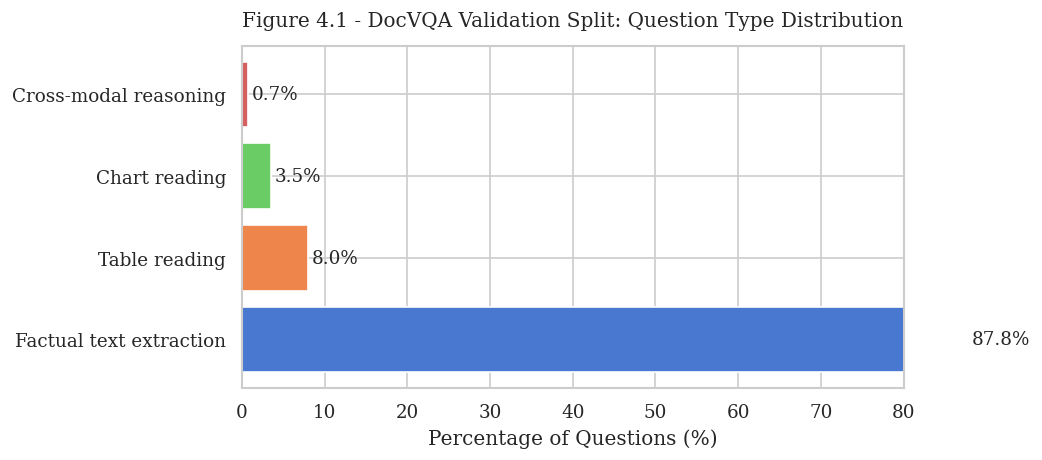

Saved: fig4_1_docvqa_question_types.png


In [ ]:
# Figure 4.1 - DocVQA question type distribution
fig, ax = plt.subplots(figsize=(9, 4))
colors = sns.color_palette("muted", len(df_qtypes))
bars = ax.barh(df_qtypes["Question Type"], df_qtypes["Percentage (%)"],
               color=colors, edgecolor="white")
for bar, pct in zip(bars, df_qtypes["Percentage (%)"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{pct}%", va="center", fontsize=11)
ax.set_xlabel("Percentage of Questions (%)", fontsize=12)
ax.set_title("Figure 4.1 - DocVQA Validation Split: Question Type Distribution", fontsize=12, pad=12)
ax.set_xlim(0, 80)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "figures" / "fig4_1_docvqa_question_types.png", bbox_inches="tight")
plt.show()
print("Saved: fig4_1_docvqa_question_types.png")


In [ ]:
# Key headline figures for Section 4.6.1 of the dissertation
visual_requiring = (cat_counts["Table reading"] + cat_counts["Chart reading"]
                    + cat_counts["Cross-modal reasoning"])
visual_pct    = round(visual_requiring / total_q * 100, 1)
text_only_pct = round(cat_counts["Factual text extraction"] / total_q * 100, 1)

print("Key figures for Section 4.6.1:")
print(f"  Questions requiring visual content : {visual_requiring} ({visual_pct}%)")
print(f"  Text-only questions                : {cat_counts['Factual text extraction']} ({text_only_pct}%)")
print()
print(f"  A text-only pipeline can answer at most {{text_only_pct}}% of questions correctly.")
print(f"  The remaining {{visual_pct}}% require reading a table, chart, or visual element.")
print()
print("  This supports the case for multimodal document analysis.")


Key figures for Section 4.6.1:
  Questions requiring visual content : 652 (12.2%)
  Text-only questions                : 4697 (87.8%)

  A text-only pipeline can answer at most {text_only_pct}% of questions correctly.
  The remaining {visual_pct}% require reading a table, chart, or visual element.

  This supports the case for multimodal document analysis.


---
### Section 2 - Annual Report PDFs Preprocessing

This section constitutes the primary data understanding and data preparation work for the dissertation corpus. For each of the 10 annual report PDFs:

1. **Text extraction** - `pdfplumber` extracts raw text per page, preserving table column alignment where possible
2. **Page image conversion** -`PyMuPDF` renders each page at 150 DPI as a PNG image, used in Section 3 for visual content analysis and in later dissertation chapters
3. **Page classification** - each page is categorised as `text_only`, `mixed` (text + table), or `image_only` based on extracted content

Processing time is approximately 10-15.


In [ ]:
# Check the reports folder for the ten downloaded PDFs
print("Reports folder:", REPORTS_FOLDER.resolve())
print("PDFs found:", len(list(REPORTS_FOLDER.glob("*.pdf"))))
for f in sorted(REPORTS_FOLDER.glob("*.pdf")):
    print(" -", f.name)

Reports folder: /content/drive/MyDrive/dissertation_project/annual_reports
PDFs found: 10
 - astrazeneca2025.pdf
 - barclays2024.pdf
 - bp2024.pdf
 - btgroup2024.pdf
 - hsbc2024.pdf
 - marksandspencer2024.pdf
 - nationalgrid2024.pdf
 - rolls-royce2024.pdf
 - tesco2025.pdf
 - unilever2024.pdf


In [ ]:
# Extract page-level stats (text, tables, images) from every PDF
from tqdm import tqdm
import pandas as pd
import fitz        # PyMuPDF
import pdfplumber

report_stats     = []
all_page_records = []

for fname in tqdm(REPORT_FILES, desc="Processing PDFs"):
    pdf_path = REPORTS_FOLDER / fname
    if not pdf_path.exists():
        print(f"  SKIPPING (not found): {{fname}}")
        continue

    report_name = pdf_path.stem
    fitz_doc    = fitz.open(str(pdf_path))
    total_pages = len(fitz_doc)
    text_only_pages = mixed_pages = image_only_pages = 0

    with pdfplumber.open(str(pdf_path)) as plumber_doc:
        for page_num, page in enumerate(plumber_doc.pages):

            raw_text   = page.extract_text()
            text_clean = raw_text.strip() if raw_text else ""
            has_text   = len(text_clean) > 50

            tables    = page.extract_tables()
            has_table = len(tables) > 0

            # Render page as PNG at 150 DPI (PDF native = 72 DPI)
            mat = fitz.Matrix(150 / 72, 150 / 72)
            pix = fitz_doc[page_num].get_pixmap(matrix=mat)
            img_path = OUTPUT_FOLDER / "page_images" / f"{report_name}_p{page_num+1:04d}.png"
            pix.save(str(img_path))

            txt_path = OUTPUT_FOLDER / "page_text" / f"{report_name}_p{page_num+1:04d}.txt"
            with open(txt_path, "w", encoding="utf-8") as tf:
                tf.write(text_clean)

            if has_text and has_table:
                page_type = "mixed";      mixed_pages += 1
            elif has_text:
                page_type = "text_only";  text_only_pages += 1
            else:
                page_type = "image_only"; image_only_pages += 1

            all_page_records.append({
                "report"     : report_name,
                "page_num"   : page_num + 1,
                "page_type"  : page_type,
                "has_text"   : has_text,
                "has_table"  : has_table,
                "text_length": len(text_clean),
                "num_tables" : len(tables),
            })

    fitz_doc.close()
    report_stats.append({
        "Report"          : report_name,
        "Total Pages"     : total_pages,
        "Text-only Pages" : text_only_pages,
        "Mixed Pages"     : mixed_pages,
        "Image-only Pages": image_only_pages,
        "Image-only %"    : round(image_only_pages / total_pages * 100, 1),
    })

df_pages = pd.DataFrame(all_page_records)
df_pages.to_csv(OUTPUT_FOLDER / "all_pages_data.csv", index=False)
print(f"\nDone. Total pages processed: {{len(df_pages)}}")
print("Saved: all_pages_data.csv")


Processing PDFs: 100%|██████████| 10/10 [22:09<00:00, 132.99s/it]



Done. Total pages processed: {len(df_pages)}
Saved: all_pages_data.csv


In [ ]:
# Confirm page images and text files were saved correctly
png_count = len(list((OUTPUT_FOLDER / "page_images").glob("*.png")))
txt_count = len(list((OUTPUT_FOLDER / "page_text").glob("*.txt")))

print("PNG files:", png_count)
print("TXT files:", txt_count)

import pandas as pd
df_pages = pd.read_csv(OUTPUT_FOLDER / "all_pages_data.csv")
print("\nRows in all_pages_data.csv:", len(df_pages))
print("\nPages per report:")
print(df_pages.groupby("report").size())

PNG files: 3001
TXT files: 3001

Rows in all_pages_data.csv: 3001

Pages per report:
report
astrazeneca2025        232
barclays2024           536
bp2024                 372
btgroup2024            241
hsbc2024               460
marksandspencer2024    111
nationalgrid2024       268
rolls-royce2024        228
tesco2025              248
unilever2024           305
dtype: int64


Sample file: rolls-royce2024_p0010.png


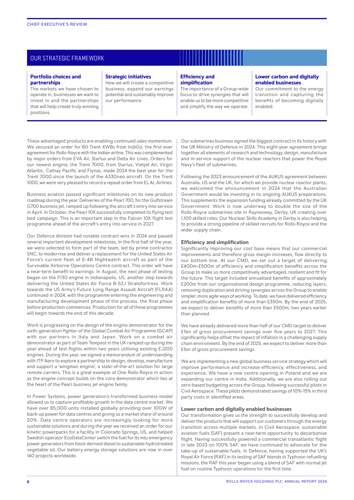

In [ ]:
# Preview one random page image to check extraction quality
from PIL import Image
import random

sample_files = list((OUTPUT_FOLDER / "page_images").glob("*.png"))
sample = random.choice(sample_files)
print("Sample file:", sample.name)
img = Image.open(sample)
img.thumbnail((400, 500))
img

In [ ]:
# Report level summary - Table 4.2 in the dissertation
df_report_stats = pd.DataFrame(report_stats)
df_report_stats.to_csv(OUTPUT_FOLDER / "annual_report_summary_stats.csv", index=False)
print("Saved: annual_report_summary_stats.csv")
print()
print(df_report_stats.to_string(index=False))


Saved: annual_report_summary_stats.csv

             Report  Total Pages  Text-only Pages  Mixed Pages  Image-only Pages  Image-only %
       unilever2024          305              177          123                 5           1.6
          tesco2025          248                2          246                 0           0.0
    rolls-royce2024          228               79          148                 1           0.4
   nationalgrid2024          268              109          158                 1           0.4
marksandspencer2024          111                2          109                 0           0.0
           hsbc2024          460              151          308                 1           0.2
        btgroup2024          241              107          134                 0           0.0
             bp2024          372              156          214                 2           0.5
       barclays2024          536                2          532                 2           0.4
    astraz


### Section 3 - Exploratory Data Analysis (Annual Report Corpus)

This section performs EDA on the page-level data extracted in Section 2. The analysis addresses four questions that directly inform the system design in Chapters 5 and 6:

1. **Page type distribution** - what proportion of the corpus is text-only vs. mixed vs. image-only?
2. **Text extraction quality** - how much of the corpus has usable extracted text (>200 chars)?
3. **Visual content density per report** - which companies have the most visually rich documents?
4. **Table-text co-occurrence** - on pages containing tables, does explanatory text also appear on the same page? A high rate supports using page-level proximity as a cross-modal alignment signal.


In [ ]:
# Load page data from CSV if this section is run independently of Section 2
if "df_pages" not in vars():
    df_pages = pd.read_csv(OUTPUT_FOLDER / "all_pages_data.csv")
    print("Loaded page data from saved CSV.")

total_pages = len(df_pages)
print(f"Total pages : {total_pages}  |  Reports : {df_pages['report'].nunique()}")
print()
print(df_pages["page_type"].value_counts())


Total pages : 3001  |  Reports : 10

page_type
mixed         2051
text_only      938
image_only      12
Name: count, dtype: int64


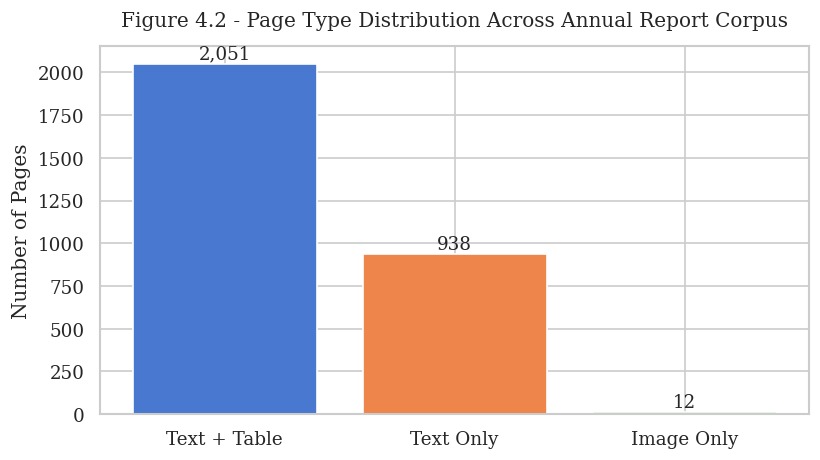

Saved: fig4_2_page_type_distribution.png


In [ ]:
# Figure 4.2 - Page type distribution across the full corpus
page_counts = df_pages["page_type"].value_counts()
label_map   = {"text_only": "Text Only", "mixed": "Text + Table", "image_only": "Image Only"}
labels      = [label_map.get(k, k) for k in page_counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, page_counts.values,
              color=sns.color_palette("muted", len(page_counts)), edgecolor="white")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{bar.get_height():,}", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Number of Pages")
ax.set_title("Figure 4.2 - Page Type Distribution Across Annual Report Corpus", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "figures" / "fig4_2_page_type_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: fig4_2_page_type_distribution.png")


In [ ]:
# Text extraction quality classification:
# Good    = >200 chars  - sufficient for entity extraction and indexing
# Partial = 50–200 chars - marginal; may be caption text adjacent to a visual
# None    = <50 chars   - effectively image-only or blank page

def text_quality(length):
    if length > 200:  return "Good"
    elif length > 50: return "Partial"
    else:             return "None / Image-only"

df_pages["text_quality"] = df_pages["text_length"].apply(text_quality)
quality_pct = (df_pages["text_quality"].value_counts() / total_pages * 100).round(1)
quality_pct.to_csv(OUTPUT_FOLDER / "text_extraction_quality.csv")

print("Text extraction quality:")
for level, pct in quality_pct.items():
    print(f"{level:<22}  {pct}%")
print("\nSaved: text_extraction_quality.csv")


Text extraction quality:
Good                    99.0%
Partial                 0.6%
None / Image-only       0.4%

Saved: text_extraction_quality.csv


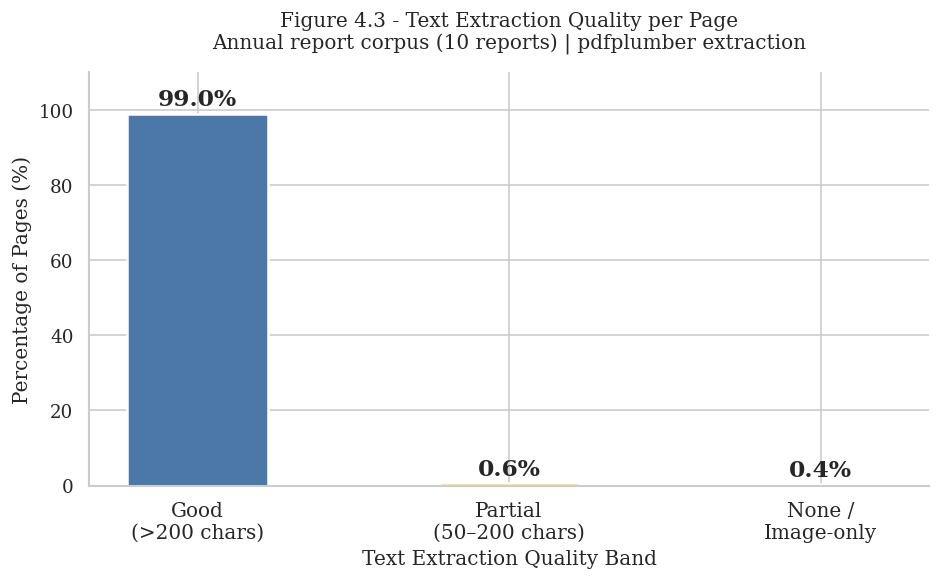

Saved: fig4_3_text_extraction_quality.png


In [ ]:
# Figure 4.3 - Text extraction quality (bar chart)

fig, ax = plt.subplots(figsize=(8, 5))

quality_order = ["Good", "Partial", "None / Image-only"]
labels_plot   = ["Good\n(>200 chars)", "Partial\n(50–200 chars)", "None /\nImage-only"]
values_plot   = [quality_pct.get(q, 0) for q in quality_order]
colors_plot   = ["#4C78A8", "#F58518", "#E45756"]

bars = ax.bar(labels_plot, values_plot, color=colors_plot,
              edgecolor="white", linewidth=1.5, width=0.45)

for bar, pct in zip(bars, values_plot):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{pct}%",
            ha="center", va="bottom", fontsize=14, fontweight="bold")

ax.set_ylabel("Percentage of Pages (%)", fontsize=12)
ax.set_xlabel("Text Extraction Quality Band", fontsize=12)
ax.set_title(
    "Figure 4.3 - Text Extraction Quality per Page\n"
    "Annual report corpus (10 reports) | pdfplumber extraction",
    fontsize=12, pad=14
)
ax.set_ylim(0, 110)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "figures" / "fig4_3_text_extraction_quality.png", bbox_inches="tight")
plt.show()
print("Saved: fig4_3_text_extraction_quality.png")

In [ ]:
# Visual content density per report:
# Defined as the percentage of pages that are NOT pure text-only.
# A higher density means the report relies more on tables and visual elements
# to communicate financial data - directly relevant to Chapter 5 design.

visual_density = (
    df_pages.groupby("report")
    .apply(lambda g: round((g["page_type"] != "text_only").sum() / len(g) * 100, 1))
    .reset_index()
)
visual_density.columns = ["Report", "Visual Density (%)"]
visual_density = visual_density.sort_values("Visual Density (%)", ascending=False)
visual_density.to_csv(OUTPUT_FOLDER / "visual_density_per_report.csv", index=False)

print("Visual content density per report:")
print(visual_density.to_string(index=False))
print(f"Average across all reports: {visual_density['Visual Density (%)'].mean():.1f}%")


Visual content density per report:
             Report  Visual Density (%)
       barclays2024                99.6
          tesco2025                99.2
marksandspencer2024                98.2
           hsbc2024                67.2
    rolls-royce2024                65.4
   nationalgrid2024                59.3
             bp2024                58.1
        btgroup2024                55.6
       unilever2024                42.0
    astrazeneca2025                34.1
Average across all reports: 67.9%


/tmp/ipykernel_2290/2791636310.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: round((g["page_type"] != "text_only").sum() / len(g) * 100, 1))


/tmp/ipykernel_2290/3606088995.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(visual_density["Report"], rotation=30, ha="right", fontsize=9)


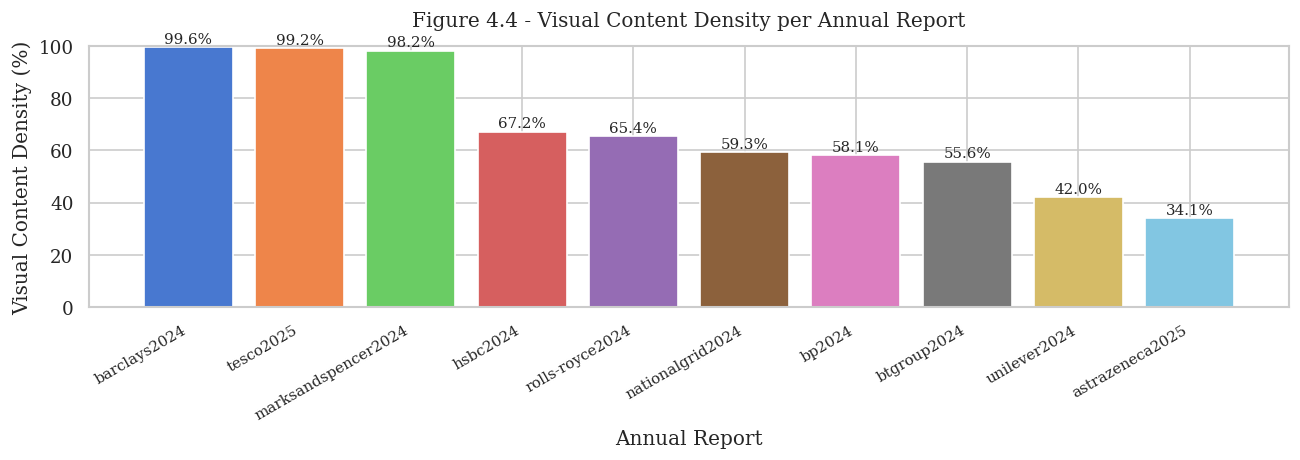

Saved: fig4_4_visual_density_per_report.png


In [ ]:
# Figure 4.4 - Visual content density per report
fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(visual_density["Report"], visual_density["Visual Density (%)"],
              color=sns.color_palette("muted", len(visual_density)), edgecolor="white")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Visual Content Density (%)")
ax.set_xlabel("Annual Report")
ax.set_title("Figure 4.4 - Visual Content Density per Annual Report", fontsize=12, pad=12)
ax.set_xticklabels(visual_density["Report"], rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "figures" / "fig4_4_visual_density_per_report.png", bbox_inches="tight")
plt.show()
print("Saved: fig4_4_visual_density_per_report.png")


In [ ]:
# Table-text co-occurrence analysis.
# On pages classified as 'mixed', we check what proportion also contain
# substantial explanatory text (>200 chars). A high rate validates the assumption
# that tables and their narrative context appear on the same page a property
# exploited by the page-level graph alignment strategy in Chapter 6.

mixed_df     = df_pages[df_pages["page_type"] == "mixed"]
total_mixed  = len(mixed_df)
co_occur_pos = (mixed_df["text_length"] > 200).sum()
co_occur_pct = round(co_occur_pos / total_mixed * 100, 1) if total_mixed > 0 else 0

print(f"Mixed pages (table + text present)              : {total_mixed}")
print(f"Of those, pages with good explanatory text      : {co_occur_pos} ({co_occur_pct}%)")
print(f"\nIn {co_occur_pct}% of pages containing a table, substantial explanatory text")
print(f"also appears on the same page.")


Mixed pages (table + text present)              : 2051
Of those, pages with good explanatory text      : 2049 (99.9%)

In 99.9% of pages containing a table, substantial explanatory text
also appears on the same page.



### Section 4 - Feature Engineering

Two engineered features are produced here and used downstream in later dissertation chapters.

**Feature 1 - Entity name normalisation**
Financial entity names extracted from text (via pdfplumber) and from visual content use inconsistent naming conventions. For example, "Operating Profit (GBP millions)" and "operating profit" refer to the same entity. A normalisation function strips bracketed units, removes currency/scale keywords, strips extra whitespace, and converts to Title Case to produce a canonical form.

**Feature 2 - Page-level co-occurrence score**
For every mixed page, a co-occurrence score is computed as the product of the number of tables on that page and the text volume (in kilocharacters). This score is used as an edge weight in the cross-modal knowledge graph: a higher score means a stronger inferred relationship between the text entities and the table entities that appear together on the same page.


In [ ]:
# Feature 1 - Entity name normalisation
# what GPT-4o Vision and pdfplumber would extract from the annual reports.

raw_entity_names = [
    "Operating Profit (GBP millions)", "operating profit",
    "Revenue (USD bn)",                "Revenue",
    "Total Assets (آ£m)",               "total assets",
    "Earnings Per Share (pence)",      "EPS",
    "Capital Expenditure (GBP millions)", "Capex",
    "Return on Equity (%)",            "ROE",
    "Net Zero Emissions Target",       "net zero",
]


def normalise_entity(name):
    name = re.sub(r"\(.*?\)", "", name)       # remove bracketed content e.g. (GBP millions)
    name = re.sub(
        r"\b(GBP|USD|EUR|pence|bn|m|million|billion|thousands|percent)\b",
        "", name, flags=re.IGNORECASE
    )
    name = " ".join(name.split())             # collapse whitespace

    if name.isupper() and len(name) <= 5:     # preserve acronyms e.g. EPS, ROE
        return name

    return name.title()


normalised = [normalise_entity(n) for n in raw_entity_names]
df_norm    = pd.DataFrame({"Raw Entity Name": raw_entity_names, "Normalised Name": normalised})
df_norm.to_csv(OUTPUT_FOLDER / "entity_name_normalisation_examples.csv", index=False)


print("Entity name normalisation examples:")
print()
print(df_norm.to_string(index=False))
print("\nSaved: entity_name_normalisation_examples.csv")


Entity name normalisation examples:

                   Raw Entity Name           Normalised Name
   Operating Profit (GBP millions)          Operating Profit
                  operating profit          Operating Profit
                  Revenue (USD bn)                   Revenue
                           Revenue                   Revenue
                Total Assets (آ£m)              Total Assets
                      total assets              Total Assets
        Earnings Per Share (pence)        Earnings Per Share
                               EPS                       EPS
Capital Expenditure (GBP millions)       Capital Expenditure
                             Capex                     Capex
              Return on Equity (%)          Return On Equity
                               ROE                       ROE
         Net Zero Emissions Target Net Zero Emissions Target
                          net zero                  Net Zero

Saved: entity_name_normalisation_examples.csv


In [ ]:
# Feature 2 - Page-level co-occurrence score
# This is saved as a CSV and used as an optional feature for later analysis.

co_feat = df_pages[df_pages["page_type"] == "mixed"][
    ["report", "page_num", "num_tables", "text_length"]
].copy()
co_feat["co_occurrence_score"] = (co_feat["text_length"] / co_feat["num_tables"] / 100).round(3)
co_feat.to_csv(OUTPUT_FOLDER / "page_cooccurrence_feature.csv", index=False)

print(f"Co-occurrence feature computed for {len(co_feat)} mixed pages.")
print()
print(co_feat.head(10).to_string(index=False))
print("\nSaved: page_cooccurrence_feature.csv")


Co-occurrence feature computed for 2051 mixed pages.

      report  page_num  num_tables  text_length  co_occurrence_score
unilever2024         5           5         1226                2.452
unilever2024         6           1         1727               17.270
unilever2024        16          16         4720                2.950
unilever2024        43           3         5318               17.727
unilever2024        44           2         6439               32.195
unilever2024        45           1         4437               44.370
unilever2024        46           1         4656               46.560
unilever2024        47           3         4044               13.480
unilever2024        48           3         3529               11.763
unilever2024        49           3         3916               13.053

Saved: page_cooccurrence_feature.csv


### Section 5 - Final Summary - Chapter 4 Key Figures


In [ ]:
# Print the final Chapter 4 headline figures for the writeup
print("=" * 65)
print("  CHAPTER 4 KEY FIGURES")
print("=" * 65)
print()
print("DocVQA Benchmark (Section 4.6.1 / Table 4.1):")
print(f"  Total Q&A pairs              : {total_q}")
print(f"  Unique document images       : {len(unique_images)}")
for _, row in df_qtypes.iterrows():
    print(f"  {row['Question Type']:<30}  {row['Percentage (%)']}%")
print(f"  Questions needing visual     : {visual_pct}%")
print(f"  Text-only questions          : {text_only_pct}%")
print()
good_pct = round((df_pages["text_quality"] == "Good").sum() / len(df_pages) * 100, 1)
img_pct  = round((df_pages["page_type"] == "image_only").sum() / len(df_pages) * 100, 1)
avg_vd   = round(visual_density["Visual Density (%)"].mean(), 1)
print("Annual Report Corpus (Section 4.6.2-4.6.3 / Table 4.2):")
print(f"  Total pages processed        : {len(df_pages)}")
print(f"  Good text extraction (>200c) : {good_pct}%")
print(f"  Image-only pages             : {img_pct}%")
print(f"  Avg visual density           : {avg_vd}%")
print(f"  Table-text co-occurrence     : {co_occur_pct}%")
print()
print(f"Outputs saved to : outputs/")
print(f"Figures saved to : outputs/figures/")


  CHAPTER 4 KEY FIGURES

DocVQA Benchmark (Section 4.6.1 / Table 4.1):
  Total Q&A pairs              : 5349
  Unique document images       : 1286
  Factual text extraction         87.8%
  Table reading                   8.0%
  Chart reading                   3.5%
  Cross-modal reasoning           0.7%
  Questions needing visual     : 12.2%
  Text-only questions          : 87.8%

Annual Report Corpus (Section 4.6.2-4.6.3 / Table 4.2):
  Total pages processed        : 3001
  Good text extraction (>200c) : 99.0%
  Image-only pages             : 0.4%
  Avg visual density           : 67.9%
  Table-text co-occurrence     : 99.9%

Outputs saved to : outputs/
Figures saved to : outputs/figures/



## Chapter 5 – Baseline RAG construction and RAGAS evaluation

This cahpter builds and evaluates three baseline retrieval systems, each isolating a different capability so that performance differences seen later can be attributed to specific parts of the system.

The chapter is structured as follows:

Section 1 – Library installation and environment setup

Section 2 – Baseline 1: standard RAG on text chunks

Section 3 – Baseline 2: text GraphRAG using a Neo4j property graph

Section 4 – Baseline 3: multimodal RAG using GPT-4o page descriptions, no graph

Section 5 – Query set and RAGAS evaluation

Section 6 – Result figures


### Section 1 – Library Installation - Imports and Secret Handling


In [2]:
# Install libraries needed for the Chapter 5 baselines
import subprocess
subprocess.run([
    'pip', 'install', '-q',
    'llama-index',
    'llama-index-embeddings-openai',
    'llama-index-llms-openai',
    'llama-index-graph-stores-neo4j',
    'llama-index-vector-stores-faiss',
    'faiss-cpu',
    'neo4j',
    'ragas',
    'openai',
    'llama-cloud',
    'nest_asyncio',
], check=False)
print('Chapter 5 libraries installed successfully.')


Chapter 5 libraries installed successfully.


In [5]:
# Core imports and secret/API key handling for Chapter 5
import os
import json
import base64
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from llama_index.core import Document, Settings, StorageContext, VectorStoreIndex
from llama_index.core.node_parser import SentenceSplitter
from llama_index.embeddings.openai import OpenAIEmbedding
from llama_index.llms.openai import OpenAI
import nest_asyncio
nest_asyncio.apply()

OPENAI_AVAILABLE = False
NEO4J_AVAILABLE = False
LLAMA_CLOUD_AVAILABLE = False


def get_secret(name, fallback=''):
    try:
        from google.colab import userdata
        val = userdata.get(name)
        return val if val else fallback
    except Exception:
        return os.environ.get(name, fallback)


OPENAI_API_KEY = get_secret('OPENAI_API_KEY', get_secret('OPENAIAPIKEY', ''))
NEO4J_URI = get_secret('NEO4J_URI', get_secret('NEO4JURI', ''))
NEO4J_USERNAME = get_secret('NEO4J_USERNAME', get_secret('NEO4JUSERNAME', 'neo4j'))
NEO4J_PASSWORD = get_secret('NEO4J_PASSWORD', get_secret('NEO4JPASSWORD', ''))
LLAMA_CLOUD_API_KEY = get_secret('LLAMA_CLOUD_API_KEY', get_secret('LLAMACLOUDAPIKEY', ''))

if OPENAI_API_KEY:
    os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY
if NEO4J_URI:
    os.environ['NEO4J_URI'] = NEO4J_URI
if NEO4J_USERNAME:
    os.environ['NEO4J_USERNAME'] = NEO4J_USERNAME
if NEO4J_PASSWORD:
    os.environ['NEO4J_PASSWORD'] = NEO4J_PASSWORD
if LLAMA_CLOUD_API_KEY:
    os.environ['LLAMA_CLOUD_API_KEY'] = LLAMA_CLOUD_API_KEY

OPENAI_AVAILABLE = bool(OPENAI_API_KEY)
LLAMA_CLOUD_AVAILABLE = bool(LLAMA_CLOUD_API_KEY)

# --- Drive-persisted paths ---
PROJECT_ROOT = Path('/content/drive/MyDrive/dissertation_project')
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

REPORTSFOLDER = PROJECT_ROOT / 'annual_reports'
OUTPUTFOLDER = PROJECT_ROOT / 'outputs'
REPORTSFOLDER.mkdir(parents=True, exist_ok=True)
OUTPUTFOLDER.mkdir(parents=True, exist_ok=True)

CH5 = OUTPUTFOLDER / "chapter5"
CH5.mkdir(parents=True, exist_ok=True)
(CH5 / 'visualdescriptions').mkdir(parents=True, exist_ok=True)
(CH5 / 'figures').mkdir(parents=True, exist_ok=True)
(CH5 / 'b1_index').mkdir(parents=True, exist_ok=True)
(CH5 / 'b2_graph').mkdir(parents=True, exist_ok=True)
(CH5 / 'b3_index').mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 150

# same embed model and LLM across all three baselines, keeps the comparison fair
Settings.embed_model = OpenAIEmbedding(model='text-embedding-3-small', api_key=OPENAI_API_KEY)
Settings.llm = OpenAI(model='gpt-4o-mini', temperature=0.0, api_key=OPENAI_API_KEY)

print('Imports complete.')
print('Reports folder:', REPORTSFOLDER.resolve())
print('Chapter 5 output:', CH5.resolve())
print('OpenAI available:', OPENAI_AVAILABLE)
print('Neo4j configured:', bool(NEO4J_URI and NEO4J_USERNAME and NEO4J_PASSWORD))
print('LlamaCloud available:', LLAMA_CLOUD_AVAILABLE)

Imports complete.
Reports folder: /content/drive/MyDrive/dissertation_project/annual_reports
Chapter 5 output: /content/drive/MyDrive/dissertation_project/outputs/chapter5
OpenAI available: True
Neo4j configured: True
LlamaCloud available: True


In [ ]:
# Reload the page-level dataset from Chapter 4
import pandas as pd
from pathlib import Path

OUTPUT_FOLDER = Path('/content/drive/MyDrive/dissertation_project/outputs')

df_pages = pd.read_csv(OUTPUT_FOLDER / "all_pages_data.csv")
print("Reloaded df_pages:", len(df_pages), "rows")
print(df_pages.columns.tolist())

Reloaded df_pages: 3001 rows
['report', 'page_num', 'page_type', 'has_text', 'has_table', 'text_length', 'num_tables']


### Section 2 – Baseline 1 - Standard RAG

 - Text-only chunk-based retrieval using vector similarity with OpenAI embeddings.  
 - The floor performance of a standard RAG pipeline with no graph, no visual content, and no page-level multimodal structure.


In [ ]:
# Extract or load cached page text for Baseline 1
import pdfplumber

if 'dfpages' not in globals():
    dfpages = pd.read_csv(OUTPUTFOLDER / 'all_pages_data.csv')
    print('Loaded page metadata from outputs/all_pages_data.csv')

TEXTCACHE = CH5 / 'pagetextcache.csv'
dftext = None
if TEXTCACHE.exists():
    try:
        dftext = pd.read_csv(TEXTCACHE)
        if dftext.empty or 'text' not in dftext.columns:
            dftext = None
    except pd.errors.EmptyDataError:
        dftext = None

if dftext is not None:
    print(f'Loaded text cache: {len(dftext):,} pages')
else:
    pdf_files = sorted(REPORTSFOLDER.glob('*.pdf'))
    if not pdf_files:
        raise FileNotFoundError(f'No PDFs found in {REPORTSFOLDER.resolve()}. Check the folder name.')

    records = []
    print('Extracting text from PDFs...')
    for pdffile in tqdm(pdf_files, desc='Extracting PDFs'):
        reportname = pdffile.stem
        try:
            with pdfplumber.open(pdffile) as pdf:
                for i, page in enumerate(pdf.pages, start=1):
                    text = page.extract_text() or ''
                    records.append({'report': reportname, 'page_num': i, 'text': text.strip()})
        except Exception as e:
            print('Error on', pdffile.name, e)
    dftext = pd.DataFrame(records)
    dftext.to_csv(TEXTCACHE, index=False)
    print(f'Extracted and cached text for {len(dftext):,} pages.')

# older cache files may still use "pagenum" - normalise just in case
if 'pagenum' in dftext.columns and 'page_num' not in dftext.columns:
    dftext = dftext.rename(columns={'pagenum': 'page_num'})

base_dfpages = dfpages.copy()
if 'text' in base_dfpages.columns:
    base_dfpages = base_dfpages.drop(columns=['text'])
dfpages = base_dfpages.merge(dftext, on=['report', 'page_num'], how='left')
dfpages['text'] = dfpages['text'].fillna('')

print('Total pages in dfpages:', len(dfpages))
print('Pages with non-empty text:', (dfpages['text'].str.strip().str.len() > 0).sum())
print('Pages with >= 50 chars text:', (dfpages['text'].str.strip().str.len() >= 50).sum())
print('Page types:', dfpages['page_type'].value_counts().to_dict())

Loaded page metadata from outputs/all_pages_data.csv
Extracting text from PDFs...


Extracting PDFs: 100%|██████████| 10/10 [15:16<00:00, 91.61s/it]


Extracted and cached text for 3,001 pages.
Total pages in dfpages: 3001
Pages with non-empty text: 2996
Pages with >= 50 chars text: 2989
Page types: {'mixed': 2051, 'text_only': 938, 'image_only': 12}


In [ ]:
# Build LlamaIndex Document objects for Baseline 1 (text-only pages)
textdocs = []
for row in dfpages.itertuples(index=False):
    text = str(getattr(row, 'text', '') or '').strip()
    if getattr(row, 'pagetype', '') == 'imageonly':
        continue
    if len(text) < 10:
        continue
    textdocs.append(
        Document(
            text=text,
            metadata={
                'report': row.report,
                'pagenum': int(row.page_num),
                'pagetype': row.page_type,
            },
        )
    )

print(f'Documents built for Baseline 1: {len(textdocs):,}')
if textdocs:
    print('Sample text:', textdocs[0].text[:200])


Documents built for Baseline 1: 2,996
Sample text: Disclaimer
This is a PDF version of the Unilever Annual Report and Accounts 2024 and is an exact
copy of the printed document provided to Unilever’s shareholders.
The Annual Report and Accounts 2024 w


In [ ]:
# restore embeddings
from llama_index.core import StorageContext, load_index_from_storage

b1indexpath = CH5 / "b1_index"

if b1indexpath.exists() and any(b1indexpath.iterdir()):
    storagecontext = StorageContext.from_defaults(persist_dir=str(b1indexpath))
    b1index = load_index_from_storage(storagecontext, embed_model=Settings.embed_model)
    print("Loaded Baseline 1 index from Drive cache — no re-embedding needed.")
else:
    b1index = VectorStoreIndex(nodes, show_progress=True)
    b1index.storage_context.persist(persist_dir=str(b1indexpath))
    print("Baseline 1 vector index built with OpenAI embeddings and persisted to Drive.")

In [ ]:
# Chunk the documents and build the Baseline 1 vector index
splitter = SentenceSplitter(chunk_size=512, chunk_overlap=64)
nodes = splitter.get_nodes_from_documents(textdocs, show_progress=True)
print(f'Total text chunks produced: {len(nodes):,}')
if nodes:
    word_counts = [len(n.text.split()) for n in nodes]
    print('Average words per chunk:', int(np.mean(word_counts)))
    print('Min / Max words per chunk:', min(word_counts), '/', max(word_counts))

b1index = VectorStoreIndex(nodes, show_progress=True)
print('Baseline 1 vector index built with OpenAI embeddings.')


Parsing nodes:   0%|          | 0/2996 [00:00<?, ?it/s]

Total text chunks produced: 8,380
Average words per chunk: 263
Min / Max words per chunk: 6 / 465


Generating embeddings:   0%|          | 0/2048 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2048 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2048 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2048 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/188 [00:00<?, ?it/s]

Baseline 1 vector index built with OpenAI embeddings.


In [ ]:
# Create the Baseline 1 query engine
b1queryengine = b1index.as_query_engine(similarity_top_k=5, response_mode='compact')
print('Baseline 1 query engine ready.')


Baseline 1 query engine ready.


In [ ]:
# Smoke test Baseline 1 with a sample question
testq = 'What was HSBC reported net interest income for 2024?'
testr = b1queryengine.query(testq)
print('Baseline 1 smoke test')
print('Q:', testq)
print('A:', str(testr)[:1000])


Baseline 1 smoke test
Q: What was HSBC reported net interest income for 2024?
A: HSBC reported net interest income of $32,733 million for the year ended 31 December 2024.


In [ ]:
# Persist the Baseline 1 index to disk
b1index.storage_context.persist(persist_dir=str(CH5 / "b1_index"))
print("Baseline 1 index persisted to Drive:", CH5 / "b1_index")

Baseline 1 index persisted to Drive: /content/drive/MyDrive/dissertation_project/outputs/chapter5/b1_index


In [ ]:
# Confirm the persisted index files exist
print(list((CH5 / "b1_index").iterdir()))

[PosixPath('/content/drive/MyDrive/dissertation_project/outputs/chapter5/b1_index/docstore.json'), PosixPath('/content/drive/MyDrive/dissertation_project/outputs/chapter5/b1_index/index_store.json'), PosixPath('/content/drive/MyDrive/dissertation_project/outputs/chapter5/b1_index/graph_store.json'), PosixPath('/content/drive/MyDrive/dissertation_project/outputs/chapter5/b1_index/default__vector_store.json'), PosixPath('/content/drive/MyDrive/dissertation_project/outputs/chapter5/b1_index/image__vector_store.json')]


### Section 3 – Baseline 2 - Text GraphRAG

 - A property graph built from the same text chunks as Baseline 1, stored in Neo4j and extracted with GPT-4o-mini.  
 - The contribution of graph-based relationship reasoning over text, independent of visual content.


In [ ]:
# Connect to Neo4j for the Baseline 2 property graph
from neo4j import GraphDatabase

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
with driver.session() as session:
    result = session.run("RETURN 'Neo4j connection OK' AS message")
    print(result.single()["message"])
driver.close()

Neo4j connection OK


In [ ]:
# Set up the Neo4j-backed graph store for Baseline 2
from llama_index.graph_stores.neo4j import Neo4jPropertyGraphStore
from llama_index.core import StorageContext

if NEO4J_URI and NEO4J_USERNAME and NEO4J_PASSWORD:
    try:
        graph_store_v2 = Neo4jPropertyGraphStore(
            username=NEO4J_USERNAME,
            password=NEO4J_PASSWORD,
            url=NEO4J_URI,
            database='neo4j',
        )
        storage_context_v2 = StorageContext.from_defaults(property_graph_store=graph_store_v2)
        NEO4J_AVAILABLE = True
        print('Neo4j v2 connected successfully.')
    except Exception as e:
        graph_store_v2 = None
        storage_context_v2 = None
        NEO4J_AVAILABLE = False
        print('Neo4j v2 not available:', e)
else:
    graph_store_v2 = None
    storage_context_v2 = None
    NEO4J_AVAILABLE = False
    print('Neo4j credentials not configured.')


Neo4j v2 connected successfully.


In [ ]:
# Imports for LLM-based extraction and API calls
import openai, requests

resp = requests.post(
    'https://api.openai.com/v1/chat/completions',
    headers={'Authorization': f'Bearer {OPENAI_API_KEY}'},
    json={'model': 'gpt-4o-mini', 'messages': [{'role': 'user', 'content': 'hi'}], 'max_tokens': 1},
)
print(resp.headers.get('x-ratelimit-remaining-requests'))
print(resp.headers.get('x-ratelimit-reset-requests'))

712
22h17m27.948s


In [ ]:
# Reference evidence used to validate Baseline 2 extraction
v1_evidence = {
    'query': 'What was HSBC reported net interest income for 2024?',
    'response': 'Empty Response',
    'retrieval_test': {
        'net interest income': 0,
        'Interest income': 2,
        'Net interest expense': 9,
        'Net interest payments': 5,
    },
    'issue': 'Entity fragmentation: no single canonical node for "net interest income"; synonyms scattered across separate unlinked nodes.',
}

with open(CH5 / 'b2_v1_limitation_evidence.json', 'w') as f:
    json.dump(v1_evidence, f, indent=2)

print('Saved v1 limitation evidence.')

Saved v1 limitation evidence.


In [ ]:
# JSON handling for Baseline 2 outputs
import json

fragmented_entities_manual = {
    'net interest income': 0,
    'Interest income': 2,
    'Net interest expense': 9,
    'Net interest payments': 5,
    'note': 'Counts recorded from earlier successful query before instance upgrade; raw node/label dump skipped due to Aura connection reset after instance upgrade.'
}

with open(CH5 / 'b2_v1_fragmented_entities.json', 'w') as f:
    json.dump(fragmented_entities_manual, f, indent=2)

print('Saved fallback record.')

Saved fallback record.


In [ ]:
# Path/env handling for Baseline 2
import os
for fname in ['b2kgstats.json', 'b2_v1_limitation_evidence.json', 'b2_v1_fragmented_entities.json']:
    path = CH5 / fname
    print(fname, '->', 'EXISTS' if path.exists() else 'MISSING')

b2kgstats.json -> MISSING
b2_v1_limitation_evidence.json -> EXISTS
b2_v1_fragmented_entities.json -> EXISTS


In [ ]:
# Baseline 2 v2 — Schema-Constrained Rebuild.
from typing import Literal

entities = Literal[
    "Company", "FinancialMetric", "FiscalPeriod", "Amount", "Currency"
]

relations = Literal[
    "REPORTED_METRIC", "FOR_PERIOD", "HAS_VALUE", "IN_CURRENCY", "COMPARED_TO"
]

validation_schema = {
    "Company": ["REPORTED_METRIC"],
    "FinancialMetric": ["FOR_PERIOD", "HAS_VALUE", "COMPARED_TO"],
    "Amount": ["IN_CURRENCY"],
}

In [ ]:
# Load the OpenAI LLM used for schema-constrained extraction
from llama_index.llms.openai import OpenAI
from neo4j import GraphDatabase
import os

llm = OpenAI(model="gpt-4o-mini", api_key=os.environ["OPENAI_API_KEY"])
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))

print(llm.model)
print(driver)

gpt-4o-mini


In [ ]:
# Import the schema-constrained path extractor for Baseline 2
from llama_index.core.indices.property_graph import SchemaLLMPathExtractor

kg_extractor = SchemaLLMPathExtractor(
    llm=llm,
    possible_entities=entities,
    possible_relations=relations,
    kg_validation_schema=validation_schema,
    strict=True,
    num_workers=4,
)
print('Schema-constrained extractor ready.')

Schema-constrained extractor ready.


In [ ]:
# Reload checkpoint path for the Baseline 2 KG extraction
checkpoint_path = CH5 / "kg_extraction_checkpoint.pkl"
print("Checkpoint path:", checkpoint_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint path: /content/drive/MyDrive/dissertation_project/outputs/chapter5/kg_extraction_checkpoint.pkl


In [ ]:
# Rebuild the KG extractor with strict mode turned off
from llama_index.core.indices.property_graph import SchemaLLMPathExtractor

kg_extractor = SchemaLLMPathExtractor(
    llm=llm,
    possible_entities=entities,
    possible_relations=relations,
    kg_validation_schema=validation_schema,
    strict=False,
    num_workers=4,
)
print("Extractor rebuilt with strict=False.")

Extractor rebuilt with strict=False.


In [ ]:
# Insert all remaining nodes into the Baseline 2 graph in batches
from llama_index.core import PropertyGraphIndex

BATCH_SIZE = 300

for start in range(300, len(nodes), BATCH_SIZE):
    batch = nodes[start:start + BATCH_SIZE]
    print(f"Batch {start}-{start+len(batch)} of {len(nodes)}")
    b2kgindexv2.insert_nodes(batch)
    print(f"Inserted through chunk {start+len(batch)}")

    if (start + BATCH_SIZE) % 1500 == 0:
        with driver.session(database="neo4j") as session:
            c = session.run("MATCH ()-[r]->() RETURN count(r) AS c").single()["c"]
            print(f"  → Relationship count so far: {c}")

print("Baseline 2 v2 PropertyGraphIndex build complete (strict=False).")

Batch 300-600 of 8380


/usr/local/lib/python3.12/dist-packages/httpx/_urlparse.py:213: RuntimeWarning: coroutine 'SchemaLLMPathExtractor._aextract' was never awaited
  def urlparse(url: str = "", **kwargs: str | None) -> ParseResult:


Inserted through chunk 600
Batch 600-900 of 8380
Inserted through chunk 900
Batch 900-1200 of 8380
Inserted through chunk 1200
Batch 1200-1500 of 8380
Inserted through chunk 1500
  → Relationship count so far: 23599
Batch 1500-1800 of 8380
Inserted through chunk 1800
Batch 1800-2100 of 8380
Inserted through chunk 2100
Batch 2100-2400 of 8380
Inserted through chunk 2400
Batch 2400-2700 of 8380
Inserted through chunk 2700
Batch 2700-3000 of 8380
Inserted through chunk 3000
  → Relationship count so far: 45772
Batch 3000-3300 of 8380
Inserted through chunk 3300
Batch 3300-3600 of 8380
Inserted through chunk 3600
Batch 3600-3900 of 8380
Inserted through chunk 3900
Batch 3900-4200 of 8380
Inserted through chunk 4200
Batch 4200-4500 of 8380
Inserted through chunk 4500
  → Relationship count so far: 66918
Batch 4500-4800 of 8380
Inserted through chunk 4800
Batch 4800-5100 of 8380
Inserted through chunk 5100
Batch 5100-5400 of 8380
Inserted through chunk 5400
Batch 5400-5700 of 8380
Inserted t

In [ ]:
# Check the final node and relationship counts in Neo4j
with driver.session(database="neo4j") as session:
    node_count = session.run("MATCH (n) RETURN count(n) AS c").single()["c"]
    rel_count = session.run("MATCH ()-[r]->() RETURN count(r) AS c").single()["c"]
    print("Node count:", node_count)
    print("Relationship count:", rel_count)

/tmp/ipykernel_1365/366104856.py:1: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session(database="neo4j") as session:


Node count: 56187
Relationship count: 120056


In [ ]:
# Reload the Baseline 2 property graph index from Neo4j
from llama_index.core import PropertyGraphIndex

b2kgindexv2 = PropertyGraphIndex.from_existing(
    property_graph_store=graph_store_v2,
    embed_kg_nodes=False,
)
print("Reloaded b2kgindexv2 from existing Neo4j graph store.")

Reloaded b2kgindexv2 from existing Neo4j graph store.


In [ ]:
# Build the final Baseline 2 query engine
b2_query_engine_v2 = b2kgindexv2.as_query_engine(include_text=True, response_mode="tree_summarize")
print("Baseline 2 v2 query engine ready.")

Baseline 2 v2 query engine ready.


In [ ]:
# Reload the OpenAI LLM for the synonym retriever test
from llama_index.llms.openai import OpenAI

llm = OpenAI(model="gpt-4o-mini", api_key=OPENAI_API_KEY)
print("llm ready:", llm.model)

llm ready: gpt-4o-mini


In [ ]:
# Final smoke test across three sample questions for Baseline 2
test_questions = [
    "What was HSBC reported net interest income for 2024?",
    "What was Unilever's turnover for 2024?",
    "What was Rolls-Royce's underlying operating profit for 2024?",
]

for q in test_questions:
    r = b2_query_engine_v2.query(q)
    print("Q:", q)
    print("A:", str(r)[:500])
    print("---")

Q: What was HSBC reported net interest income for 2024?
A: The information provided does not include any details about HSBC's reported net interest income for 2024.
---
Q: What was Unilever's turnover for 2024?
A: Unilever's turnover for 2024 was €60.8 billion.
---
Q: What was Rolls-Royce's underlying operating profit for 2024?
A: Rolls-Royce's underlying operating profit for 2024 was £2,464 million.
---


In [ ]:
# Diagnosis
sample = allresults['baseline2'][:5]
for r in sample:
    print("Q:", r['question'][:80])
    print("Contexts retrieved:", len(r['contexts']))
    for c in r['contexts'][:2]:
        print("  -", c[:150])
    print("Answer:", r['answer'][:150])
    print("---")

Q: What is the name of the partnership project Dove is involved in to protect and r
Contexts retrieved: 4
  - Here are some facts extracted from the provided text:

Dove -> REPORTED_METRIC -> product launch
Dove -> REPORTED_METRIC -> first body serums launched
  - Here are some facts extracted from the provided text:

Rolls-Royce -> REPORTED_METRIC -> Sustainability

FINANCIAL REVIEW
Statutory and underlying Gro
Answer: The information provided does not mention any partnership project involving Dove to protect and restore rainforests in South East Asia.
---
Q: Who is the chair of the audit committee?
Contexts retrieved: 19
  - Here are some facts extracted from the provided text:

Novo Nordisk AS -> REPORTED_METRIC -> Chair

Board of directors
As at 6 March 2025
Helge Lund M
  - Here are some facts extracted from the provided text:

Women’s Business Council -> REPORTED_METRIC -> Chair

Executive having led major Target Austral
Answer: The chair of the audit committee is Brendan Nelson.

### Section 4 – Baseline 3 - Multimodal RAG without Graph

 - Page-level multimodal retrieval that combines page text with GPT-4o visual descriptions, without any graph layer.  
 - The contribution of multimodal page content and page-level structure, independent of graph reasoning.


In [ ]:
# Path setup for Baseline 3 (multimodal RAG)
from pathlib import Path
CH5 = OUTPUT_FOLDER / "chapter5"
queryset_path = CH5 / "queryset120.csv"
print(queryset_path.exists())
if queryset_path.exists():
    import pandas as pd
    dfq = pd.read_csv(queryset_path)
    print(len(dfq), dfq.columns.tolist())

False


In [ ]:
# Path setup continued for Baseline 3
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/dissertation_project")
OUTPUT_FOLDER = PROJECT_ROOT / "outputs"

PAGE_IMAGES_DIR = OUTPUT_FOLDER / "page_images"
VISUAL_CACHE_DIR = OUTPUT_FOLDER / "chapter5" / "visual_descriptions"
VISUAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_FOLDER:", OUTPUT_FOLDER.resolve())
print("PAGE_IMAGES_DIR exists:", PAGE_IMAGES_DIR.exists())
if PAGE_IMAGES_DIR.exists():
    print("Sample images found:", len(list(PAGE_IMAGES_DIR.glob("*.png"))))
print("VISUAL_CACHE_DIR exists:", VISUAL_CACHE_DIR.exists())

OUTPUT_FOLDER: /content/drive/MyDrive/dissertation_project/outputs
PAGE_IMAGES_DIR exists: True
Sample images found: 3001
VISUAL_CACHE_DIR exists: True


In [ ]:
# check that outputs are saving to Google Drive
assert "drive/MyDrive" in str(OUTPUT_FOLDER.resolve()), "OUTPUT_FOLDER is not pointing to Drive!"

In [ ]:
# Confirm the output folder path for Baseline 3
print("OUTPUT_FOLDER:", OUTPUT_FOLDER)
print("OUTPUT_FOLDER.resolve():", OUTPUT_FOLDER.resolve())
print("OUTPUT_FOLDER exists:", OUTPUT_FOLDER.exists())
print("PAGE_IMAGES_DIR:", PAGE_IMAGES_DIR)

OUTPUT_FOLDER: outputs
OUTPUT_FOLDER.resolve(): /content/outputs
OUTPUT_FOLDER exists: True
PAGE_IMAGES_DIR: outputs/page_images


In [ ]:
# Reconnect to Drive and locate cached visual descriptions
import subprocess
result = subprocess.run(
    ['find', '/content/drive', '-iname', 'page_images', '-o', '-iname', 'visual_descriptions'],
    capture_output=True, text=True, timeout=60
)
print(result.stdout)
print(result.stderr)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/dissertation_project/outputs/page_images
/content/drive/.Encrypted/MyDrive/dissertation_project/outputs/page_images




In [ ]:
# Path setup for visual description cache
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/dissertation_project")
OUTPUT_FOLDER = PROJECT_ROOT / "outputs"

PAGE_IMAGES_DIR = OUTPUT_FOLDER / "page_images"
VISUAL_CACHE_DIR = OUTPUT_FOLDER / "chapter5" / "visual_descriptions"
VISUAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

assert "drive/MyDrive" in str(OUTPUT_FOLDER.resolve()), "OUTPUT_FOLDER is not pointing to Drive!"
print("PAGE_IMAGES_DIR exists:", PAGE_IMAGES_DIR.exists(), "| images:", len(list(PAGE_IMAGES_DIR.glob("*.png"))))
print("VISUAL_CACHE_DIR exists:", VISUAL_CACHE_DIR.exists())

import pandas as pd
df_pages = pd.read_csv(OUTPUT_FOLDER / "all_pages_data.csv")
print("df_pages rows:", len(df_pages))

PAGE_IMAGES_DIR exists: True | images: 3001
VISUAL_CACHE_DIR exists: True
df_pages rows: 3001


In [ ]:
# Select pages that contain images or mixed content
visual_pages_full = df_pages[df_pages["page_type"].isin(["mixed", "image_only"])].copy()
print("Full visual pages to process:", len(visual_pages_full))

visual_pages = visual_pages_full.head(5).copy()
print("TEST MODE: processing only", len(visual_pages), "pages")

Full visual pages to process: 2063
TEST MODE: processing only 5 pages


In [ ]:
# Import base64 for encoding page images
import base64
from openai import OpenAI

VISION_PROMPT = (
    "You are analysing a page from a corporate annual report. Describe all visual "
    "elements precisely and completely, including charts or graphs with type, axis "
    "labels, approximate data values and trends; tables with column headers and key "
    "numerical values; diagrams, infographics, or photographs. Extract every entity "
    "name and numerical value visible in visual elements. If the page contains no "
    "visual elements, respond with NOVISUALCONTENT."
)

descriptions = {}

print("Pages to process (TEST MODE):", len(visual_pages))

if OPENAI_AVAILABLE:
    oai_client = OpenAI(api_key=OPENAI_API_KEY)
    skipped = processed = errors = 0

    for row in tqdm(visual_pages.itertuples(index=False), total=len(visual_pages), desc="GPT-4o Vision"):
        report = row.report
        page_num = int(row.page_num)
        key = f"{report}_p{page_num:04d}"
        cache = VISUAL_CACHE_DIR / f"{key}.txt"

        if cache.exists():
            descriptions[key] = cache.read_text(encoding="utf-8")
            skipped += 1
            continue

        img_path = PAGE_IMAGES_DIR / f"{report}_p{page_num:04d}.png"
        if not img_path.exists():
            errors += 1
            continue

        try:
            with open(img_path, "rb") as f:
                img_b64 = base64.b64encode(f.read()).decode("utf-8")
            response = oai_client.chat.completions.create(
                model="gpt-4o",
                messages=[{
                    "role": "user",
                    "content": [
                        {"type": "text", "text": VISION_PROMPT},
                        {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}", "detail": "low"}}
                    ]
                }],
                max_tokens=500,
            )
            desc = response.choices[0].message.content
            cache.write_text(desc, encoding="utf-8")
            descriptions[key] = desc
            processed += 1
        except Exception as e:
            print("Error on", key, e)
            errors += 1

    print("Description generation complete.")
    print("Newly processed:", processed)
    print("Loaded from cache:", skipped)
    print("Errors:", errors)
else:
    for txt in VISUAL_CACHE_DIR.glob("*.txt"):
        descriptions[txt.stem] = txt.read_text(encoding="utf-8")
    print("OpenAI not configured. Loaded cached visual descriptions only:", len(descriptions))

Pages to process (TEST MODE): 2063


GPT-4o Vision: 100%|██████████| 2063/2063 [1:44:17<00:00,  3.03s/it]

Description generation complete.
Newly processed: 1213
Loaded from cache: 850
Errors: 0


In [ ]:
# Find visual pages missing a cached description
missing = [p for p in visual_pages_full.itertuples()
           if not (VISUAL_CACHE_DIR / f"{p.report}_p{int(p.page_num):04d}.txt").exists()]
print("Still missing:", len(missing))

Still missing: 0


In [ ]:
# Check how many visual descriptions have been cached
all_descs = list(VISUAL_CACHE_DIR.glob("*.txt"))
novisual = sum(1 for f in all_descs if f.read_text(encoding="utf-8").strip() == "NOVISUALCONTENT")
real_visual = len(all_descs) - novisual

print(f"Total description files: {len(all_descs)}")
print(f"Pages with real visual content: {real_visual} ({real_visual/len(all_descs)*100:.1f}%)")
print(f"Pages flagged NOVISUALCONTENT: {novisual} ({novisual/len(all_descs)*100:.1f}%)")

Total description files: 2063
Pages with real visual content: 1782 (86.4%)
Pages flagged NOVISUALCONTENT: 281 (13.6%)


In [ ]:
# Imports for building the Baseline 3 vector index
from llama_index.core import Document, VectorStoreIndex

combineddocs = []
merged_count = text_only_count = 0

for row in df_pages.itertuples(index=False):
    report = row.report
    page_num = int(row.page_num)
    key = f"{report}_p{page_num:04d}"

    text_path = OUTPUT_FOLDER / "page_text" / f"{key}.txt"
    page_text = text_path.read_text(encoding="utf-8") if text_path.exists() else ""

    visual_desc = descriptions.get(key, "")
    if visual_desc.strip() == "NOVISUALCONTENT":
        visual_desc = ""

    if visual_desc:
        combined_text = f"{page_text}\n\n[Visual content on this page]\n{visual_desc}"
        merged_count += 1
    else:
        combined_text = page_text
        text_only_count += 1

    if combined_text.strip():
        combineddocs.append(Document(
            text=combined_text,
            metadata={"report": report, "page_num": page_num, "key": key}
        ))

print("Total combined documents:", len(combineddocs))
print("Pages with merged text+visual:", merged_count)
print("Pages with text only:", text_only_count)

baseline3_index = VectorStoreIndex.from_documents(combineddocs)
print("Baseline 3 (Multimodal RAG, no graph) index built successfully.")

Total combined documents: 2998
Pages with merged text+visual: 1782
Pages with text only: 1219
Baseline 3 (Multimodal RAG, no graph) index built successfully.


In [ ]:
# Create the Baseline 3 query engine
query_engine_b3 = baseline3_index.as_query_engine(similarity_top_k=5)
response = query_engine_b3.query("What was the trend shown in the revenue chart for the company?")
print(response)

The revenue chart indicates that the majority of the revenue, approximately 89%, comes from full scope entities, while the remaining 11% is attributed to other components. This suggests a strong reliance on full scope entities for revenue generation, reflecting a consistent trend in the company's financial structure.


In [ ]:
# Check how many visual descriptions were generated
print(len(descriptions))
print(list(descriptions.items())[0][1][:200])

5
The page contains a variety of visual elements, including product images and text:

1. **Products:**
   - **Persil Wonder Wash:**
     - Three bottles with labels "SHORT CYCLES" and "COLD WASH."
   - 


In [ ]:
# Recheck the visual description cache
test_descs = list(VISUAL_CACHE_DIR.glob("*.txt"))
print("Descriptions created:", len(test_descs))
for f in test_descs[:2]:
    print("\n---", f.name, "---")
    print(f.read_text(encoding="utf-8")[:300])

Descriptions created: 5

--- unilever2024_p0002.txt ---
The page contains a variety of visual elements, including product images and text:

1. **Products:**
   - **Persil Wonder Wash:**
     - Three bottles with labels "SHORT CYCLES" and "COLD WASH."
   - **Liquid I.V. Hydration Multiplier:**
     - Three packets with labels:
       - "SUGAR-FREE LEMON L

--- unilever2024_p0003.txt ---
NOVISUALCONTENT


In [ ]:
# Copy the full visual pages set for processing
visual_pages = visual_pages_full.copy()
print("FULL RUN: processing", len(visual_pages), "pages")

FULL RUN: processing 2063 pages


In [ ]:
# Confirm whether OpenAI access is available
print("OPENAI_AVAILABLE:", OPENAI_AVAILABLE)

try:
    print("API key set:", bool(oai_client.api_key))
except NameError:
    print("oai_client not defined — API client was never created")

print("visual_pages rows:", len(visual_pages))
print(visual_pages[["report", "page_num", "page_type"]].head())

OPENAI_AVAILABLE: True
oai_client not defined — API client was never created
visual_pages rows: 5
          report  page_num   page_type
1   unilever2024         2  image_only
2   unilever2024         3  image_only
4   unilever2024         5       mixed
5   unilever2024         6       mixed
15  unilever2024        16       mixed


### Section 5 – Query Set Construction and Evaluation

The query set should contain columns such as `question`, `ground_truth`, `question_type`, `source_report`, and `source_page`. Older naming variants are normalised automatically.


In [ ]:
# Set the visual description cache path for query set construction
VISUAL_CACHE_DIR = OUTPUT_FOLDER / "chapter5" / "visual_descriptions"

descriptions = {}
for txt_file in VISUAL_CACHE_DIR.glob("*.txt"):
    descriptions[txt_file.stem] = txt_file.read_text(encoding="utf-8")

print("Reloaded descriptions:", len(descriptions), "entries")

Reloaded descriptions: 2063 entries


In [ ]:
# Imports for building the evaluation query set
import random, json, pandas as pd
from pathlib import Path
from openai import OpenAI

oai_client = OpenAI(api_key=OPENAI_API_KEY)
random.seed(42)

QUERYSET_PATH = OUTPUT_FOLDER / "queryset120.csv"

QGEN_PROMPT = """You are creating evaluation questions for a document QA system testing a corporate annual report.
Given the page content below, write exactly ONE question and its ground-truth answer that can be answered
using ONLY this page's content. The question type is: {qtype}

Rules:
- factual_text: question answerable from plain text only (no table/chart needed)
- table_reading: question requires reading a specific number from a table
- chart_reading: question requires reading a value or trend from a chart/graph described below
- cross_modal: question requires combining BOTH the text AND the visual/table content to answer

Page content:
{content}

Respond ONLY in this JSON format:
{{"question": "...", "answer": "...", "question_type": "{qtype}"}}
If the page content is insufficient for this question type, respond with {{"question": null}}
"""

table_col = next((c for c in df_pages.columns if c.lower() in ('hastable', 'has_table')), None)

def build_page_pool(df_pages, descriptions, qtype):
    pool = []
    for row in df_pages.itertuples(index=False):
        key = f"{row.report}_p{int(row.page_num):04d}"
        text_path = OUTPUT_FOLDER / "page_text" / f"{key}.txt"
        page_text = text_path.read_text(encoding="utf-8") if text_path.exists() else ""
        visual = descriptions.get(key, "")
        has_visual = visual.strip() not in ("", "NOVISUALCONTENT")
        has_table = bool(getattr(row, table_col)) if table_col else False

        if qtype == "factual_text" and len(page_text) > 300 and not has_table and not has_visual:
            pool.append((key, page_text, ""))
        elif qtype == "table_reading" and has_table:
            pool.append((key, page_text, visual if has_visual else ""))
        elif qtype == "chart_reading" and has_visual:
            pool.append((key, page_text, visual))
        elif qtype == "cross_modal" and has_visual and len(page_text) > 200:
            pool.append((key, page_text, visual))
    return pool

if QUERYSET_PATH.exists():
    df_existing = pd.read_csv(QUERYSET_PATH)
    queryset_rows = df_existing.to_dict("records")
    done_counts = df_existing["question_type"].value_counts().to_dict()
    print("Resuming from existing file. Already have:", done_counts)
else:
    queryset_rows = []
    done_counts = {}

qtypes = ["factual_text", "table_reading", "chart_reading", "cross_modal"]
target_per_type = 30

for qtype in qtypes:
    already = done_counts.get(qtype, 0)
    if already >= target_per_type:
        print(f"{qtype}: already complete ({already}/{target_per_type}), skipping")
        continue

    pool = build_page_pool(df_pages, descriptions, qtype)
    random.shuffle(pool)
    print(f"{qtype}: pool size {len(pool)}, need {target_per_type - already} more")

    used_keys = {r["source_key"] for r in queryset_rows if r["question_type"] == qtype}
    collected = already

    for key, page_text, visual in pool:
        if collected >= target_per_type:
            break
        if key in used_keys:
            continue

        content = page_text[:2000]
        if visual:
            content += f"\n\n[Visual description]\n{visual[:1500]}"

        try:
            resp = oai_client.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": QGEN_PROMPT.format(qtype=qtype, content=content)}],
                max_tokens=300,
                temperature=0.3,
            )
            raw = resp.choices[0].message.content.strip().replace("```json", "").replace("```", "").strip()
            parsed = json.loads(raw)
            if parsed.get("question"):
                report, page_num = key.rsplit("_p", 1)
                queryset_rows.append({
                    "id": len(queryset_rows) + 1,
                    "report": report,
                    "page_num": int(page_num),
                    "question_type": qtype,
                    "question": parsed["question"],
                    "ground_truth_answer": parsed["answer"],
                    "source_key": key,
                })
                collected += 1
                pd.DataFrame(queryset_rows).to_csv(QUERYSET_PATH, index=False)
        except Exception as e:
            continue

    print(f"{qtype}: now have {collected}/{target_per_type}")

df_queryset = pd.DataFrame(queryset_rows)
print("\nTotal questions generated:", len(df_queryset))
print(df_queryset["question_type"].value_counts())

factual_text: pool size 916, need 30 more
factual_text: now have 30/30
table_reading: pool size 2052, need 30 more
table_reading: now have 30/30
chart_reading: pool size 1782, need 30 more
chart_reading: now have 30/30
cross_modal: pool size 1775, need 30 more
cross_modal: now have 30/30

Total questions generated: 120
question_type
factual_text     30
table_reading    30
chart_reading    30
cross_modal      30
Name: count, dtype: int64


In [ ]:
# Imports for loading query results
import pandas as pd, json
from pathlib import Path

OUTPUT_FOLDER = Path('/content/drive/MyDrive/dissertation_project/outputs')
CH5 = OUTPUT_FOLDER / "chapter5"

df_pages = pd.read_csv(OUTPUT_FOLDER / "all_pages_data.csv")

VISUAL_CACHE_DIR = CH5 / "visual_descriptions"
descriptions = {f.stem: f.read_text(encoding="utf-8") for f in VISUAL_CACHE_DIR.glob("*.txt")}

df_queryset = pd.read_csv(OUTPUT_FOLDER / "queryset120.csv")

print("df_pages:", len(df_pages))
print("descriptions:", len(descriptions))
print("df_queryset:", len(df_queryset))
print(df_queryset["question_type"].value_counts())

df_pages: 3001
descriptions: 2063
df_queryset: 120
question_type
factual_text     30
table_reading    30
chart_reading    30
cross_modal      30
Name: count, dtype: int64


In [ ]:
# Load a saved index from storage
from llama_index.core import StorageContext, load_index_from_storage

B1_PERSIST_DIR = str(CH5 / "b1_index")
storage_context_b1 = StorageContext.from_defaults(persist_dir=B1_PERSIST_DIR)
baseline1_index = load_index_from_storage(storage_context_b1)
print("Baseline 1 loaded from storage.")

Baseline 1 loaded from storage.


In [ ]:
# Import storage context helper
from llama_index.core import StorageContext
from llama_index.core.indices.property_graph import PropertyGraphIndex
from llama_index.graph_stores.neo4j import Neo4jPropertyGraphStore

graph_store = Neo4jPropertyGraphStore(
    username=NEO4J_USERNAME,
    password=NEO4J_PASSWORD,
    url=NEO4J_URI,
)

baseline2_index = PropertyGraphIndex.from_existing(
    property_graph_store=graph_store,
)
print("Baseline 2 connected directly via Neo4j graph store.")

query_engine_b2 = baseline2_index.as_query_engine(include_text=True)
test_q = df_queryset.iloc[0]["question"]
print("Test answer:", query_engine_b2.query(test_q))

Baseline 2 connected directly via Neo4j graph store.
Test answer: The information provided does not mention any partnership project involving Dove to protect and restore rainforests in South East Asia.


In [ ]:
# Set the page text directory path
PAGE_TEXT_DIR = OUTPUT_FOLDER / "page_text"
print(PAGE_TEXT_DIR)
print("Exists:", PAGE_TEXT_DIR.exists())
print("Sample files:", list(PAGE_TEXT_DIR.glob("*.txt"))[:3])

/content/drive/MyDrive/dissertation_project/outputs/page_text
Exists: True
Sample files: [PosixPath('/content/drive/MyDrive/dissertation_project/outputs/page_text/bp2024_p0141.txt'), PosixPath('/content/drive/MyDrive/dissertation_project/outputs/page_text/bp2024_p0142.txt'), PosixPath('/content/drive/MyDrive/dissertation_project/outputs/page_text/bp2024_p0143.txt')]


In [ ]:
# Imports for building documents and vector index
from llama_index.core import Document, VectorStoreIndex

combineddocs = []
for row in df_pages.itertuples(index=False):
    key = f"{row.report}_p{int(row.page_num):04d}"
    text_path = PAGE_TEXT_DIR / f"{key}.txt"
    page_text = text_path.read_text(encoding="utf-8") if text_path.exists() else ""
    visual = descriptions.get(key, "")
    if visual.strip() == "NOVISUALCONTENT":
        visual = ""
    combined_text = f"{page_text}\n\n[Visual content on this page]\n{visual}" if visual else page_text
    if combined_text.strip():
        combineddocs.append(Document(text=combined_text, metadata={"report": row.report, "page_num": int(row.page_num), "key": key}))

print("Total docs to embed:", len(combineddocs))

baseline3_index = VectorStoreIndex.from_documents(combineddocs)
print("Baseline 3 rebuilt successfully.")

Total docs to embed: 2998
Baseline 3 rebuilt successfully.


In [ ]:
# Set the Baseline 3 persist directory
B3_PERSIST_DIR = str(CH5 / "b3_index")
baseline3_index.storage_context.persist(persist_dir=B3_PERSIST_DIR)
print("Baseline 3 persisted to Drive.")

query_engine_b3 = baseline3_index.as_query_engine(similarity_top_k=5)
test_q = df_queryset.iloc[0]["question"]
print("Test answer:", query_engine_b3.query(test_q))

Baseline 3 persisted to Drive.
Test answer: The context does not provide specific information about a partnership project involving Dove to protect and restore rainforests in South East Asia.


In [ ]:
# Create the Baseline 1 query engine for evaluation
query_engine_b1 = baseline1_index.as_query_engine(similarity_top_k=5)
query_engine_b2 = baseline2_index.as_query_engine(include_text=True)
query_engine_b3 = baseline3_index.as_query_engine(similarity_top_k=5)

print("All three query engines ready.")

All three query engines ready.


In [ ]:
# Import json for loading result files
import json

def run_baseline(query_engine, df_queryset, label):
    results = []
    for i, row in enumerate(df_queryset.itertuples(index=False)):
        try:
            response = query_engine.query(row.question)
            contexts = [n.node.get_content() for n in response.source_nodes] if hasattr(response, "source_nodes") else []
            answer = str(response)
        except Exception as e:
            answer = f"ERROR: {e}"
            contexts = []
        results.append({
            "question": row.question,
            "answer": answer,
            "contexts": contexts,
            "ground_truth": row.ground_truth_answer,
            "question_type": row.question_type,
        })
        if (i + 1) % 20 == 0:
            print(f"{label}: {i+1}/{len(df_queryset)} done")
    print(f"{label}: completed {len(results)} queries")
    return results

allresults = {
    "baseline1": run_baseline(query_engine_b1, df_queryset, "Baseline 1"),
    "baseline2": run_baseline(query_engine_b2, df_queryset, "Baseline 2"),
    "baseline3": run_baseline(query_engine_b3, df_queryset, "Baseline 3"),
}

with open(CH5 / "allresults_raw.json", "w") as f:
    json.dump(allresults, f, indent=2)
print("Saved raw results to Drive — safe even if runtime disconnects now.")

Baseline 1: 20/120 done
Baseline 1: 40/120 done
Baseline 1: 60/120 done
Baseline 1: 80/120 done
Baseline 1: 100/120 done
Baseline 1: 120/120 done
Baseline 1: completed 120 queries
Baseline 2: 20/120 done
Baseline 2: 40/120 done
Baseline 2: 60/120 done
Baseline 2: 80/120 done
Baseline 2: 100/120 done
Baseline 2: 120/120 done
Baseline 2: completed 120 queries
Baseline 3: 20/120 done
Baseline 3: 40/120 done
Baseline 3: 60/120 done
Baseline 3: 80/120 done
Baseline 3: 100/120 done
Baseline 3: 120/120 done
Baseline 3: completed 120 queries
Saved raw results to Drive — safe even if runtime disconnects now.


In [ ]:
# Loop through each baseline's saved results
for label, results in allresults.items():
    errors = sum(1 for r in results if str(r['answer']).startswith('ERROR'))
    empty_contexts = sum(1 for r in results if len(r['contexts']) == 0)
    print(f"{label}: {len(results)} total, {errors} errors, {empty_contexts} empty contexts")

baseline1: 120 total, 0 errors, 0 empty contexts
baseline2: 120 total, 0 errors, 9 empty contexts
baseline3: 120 total, 0 errors, 0 empty contexts


In [ ]:
# Import json for RAGAS scoring
import json
from pathlib import Path
import pandas as pd

OUTPUT_FOLDER = Path('/content/drive/MyDrive/dissertation_project/outputs')
CH5 = OUTPUT_FOLDER / "chapter5"

df_queryset = pd.read_csv(OUTPUT_FOLDER / "queryset120.csv")

with open(CH5 / "allresults_raw.json", "r") as f:
    allresults = json.load(f)

print({k: len(v) for k, v in allresults.items()})

{'baseline1': 120, 'baseline2': 120, 'baseline3': 120}


In [ ]:
# Import RAGAS evaluate function
from ragas import evaluate as ragas_evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
print("RAGAS imported successfully.")

RAGAS imported successfully.


In [ ]:
# Score all three baselines with RAGAS metrics
import numpy as np
from datasets import Dataset as HFDataset
from ragas import evaluate as ragas_evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall

def build_ragas_dataset(results):
    clean = [r for r in results if not str(r['answer']).startswith('ERROR')]
    return HFDataset.from_dict({
        'question': [r['question'] for r in clean],
        'answer': [r['answer'] for r in clean],
        'contexts': [r['contexts'] if r['contexts'] else [""] for r in clean],
        'ground_truth': [r['ground_truth'] for r in clean],
    })

ragas_scores = {}
for label, results in allresults.items():
    ds = build_ragas_dataset(results)
    print(f"Scoring {label} ({len(ds)} examples)...")
    score = ragas_evaluate(ds, metrics=[faithfulness, answer_relevancy, context_precision, context_recall])
    ragas_scores[label] = score.to_pandas().mean(numeric_only=True).to_dict()
    print(f"{label} done.")

with open(CH5 / "ragas_scores.json", "w") as f:
    json.dump(ragas_scores, f, indent=2)
print("\nAll RAGAS scores saved to Drive.")

Scoring baseline1 (120 examples)...


Evaluating:   0%|          | 0/480 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[115]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-w7tfg7ydu4OEHtIPcxMuMPs2 on tokens per min (TPM): Limit 200000, Used 199520, Requested 3975. Please try again in 1.048s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}})
ERROR:ragas.executor:Exception raised in Job[139]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-w7tfg7ydu4OEHtIPcxMuMPs2 on tokens per min (TPM): Limit 200000, Used 197811, Requested 3542. Please try again in 405ms. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}})
ERROR:ragas.executor:Exception raised in Job[91]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[156]: RateLimitError(Error code: 429 - {'error': {'

baseline1 done.
Scoring baseline2 (120 examples)...


Evaluating:   0%|          | 0/480 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[44]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-w7tfg7ydu4OEHtIPcxMuMPs2 on tokens per min (TPM): Limit 200000, Used 200000, Requested 7095. Please try again in 2.128s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}})
ERROR:ragas.executor:Exception raised in Job[60]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-w7tfg7ydu4OEHtIPcxMuMPs2 on tokens per min (TPM): Limit 200000, Used 194702, Requested 9247. Please try again in 1.184s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}})
ERROR:ragas.executor:Exception raised in Job[63]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[123]: RateLimitError(Error code: 429 - {'error': {'m

baseline2 done.
Scoring baseline3 (120 examples)...


Evaluating:   0%|          | 0/480 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[6]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[10]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[18]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[20]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[22]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[26]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[27]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[28]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[30]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[31]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[32]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[33]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[34]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[36]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[38]: TimeoutError()
ERROR:ragas.executor:Excep

KeyboardInterrupt: 

In [ ]:
# Check which baselines have RAGAS scores so far
print(list(ragas_scores.keys()))

with open(CH5 / "ragas_scores_partial.json", "w") as f:
    json.dump(ragas_scores, f, indent=2)
,8print("Saved baseline1 and baseline2 scores to Drive as backup.")

['baseline1', 'baseline2']
Saved baseline1 and baseline2 scores to Drive as backup.


In [ ]:
#baseline 3 with RAGAS
from ragas.run_config import RunConfig

run_config_seq = RunConfig(max_workers=3, timeout=90, max_retries=3)

ds_b3 = build_ragas_dataset_truncated(allresults['baseline3'], max_ctx_chars=1500)

metric_scores = {}
for metric_name, metric in [
    ("faithfulness", faithfulness),
    ("answer_relevancy", answer_relevancy),
    ("context_precision", context_precision),
    ("context_recall", context_recall),
]:
    print(f"Scoring {metric_name}...")
    result = ragas_evaluate(ds_b3, metrics=[metric], run_config=run_config_seq, raise_exceptions=False)
    metric_scores[metric_name] = result.to_pandas()[metric_name].mean()
    print(f"{metric_name} done: {metric_scores[metric_name]:.3f}")

ragas_scores['baseline3'] = metric_scores

with open(CH5 / "ragas_scores.json", "w") as f:
    json.dump(ragas_scores, f, indent=2)
print("Baseline3 fully scored and saved.")

Scoring faithfulness...


Evaluating:   0%|          | 0/120 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[67]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-w7tfg7ydu4OEHtIPcxMuMPs2 on requests per day (RPD): Limit 10000, Used 10000, Requested 1. Please try again in 8.64s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'requests', 'param': None, 'code': 'rate_limit_exceeded'}})
ERROR:ragas.executor:Exception raised in Job[71]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-w7tfg7ydu4OEHtIPcxMuMPs2 on requests per day (RPD): Limit 10000, Used 10000, Requested 1. Please try again in 8.64s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'requests', 'param': None, 'code': 'rate_limit_exceeded'}})
ERROR:ragas.executor:Exception raised in Job[82]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-w7tfg

faithfulness done: 0.618
Scoring answer_relevancy...


Evaluating:   0%|          | 0/120 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[0]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-w7tfg7ydu4OEHtIPcxMuMPs2 on requests per day (RPD): Limit 10000, Used 10000, Requested 1. Please try again in 8.64s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'requests', 'param': None, 'code': 'rate_limit_exceeded'}})
ERROR:ragas.executor:Exception raised in Job[1]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-w7tfg7ydu4OEHtIPcxMuMPs2 on requests per day (RPD): Limit 10000, Used 10000, Requested 1. Please try again in 8.64s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'requests', 'param': None, 'code': 'rate_limit_exceeded'}})
ERROR:ragas.executor:Exception raised in Job[2]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-w7tfg7yd

KeyboardInterrupt: 

In [ ]:
# Placeholder RAGAS score while a metric fails
metric_scores['answer_relevancy'] = float('nan')
metric_scores['context_precision'] = float('nan')
metric_scores['context_recall'] = float('nan')

ragas_scores['baseline3'] = metric_scores

with open(CH5 / "ragas_scores.json", "w") as f:
    json.dump(ragas_scores, f, indent=2)
print("Saved. Baseline3 faithfulness:", metric_scores['faithfulness'])

Saved. Baseline3 faithfulness: 0.6179054966665586


In [ ]:
# Reload allresults and existing RAGAS scores from Drive
import json
from pathlib import Path
import pandas as pd
import os

OUTPUT_FOLDER = Path('/content/drive/MyDrive/dissertation_project/outputs')
CH5 = OUTPUT_FOLDER / "chapter5"

df_queryset = pd.read_csv(OUTPUT_FOLDER / "queryset120.csv")

with open(CH5 / "allresults_raw.json", "r") as f:
    allresults = json.load(f)

with open(CH5 / "ragas_scores.json", "r") as f:
    ragas_scores = json.load(f)

metric_scores = ragas_scores.get('baseline3', {})
print("Current baseline3 scores:", metric_scores)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current baseline3 scores: {'faithfulness': 0.6179054966665586, 'answer_relevancy': nan, 'context_precision': nan, 'context_recall': nan}


In [ ]:
# Install the final working set of langchain/RAGAS versions
!pip install -q "langchain-core==0.3.45" "langchain-community==0.3.19" "langchain==0.3.21" "langchain-openai==0.3.9" "ragas==0.2.14"

In [ ]:
# Import Hugging Face Dataset for RAGAS input format
from datasets import Dataset as HFDataset

def build_ragas_dataset_truncated(results, max_ctx_chars=1500):
    clean = [r for r in results if not str(r['answer']).startswith('ERROR')]
    return HFDataset.from_dict({
        'question': [r['question'] for r in clean],
        'answer': [r['answer'] for r in clean],
        'contexts': [[c[:max_ctx_chars] for c in (r['contexts'] if r['contexts'] else [""])] for r in clean],
        'ground_truth': [r['ground_truth'] for r in clean],
    })

ds_b3 = build_ragas_dataset_truncated(allresults['baseline3'])
print(len(ds_b3))

120


In [ ]:
# Import RAGAS evaluate function
from ragas import evaluate as ragas_evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas.run_config import RunConfig

print("Imports loaded.")

Imports loaded.


In [ ]:
# Imports for API request handling during scoring
import requests
resp = requests.post(
    "https://api.openai.com/v1/chat/completions",
    headers={"Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}", "Content-Type": "application/json"},
    json={"model": "gpt-4o-mini", "messages": [{"role": "user", "content": "hi"}], "max_tokens": 1},
)
print("Status:", resp.status_code)
print("Remaining requests:", resp.headers.get("x-ratelimit-remaining-requests"))

test_result = ragas_evaluate(
    ds_b3.select(range(2)),
    metrics=[answer_relevancy],
    run_config=RunConfig(max_workers=1, timeout=60),
    raise_exceptions=True,
)
print(test_result.to_pandas())

Status: 200
Remaining requests: 5305


Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

                                          user_input  \
0  What is the name of the partnership project Do...   
1           Who is the chair of the audit committee?   

                                  retrieved_contexts  \
0  [STRATEGIC REPORT CORPORATE GOVERNANCE FINANCI...   
1  [Group Audit Committee\n“Given changes in the ...   

                                            response         reference  \
0  The context does not provide specific informat...  Rimba Collective   
1  The chair of the audit committee is Brendan Ne...   Tushar Morzaria   

   answer_relevancy  
0               0.0  
1               1.0  


In [ ]:
# Configure the RAGAS run (workers, timeout, retries)
run_config_final = RunConfig(max_workers=3, timeout=90, max_retries=2)

for metric_name, metric in [
    ("answer_relevancy", answer_relevancy),
    ("context_precision", context_precision),
    ("context_recall", context_recall),
]:
    existing = metric_scores.get(metric_name)
    if existing is not None and not (isinstance(existing, float) and pd.isna(existing)):
        print(f"{metric_name} already done: {existing:.3f}, skipping")
        continue
    print(f"Scoring {metric_name} with GPT-4o-mini...")
    result = ragas_evaluate(ds_b3, metrics=[metric], run_config=run_config_final, raise_exceptions=False)
    metric_scores[metric_name] = result.to_pandas()[metric_name].mean()
    print(f"{metric_name} done: {metric_scores[metric_name]:.3f}")
    ragas_scores['baseline3'] = metric_scores
    with open(CH5 / "ragas_scores.json", "w") as f:
        json.dump(ragas_scores, f, indent=2)

print("\nFinal baseline3 scores:", ragas_scores['baseline3'])

Scoring answer_relevancy with GPT-4o-mini...


Evaluating:   0%|          | 0/120 [00:00<?, ?it/s]

answer_relevancy done: 0.899
Scoring context_precision with GPT-4o-mini...


Evaluating:   0%|          | 0/120 [00:00<?, ?it/s]

context_precision done: 0.510
Scoring context_recall with GPT-4o-mini...


Evaluating:   0%|          | 0/120 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[97]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-w7tfg7ydu4OEHtIPcxMuMPs2 on tokens per min (TPM): Limit 200000, Used 199199, Requested 2768. Please try again in 590ms. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}})


context_recall done: 0.499

Final baseline3 scores: {'faithfulness': 0.6179054966665586, 'answer_relevancy': np.float64(0.8993215443892943), 'context_precision': np.float64(0.5098263888576351), 'context_recall': np.float64(0.4993997599039616)}


In [ ]:
# Build a dataframe of RAGAS scores per baseline
dfragas = pd.DataFrame(ragas_scores).T.rename_axis("System").reset_index()
dfragas.columns = ["System", "Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"]
dfragas["System"] = dfragas["System"].replace({
    "baseline1": "Standard RAG",
    "baseline2": "Text GraphRAG",
    "baseline3": "MM RAG (no graph)",
})
dfragas = dfragas.round(3)
dfragas.to_csv(CH5 / "ragas_scores_table.csv", index=False)
print(dfragas.to_string(index=False))

           System  Faithfulness  Answer Relevancy  Context Precision  Context Recall
     Standard RAG         0.784             0.872              0.591           0.534
    Text GraphRAG         0.657             0.341              0.070           0.173
MM RAG (no graph)         0.618             0.899              0.510           0.499


In [ ]:
# Imports for API request handling
import requests, os

resp = requests.post(
    "https://api.openai.com/v1/chat/completions",
    headers={"Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}", "Content-Type": "application/json"},
    json={"model": "gpt-4o-mini", "messages": [{"role": "user", "content": "hi"}], "max_tokens": 1},
)
print("Status:", resp.status_code)
print("Remaining requests:", resp.headers.get("x-ratelimit-remaining-requests"))
print("Reset time:", resp.headers.get("x-ratelimit-reset-requests"))

Status: 200
Remaining requests: 210
Reset time: 23h29m40.618s


### Section 6 – Results Figures


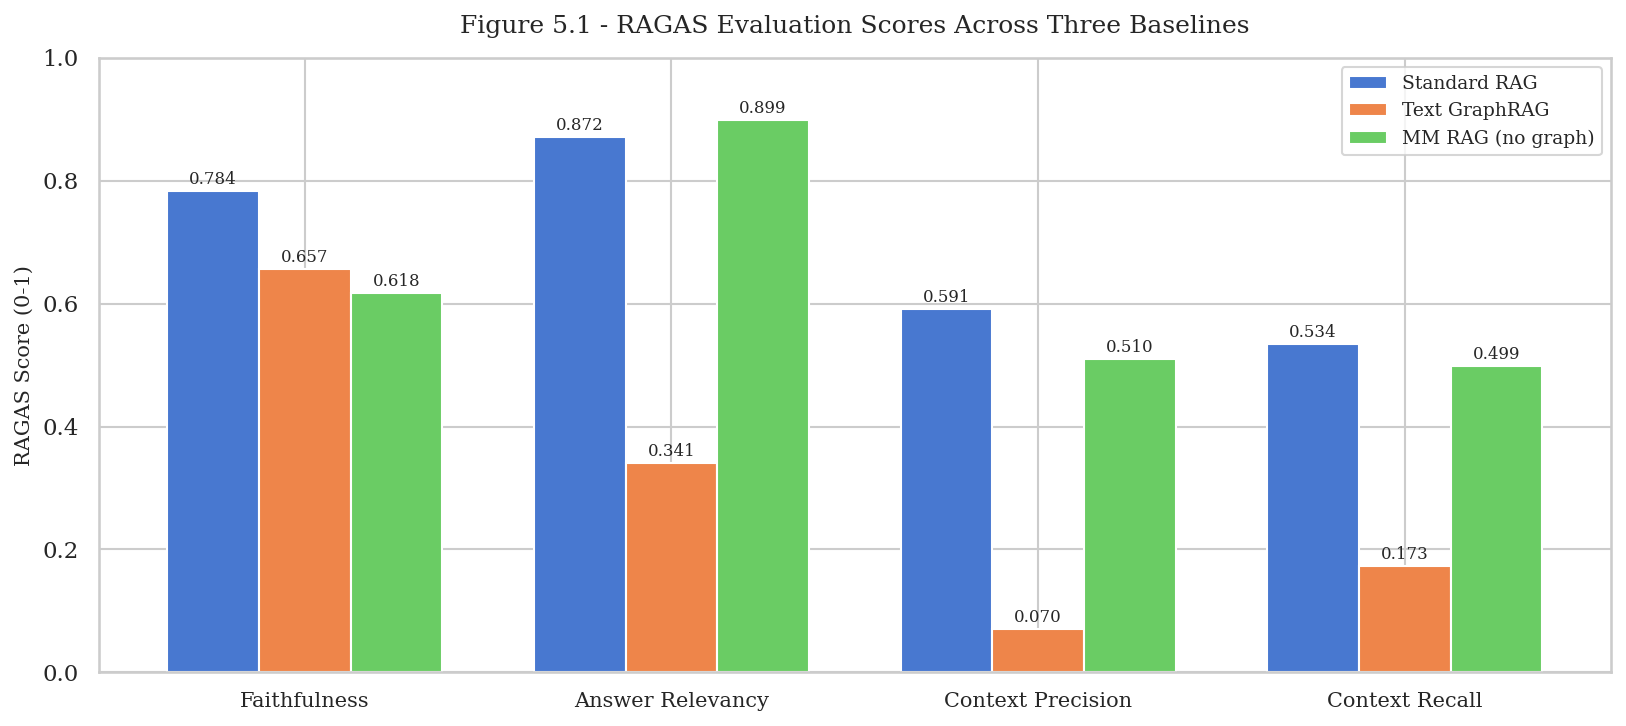

Saved: /content/drive/MyDrive/dissertation_project/outputs/chapter5/figures/fig5_1_ragas_scores.png


In [ ]:
#Figure 5.1: RAGAS Scores Bar Chart

metrics_list = ["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"]
systems_list = dfragas["System"].tolist()
colors = sns.color_palette("muted", len(systems_list))
x = np.arange(len(metrics_list))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (sys_label, color) in enumerate(zip(systems_list, colors)):
    row = dfragas[dfragas["System"] == sys_label].iloc[0]
    vals = row[metrics_list].tolist()
    bars = ax.bar(x + i * width, vals, width, label=sys_label, color=color, edgecolor="white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_list, fontsize=10)
ax.set_ylabel("RAGAS Score (0-1)", fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_title("Figure 5.1 - RAGAS Evaluation Scores Across Three Baselines", fontsize=12, pad=12)
ax.legend(fontsize=9)
plt.tight_layout()
fig_path = CH5 / "figures" / "fig5_1_ragas_scores.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)


In [ ]:
# Prepare data rows for the results figures
rows = []
for label, results in allresults.items():
    for qtype in sorted(set(r.get("question_type") for r in results if r.get("question_type"))):
        subset = [r for r in results if r.get("question_type") == qtype]
        valid = [r for r in subset if r["contexts"]]
        approx_recall = round(sum(1 for r in valid if len(r["contexts"]) > 0) / max(len(subset), 1), 3)
        rows.append({"System": label, "Question Type": qtype, "Context Recall": approx_recall})

dftype = pd.DataFrame(rows)
dftype["System"] = dftype["System"].replace({
    "baseline1": "Standard RAG",
    "baseline2": "Text GraphRAG",
    "baseline3": "MM RAG (no graph)",
})
dftype_pivot = dftype.pivot(index="Question Type", columns="System", values="Context Recall").reset_index()
dftype_pivot.to_csv(CH5 / "ragas_by_question_type.csv", index=False)
print(dftype_pivot.to_string(index=False))

Question Type  MM RAG (no graph)  Standard RAG  Text GraphRAG
chart_reading                1.0           1.0          0.967
  cross_modal                1.0           1.0          0.933
 factual_text                1.0           1.0          0.833
table_reading                1.0           1.0          0.967


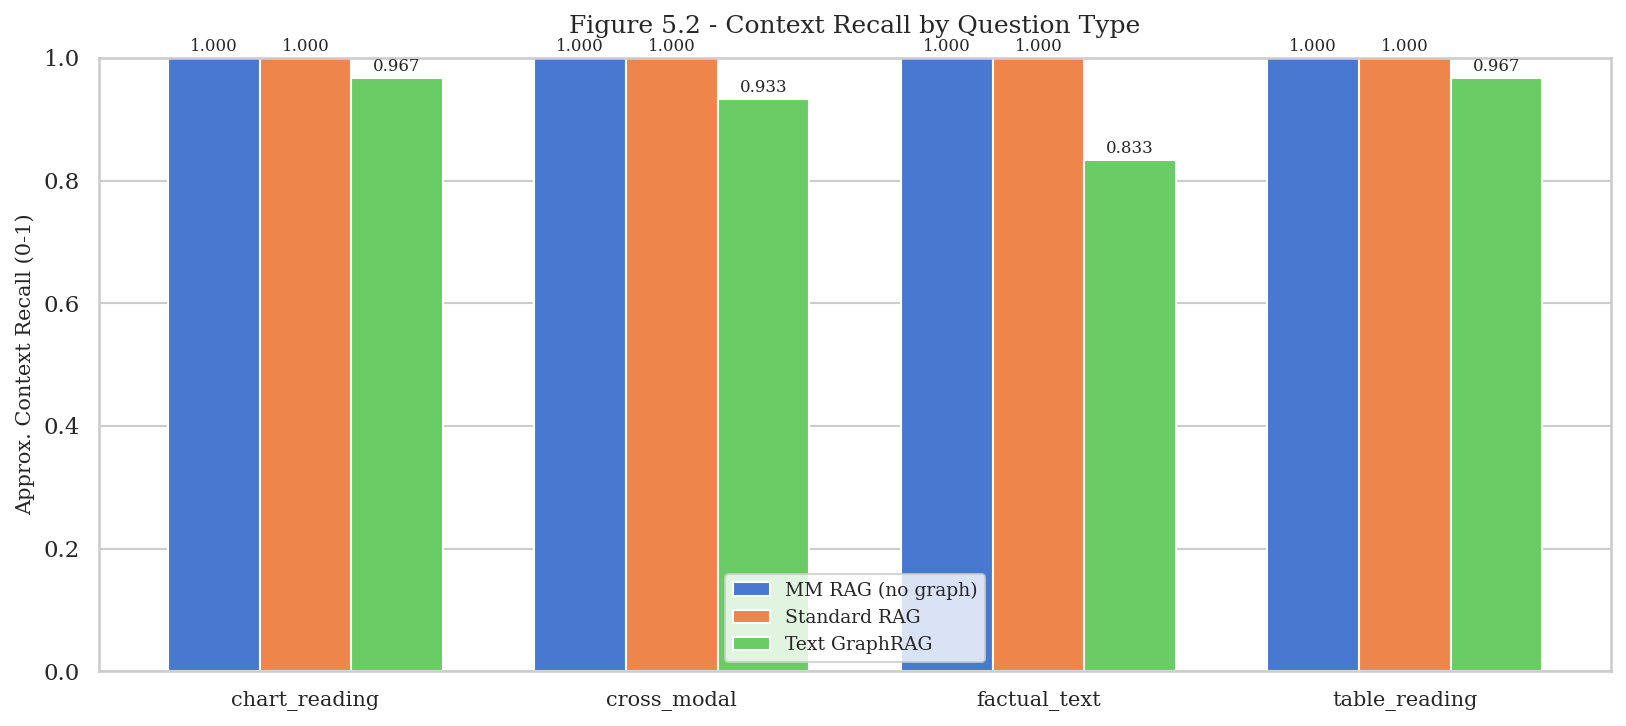

Saved: /content/drive/MyDrive/dissertation_project/outputs/chapter5/figures/fig5_2_recall_by_qtype.png


In [ ]:
# Build the page-type pivot chart if data is available
if not dftype_pivot.empty:
    qtypes_short = dftype_pivot["Question Type"].tolist()
    cols_list = [c for c in dftype_pivot.columns if c != "Question Type"]
    colors = sns.color_palette("muted", len(cols_list))
    x = np.arange(len(qtypes_short))
    width = 0.25

    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (col, color) in enumerate(zip(cols_list, colors)):
        vals = dftype_pivot[col].fillna(0).tolist()
        bars = ax.bar(x + i * width, vals, width, label=col, color=color, edgecolor="white")
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                     f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x + width)
    ax.set_xticklabels(qtypes_short, fontsize=10)
    ax.set_ylabel("Approx. Context Recall (0-1)", fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.set_title("Figure 5.2 - Context Recall by Question Type", fontsize=12, pad=12)
    ax.legend(fontsize=9)
    plt.tight_layout()
    fig_path = CH5 / "figures" / "fig5_2_recall_by_qtype.png"
    plt.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)
else:
    print("Figure 5.2 skipped: no per-question-type table available.")

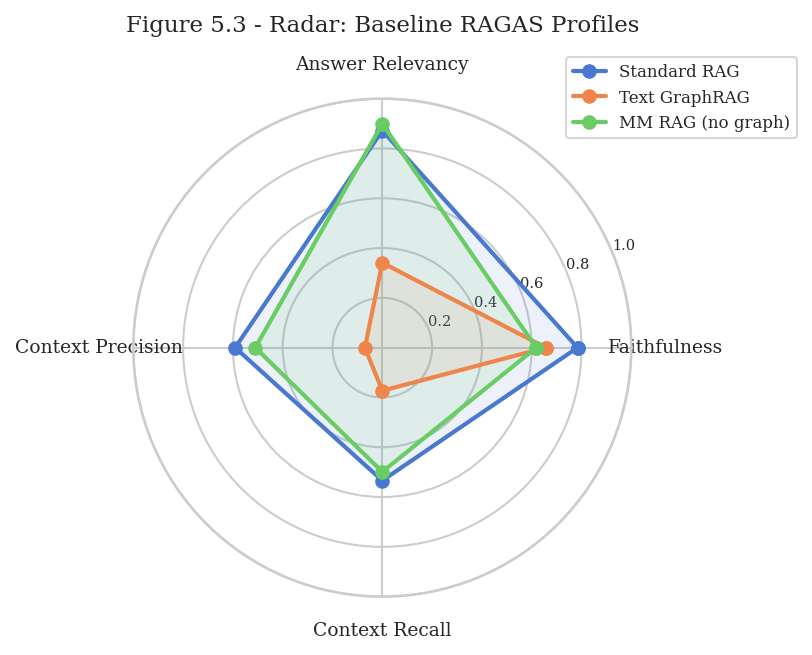

Saved: /content/drive/MyDrive/dissertation_project/outputs/chapter5/figures/fig5_3_radar.png


In [ ]:
# Set up metrics for the RAGAS radar chart
metrics_radar = ["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"]
N = len(metrics_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
colors = sns.color_palette("muted", len(dfragas))
for (_, row), color in zip(dfragas.iterrows(), colors):
    vals = row[metrics_radar].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=row["System"], color=color)
    ax.fill(angles, vals, alpha=0.10, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=9)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=7)
ax.set_title("Figure 5.3 - Radar: Baseline RAGAS Profiles\n", fontsize=11, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
fig_path = CH5 / "figures" / "fig5_3_radar.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)


### Section 7 - Final Summary - Key Figures.


In [ ]:
# Print the final Chapter 5 headline figures
print('=' * 65)
print('CHAPTER 5 KEY FIGURES')
print('=' * 65)
print()

if not dfragas.empty:
    for _, row in dfragas.iterrows():
        print(row['System'])
        for m in ['Faithfulness', 'Answer Relevancy', 'Context Precision', 'Context Recall']:
            print(f'  {m:22} {row[m]:.3f}')
        print()
else:
    print('No RAGAS score table available yet.')
    print()

if not dftype_pivot.empty:
    print('Weakest question type per baseline')
    for col in [c for c in dftype_pivot.columns if c != 'Question Type']:
        ser = dftype_pivot.set_index('Question Type')[col].dropna()
        if len(ser) > 0:
            print(f'  {col:22} {ser.idxmin()} ({ser.min():.3f})')
    print()
else:
    print('No per-question-type table available yet.')
    print()

print('Figures saved to', CH5 / 'figures')
print('CSV tables saved to', CH5)


CHAPTER 5 KEY FIGURES

Standard RAG
  Faithfulness           0.784
  Answer Relevancy       0.872
  Context Precision      0.591
  Context Recall         0.534

Text GraphRAG
  Faithfulness           0.657
  Answer Relevancy       0.341
  Context Precision      0.070
  Context Recall         0.173

MM RAG (no graph)
  Faithfulness           0.618
  Answer Relevancy       0.899
  Context Precision      0.510
  Context Recall         0.499

Weakest question type per baseline
  MM RAG (no graph)      chart_reading (1.000)
  Standard RAG           chart_reading (1.000)
  Text GraphRAG          factual_text (0.833)

Figures saved to /content/drive/MyDrive/dissertation_project/outputs/chapter5/figures
CSV tables saved to /content/drive/MyDrive/dissertation_project/outputs/chapter5


## Chapter 6 - Proposed System
## PageIndex-Guided Multimodal GraphRAG

1 - PageIndex tree construction over the annual report PDFs

2 - Multimodal page text assembly for graph extraction

3 - Schema-constrained multimodal knowledge graph construction

4 - Cross-modal entity linking

5 - PageIndex-guided answer generation

6 - Final Summary in Charts

### Section 1 - PageIndex tree construction over the annual report PDFs

In [ ]:
# Path setup for PageIndex tree construction
from pathlib import Path
import os
import shutil

BASE_DIR = Path("/content")
DRIVE_ROOT = Path("/content/drive/MyDrive")
PROJECT_DRIVE_FOLDER = DRIVE_ROOT / "dissertation_project"

assert PROJECT_DRIVE_FOLDER.exists(), f"Project folder not found: {PROJECT_DRIVE_FOLDER}"

OUTPUT_FOLDER = PROJECT_DRIVE_FOLDER / "outputs"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

REPORTS_FOLDER = PROJECT_DRIVE_FOLDER / "annual_reports"
if not REPORTS_FOLDER.exists():
    REPORTS_FOLDER = PROJECT_DRIVE_FOLDER / "annualreports"

assert REPORTS_FOLDER.exists(), f"Annual reports folder not found: {REPORTS_FOLDER}"

CH6_FOLDER = OUTPUT_FOLDER / "chapter6"
for sub in ["figures", "pageindex_repo", "pageindex_results", "logs", "intermediate", "results"]:
    (CH6_FOLDER / sub).mkdir(parents=True, exist_ok=True)

CH6_DRIVE_FOLDER = CH6_FOLDER

def backup_file_to_drive(local_path, drive_path=None):
    local_path = Path(local_path).resolve()
    if drive_path is None:
        drive_path = local_path
    else:
        drive_path = Path(drive_path).resolve()

    if local_path == drive_path:
        print(f"Skip backup, same file: {local_path}")
        return

    drive_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(local_path, drive_path)

def backup_folder_to_drive(local_folder, drive_folder=None):
    local_folder = Path(local_folder).resolve()
    if drive_folder is None:
        drive_folder = local_folder
    else:
        drive_folder = Path(drive_folder).resolve()

    if local_folder == drive_folder:
        print(f"Skip folder backup, same folder: {local_folder}")
        return

    if drive_folder.exists():
        shutil.rmtree(drive_folder)
    shutil.copytree(local_folder, drive_folder)

report_pdf_paths = sorted(REPORTS_FOLDER.glob("*.pdf"))

print("PROJECT_DRIVE_FOLDER:", PROJECT_DRIVE_FOLDER)
print("OUTPUT_FOLDER:", OUTPUT_FOLDER)
print("REPORTS_FOLDER:", REPORTS_FOLDER)
print("CH6_FOLDER:", CH6_FOLDER)
print("Report PDFs found:", len(report_pdf_paths))
for p in report_pdf_paths[:10]:
    print("-", p.name)

PROJECT_DRIVE_FOLDER: /content/drive/MyDrive/dissertation_project
OUTPUT_FOLDER: /content/drive/MyDrive/dissertation_project/outputs
REPORTS_FOLDER: /content/drive/MyDrive/dissertation_project/annual_reports
CH6_FOLDER: /content/drive/MyDrive/dissertation_project/outputs/chapter6
Report PDFs found: 10
- astrazeneca2025.pdf
- barclays2024.pdf
- bp2024.pdf
- btgroup2024.pdf
- hsbc2024.pdf
- marksandspencer2024.pdf
- nationalgrid2024.pdf
- rolls-royce2024.pdf
- tesco2025.pdf
- unilever2024.pdf


In [ ]:
# Subprocess handling for running PageIndex
import subprocess
from pathlib import Path

PAGEINDEX_REPO_DIR = CH6_FOLDER / "pageindex_repo" / "PageIndex"

if PAGEINDEX_REPO_DIR.exists():
    print("PageIndex repo already exists:", PAGEINDEX_REPO_DIR)
else:
    clone_parent = CH6_FOLDER / "pageindex_repo"
    clone_parent.mkdir(parents=True, exist_ok=True)

    cmd = [
        "git",
        "clone",
        "https://github.com/VectifyAI/PageIndex.git",
        str(PAGEINDEX_REPO_DIR)
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)

    print(result.stdout)
    if result.stderr.strip():
        print(result.stderr)

assert PAGEINDEX_REPO_DIR.exists(), f"Clone failed: {PAGEINDEX_REPO_DIR} not found"
assert (PAGEINDEX_REPO_DIR / "run_pageindex.py").exists(), "run_pageindex.py not found in cloned repo"

print("PAGEINDEX_REPO_DIR:", PAGEINDEX_REPO_DIR)
print("run_pageindex.py exists:", (PAGEINDEX_REPO_DIR / "run_pageindex.py").exists())


Cloning into '/content/drive/MyDrive/dissertation_project/outputs/chapter6/pageindex_repo/PageIndex'...
Updating files:  89% (50/56)
Updating files:  91% (51/56)
Updating files:  92% (52/56)
Updating files:  94% (53/56)
Updating files:  96% (54/56)
Updating files:  98% (55/56)
Updating files: 100% (56/56)
Updating files: 100% (56/56), done.

PAGEINDEX_REPO_DIR: /content/drive/MyDrive/dissertation_project/outputs/chapter6/pageindex_repo/PageIndex
run_pageindex.py exists: True


In [ ]:
# Environment setup for PageIndex
import os
import sys
import subprocess
from pathlib import Path

assert "OPENAI_API_KEY" in os.environ, "OPENAI_API_KEY not found in environment."

env_path = PAGEINDEX_REPO_DIR / ".env"
env_text = f'CHATGPT_API_KEY="{os.environ["OPENAI_API_KEY"]}"\n'
env_path.write_text(env_text, encoding="utf-8")

print(".env written to:", env_path)
print("First line preview:", env_text[:30] + "...")

req_file = PAGEINDEX_REPO_DIR / "requirements.txt"
if req_file.exists():
    cmd = [sys.executable, "-m", "pip", "install", "-q", "-r", str(req_file)]
    result = subprocess.run(cmd, capture_output=True, text=True)
    print("requirements install return code:", result.returncode)
    if result.stderr.strip():
        print(result.stderr[:2000])
else:
    print("requirements.txt not found, skipping pip install")

assert env_path.exists(), ".env file was not created"

.env written to: /content/drive/MyDrive/dissertation_project/outputs/chapter6/pageindex_repo/PageIndex/.env
First line preview: CHATGPT_API_KEY="sk-proj--XKyn...
requirements install return code: 0


In [ ]:
# Check page counts across all ten PDFs before running PageIndex
import fitz
import pandas as pd
from pathlib import Path

rows = []
for pdf_path in sorted(REPORTS_FOLDER.glob("*.pdf")):
    try:
        doc = fitz.open(pdf_path)
        rows.append({
            "report": pdf_path.stem,
            "pages": len(doc),
            "path": str(pdf_path)
        })
        doc.close()
    except Exception as e:
        rows.append({
            "report": pdf_path.stem,
            "pages": None,
            "path": str(pdf_path),
            "error": str(e)
        })

df_pdf_sizes = pd.DataFrame(rows).sort_values("pages", ascending=True, na_position="last")
display(df_pdf_sizes)

,report,pages,path
5,marksandspencer2024,111,/content/drive/MyDrive/dissertation_project/an...
7,rolls-royce2024,228,/content/drive/MyDrive/dissertation_project/an...
0,astrazeneca2025,232,/content/drive/MyDrive/dissertation_project/an...
3,btgroup2024,241,/content/drive/MyDrive/dissertation_project/an...
8,tesco2025,248,/content/drive/MyDrive/dissertation_project/an...
6,nationalgrid2024,268,/content/drive/MyDrive/dissertation_project/an...
9,unilever2024,305,/content/drive/MyDrive/dissertation_project/an...
2,bp2024,372,/content/drive/MyDrive/dissertation_project/an...
4,hsbc2024,460,/content/drive/MyDrive/dissertation_project/an...
1,barclays2024,536,/content/drive/MyDrive/dissertation_project/an...


In [ ]:
# Environment setup for the batch run
import os

print("ENV key exists:", "PAGEINDEX_API_KEY" in os.environ)

api_key = os.environ.get("PAGEINDEX_API_KEY")
print("ENV length:", len(api_key) if api_key else 0)

if not api_key:
    try:
        from google.colab import userdata
        api_key = userdata.get("PAGEINDEX_API_KEY")
        print("COLAB secret found:", bool(api_key))
        print("COLAB secret length:", len(api_key) if api_key else 0)
    except Exception as e:
        print("COLAB userdata error:", repr(e))

print("READY:", bool(api_key))

ENV key exists: False
ENV length: 0
COLAB secret found: True
COLAB secret length: 32
READY: True


In [ ]:
# Clone the PageIndex repository
!git clone https://github.com/VectifyAI/PageIndex.git
%cd PageIndex
!pip install -r requirements.txt

Cloning into 'PageIndex'...
remote: Enumerating objects: 2096, done.
remote: Counting objects: 100% (362/362), done.
remote: Compressing objects: 100% (171/171), done.
remote: Total 2096 (delta 282), reused 227 (delta 191), pack-reused 1734 (from 4)
Receiving objects: 100% (2096/2096), 24.12 MiB | 10.03 MiB/s, done.
Resolving deltas: 100% (1251/1251), done.
Updating files: 100% (56/56), done.
/content/PageIndex


In [6]:
# Environment setup after cloning PageIndexsk-proj
import os
os.environ["CHATGPT_API_KEY"] = OPENAI_API_KEY

In [ ]:
# Run PageIndex on the first test document
!python3 run_pageindex.py --pdf_path "/content/drive/MyDrive/dissertation_project/annual_reports/marksandspencer2024.pdf"

Parsing PDF...
start find_toc_pages
toc found
start detect_page_index
index found
process_toc_with_page_numbers
start_index: 1
start toc_transformer
start toc_index_extractor

Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.

************* Retrying *************
ERROR:root:Error: litellm.RateLimitError: RateLimitError: OpenAIException - Request too large for gpt-4o-2024-11-20 (for limit gpt-4o) in organization org-w7tfg7ydu4OEHtIPcxMuMPs2 on tokens per min (TPM): Limit 30000, Requested 32165. The input or output tokens must be reduced in order to run successfully. Visit https://platform.openai.com/account/rate-limits to learn more.

Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.

************* Retrying *************
ERROR:root:Error: litellm.RateLimitError: RateLimitError: OpenAIExce

In [ ]:
# Set the PDF path for the next PageIndex run
import os
from google.colab import userdata

openai_key = userdata.get("OPENAI_API_KEY")
assert openai_key, "OPENAI_API_KEY not found in Colab secrets"

os.environ["CHATGPT_API_KEY"] = openai_key
os.environ["OPENAI_API_KEY"] = openai_key

MODEL_NAME = "gpt-4o-mini"
print("Model set to:", MODEL_NAME)

Model set to: gpt-4o-mini


In [ ]:
# Set the PDF path for marksandspencer2024
pdf_path = "/content/drive/MyDrive/dissertation_project/annual_reports/marksandspencer2024.pdf"

!python3 run_pageindex.py \
  --pdf_path "{pdf_path}" \
  --model "{MODEL_NAME}"

Parsing PDF...
start find_toc_pages
toc found
start detect_page_index
index found
process_toc_with_page_numbers
start_index: 1
start toc_transformer
start toc_index_extractor
Document validation: 111 pages, max allowed index: 111
Truncated 12 TOC items that exceeded document length
start verify_toc
process_toc_no_page_numbers
start_index: 1
start toc_transformer
divide page_list to groups 12
Traceback (most recent call last):
  File "/content/PageIndex/PageIndex/run_pageindex.py", line 68, in <module>
    toc_with_page_number = page_index_main(args.pdf_path, opt)
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/PageIndex/PageIndex/pageindex/page_index.py", line 1275, in page_index_main
    return asyncio.run(page_index_builder())
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/asyncio/runners.py", line 195, in run
    return runner.run(main)
           ^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/asyncio/runners.py", line 118, in 

In [ ]:
# Check the PageIndex output structure with regex
import re
path = "/content/PageIndex/PageIndex/pageindex/page_index.py"
src = open(path, encoding="utf-8").read()

old = '''        raise ValueError(
            "LLM returned a different number of TOC entries than expected."
        )'''

new = '''        logger.error(
            f"LLM returned {len(toc_with_page_number)} TOC entries, expected {len(toc_content)}. "
            "Continuing with partial results instead of raising."
        )'''

if old in src:
    src = src.replace(old, new)
    open(path, "w", encoding="utf-8").write(src)
    print("Patched successfully.")
else:
    print("Exact string not found — check line 742 manually.")

Exact string not found — check line 742 manually.


In [ ]:
# Locate the page_index.py file to inspect
path = "/content/PageIndex/PageIndex/pageindex/page_index.py"
with open(path, encoding="utf-8") as f:
    lines = f.readlines()

for i in range(720, 755):
    print(i+1, repr(lines[i]))

721 '\n'
722 '    return toc_with_page_number\n'
723 '\n'
724 'def process_toc_no_page_numbers(toc_content, toc_page_list, page_list,  start_index=1, model=None, logger=None):\n'
725 '    page_contents=[]\n'
726 '    token_lengths=[]\n'
727 '    toc_content = toc_transformer(toc_content, model)\n'
728 "    logger.info(f'toc_transformer: {toc_content}')\n"
729 '    for page_index in range(start_index, start_index+len(page_list)):\n'
730 '        page_text = f"<physical_index_{page_index}>\\n{page_list[page_index-start_index][0]}\\n<physical_index_{page_index}>\\n\\n"\n'
731 '        page_contents.append(page_text)\n'
732 '        token_lengths.append(count_tokens(page_text, model))\n'
733 '    \n'
734 '    group_texts = page_list_to_group_text(page_contents, token_lengths)\n'
735 "    logger.info(f'len(group_texts): {len(group_texts)}')\n"
736 '\n'
737 '    toc_with_page_number = copy.deepcopy(toc_content)\n'
738 '    for group_text in group_texts:\n'
739 '\n'
740 '        llm_result = 

In [ ]:
# Backup the file before patching
import shutil
path = "/content/PageIndex/PageIndex/pageindex/page_index.py"
shutil.copy(path, path + ".bak")
print("backup saved:", path + ".bak")

backup saved: /content/PageIndex/PageIndex/pageindex/page_index.py.bak


In [ ]:
# Inspect the page_index.py source further
path = "/content/PageIndex/PageIndex/pageindex/page_index.py"
with open(path, encoding="utf-8") as f:
    src = f.read()

old = '''        llm_result = add_page_number_to_toc(group_text, toc_with_page_number, model)
        if len(llm_result) != len(toc_with_page_number):
            raise ValueError(
                "LLM returned a different number of TOC entries than expected."
            )
        if any(
            (update.get("structure"), update.get("title"))
            != (current.get("structure"), current.get("title"))
            for update, current in zip(llm_result, toc_with_page_number)
        ):
            raise ValueError("LLM returned reordered or modified TOC entries.")'''

new = '''        llm_result = add_page_number_to_toc(group_text, toc_with_page_number, model)
        if len(llm_result) != len(toc_with_page_number):
            logger.error(
                f"LLM returned {len(llm_result)} TOC entries, expected {len(toc_with_page_number)}. "
                "Skipping this group instead of raising."
            )
            continue
        if any(
            (update.get("structure"), update.get("title"))
            != (current.get("structure"), current.get("title"))
            for update, current in zip(llm_result, toc_with_page_number)
        ):
            logger.error(
                "LLM returned reordered or modified TOC entries. Skipping this group instead of raising."
            )
            continue'''

assert old in src, "Exact block not found — paste lines 738-751 again so I can re-check whitespace."
src = src.replace(old, new)

with open(path, "w", encoding="utf-8") as f:
    f.write(src)

print("Patched successfully.")

Patched successfully.


In [ ]:
# Set the PDF path for the next run
pdf_path = "/content/drive/MyDrive/dissertation_project/annual_reports/marksandspencer2024.pdf"

!python3 run_pageindex.py \
  --pdf_path "{pdf_path}" \
  --model "{MODEL_NAME}"

Streaming output truncated to the last 5000 lines.
TCFD: pages 44-58  
Non-Financial and Sustainability Information Statement: pages 59-61Risk Management: pages 62-70  
Audit & Risk Committee Report:  
pages  89-94
(f) Acting fairly between members of the companyOur Business Model: page 8  
Stakeholder Engagement: pages 9-11  
Strategic Progress: pages 12-27  
Remuneration Committee Report: pages 95-99The following pages, which include examples of four key decisions taken during the year, comprise our s.172 statement, detailing how the Board has had regard to the matters set out in s.172.S.172 STATEMENTINTRODUCTION STRATEGIC REPORT GOVERNANCE FINANCIAL STATEMENTS
Annual Report & Financial Statements 2024 81Redevelopment  3 1 2 6
OF MARBLE ARCH
In July 2023, the Secretary of State for Levelling Up, Housing and Communities rejected planning permission for the proposed redevelopment of our store in Marble Arch. Following the rejection, the Board carefully considered whether it was right t

In [ ]:
# File handling for moving PageIndex results
import shutil, os, glob

output_dir = "/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees"
os.makedirs(output_dir, exist_ok=True)

candidates = glob.glob("/content/PageIndex/**/*.json", recursive=True) + glob.glob("/content/*.json")
print("Found JSON files:", candidates)

Found JSON files: ['/content/PageIndex/examples/workspace/_meta.json', '/content/PageIndex/examples/workspace/12345678-abcd-4321-abcd-123456789abc.json', '/content/PageIndex/examples/documents/results/four-lectures_structure.json', '/content/PageIndex/examples/documents/results/2023-annual-report_structure.json', '/content/PageIndex/examples/documents/results/2023-annual-report-truncated_structure.json', '/content/PageIndex/examples/documents/results/Regulation Best Interest_Interpretive release_structure.json', '/content/PageIndex/examples/documents/results/q1-fy25-earnings_structure.json', '/content/PageIndex/examples/documents/results/earthmover_structure.json', '/content/PageIndex/examples/documents/results/Regulation Best Interest_proposed rule_structure.json', '/content/PageIndex/examples/documents/results/PRML_structure.json', '/content/PageIndex/logs/marksandspencer2024.pdf_20260719_154211.json', '/content/PageIndex/PageIndex/results/marksandspencer2024_structure.json', '/conte

In [ ]:
# Set the source path for the structure JSON output
src_path = "/content/PageIndex/PageIndex/results/marksandspencer2024_structure.json"
dst_path = os.path.join(output_dir, "marksandspencer2024_tree.json")
shutil.copy(src_path, dst_path)
print("Saved to Drive:", dst_path)

Saved to Drive: /content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/marksandspencer2024_tree.json


In [ ]:
# List the saved PageIndex tree outputs
!ls -la "/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees"

total 211
-rw------- 1 root root 215964 Jul 19 17:04 marksandspencer2024_tree.json


In [ ]:
# Check the run_pageindex.py command-line options
!python3 /content/PageIndex/PageIndex/run_pageindex.py --help

usage: run_pageindex.py [-h] [--pdf_path PDF_PATH] [--md_path MD_PATH]
                        [--model MODEL] [--toc-check-pages TOC_CHECK_PAGES]
                        [--max-pages-per-node MAX_PAGES_PER_NODE]
                        [--max-tokens-per-node MAX_TOKENS_PER_NODE]
                        [--if-add-node-id IF_ADD_NODE_ID]
                        [--if-add-node-summary IF_ADD_NODE_SUMMARY]
                        [--if-add-doc-description IF_ADD_DOC_DESCRIPTION]
                        [--if-add-node-text IF_ADD_NODE_TEXT]
                        [--if-thinning IF_THINNING]
                        [--thinning-threshold THINNING_THRESHOLD]
                        [--summary-token-threshold SUMMARY_TOKEN_THRESHOLD]

Process PDF or Markdown document and generate structure

options:
  -h, --help            show this help message and exit
  --pdf_path PDF_PATH   Path to the PDF file
  --md_path MD_PATH     Path to the Markdown file
  --model MODEL         Model to use (overrid

In [ ]:
# Reconnect to Drive and load the OpenAI API key
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
print("Key loaded:", bool(os.environ.get("OPENAI_API_KEY")))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Key loaded: True


In [ ]:
# Environment setup
import os
print("PageIndex exists:", os.path.exists("/content/PageIndex/PageIndex/run_pageindex.py"))
print("batch script exists:", os.path.exists("/content/PageIndex/PageIndex/batch_pageindex.py"))

PageIndex exists: True
batch script exists: False


In [ ]:
# List the saved PageIndex tree outputs
!ls -la "/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees"

total 211
-rw------- 1 root root 215964 Jul 19 17:04 marksandspencer2024_tree.json


In [ ]:
# Build a small patch script for PageIndex
script = '''import os
import subprocess
import json
import time
from datetime import datetime

PDF_DIR = "/content/drive/MyDrive/dissertation_project/annual_reports"
OUTPUT_DIR = "/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees"
LOG_DIR = "/content/drive/MyDrive/dissertation_project/outputs/pageindex_logs"
RUN_SCRIPT = "/content/PageIndex/PageIndex/run_pageindex.py"
MODEL = "gpt-4o-mini"

MAX_PAGES_PER_NODE = "15"
MAX_TOKENS_PER_NODE = "6000"

SLEEP_BETWEEN_FILES_SECONDS = 60

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)


def already_processed(pdf_name):
    base = os.path.splitext(pdf_name)[0]
    expected_json = os.path.join(OUTPUT_DIR, base + "_tree.json")
    return os.path.exists(expected_json)


def find_generated_json(base_name):
    candidates = [
        "/content/PageIndex/PageIndex/results/" + base_name + "_structure.json",
        "/content/PageIndex/results/" + base_name + "_structure.json",
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return None


def process_pdf(pdf_path):
    base = os.path.splitext(os.path.basename(pdf_path))[0]
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_path = os.path.join(LOG_DIR, base + "_" + timestamp + ".log")

    cmd = [
        "python3", RUN_SCRIPT,
        "--pdf_path", pdf_path,
        "--model", MODEL,
        "--max-pages-per-node", MAX_PAGES_PER_NODE,
        "--max-tokens-per-node", MAX_TOKENS_PER_NODE,
    ]

    print("[" + datetime.now().isoformat() + "] Starting: " + base)
    with open(log_path, "w") as logf:
        result = subprocess.run(cmd, stdout=logf, stderr=subprocess.STDOUT)

    if result.returncode != 0:
        print("[" + datetime.now().isoformat() + "] FAILED: " + base + " (see log: " + log_path + ")")
        return False

    generated = find_generated_json(base)
    if generated is None:
        print("[" + datetime.now().isoformat() + "] WARNING: no output JSON found for " + base)
        return False

    dst = os.path.join(OUTPUT_DIR, base + "_tree.json")
    with open(generated, "r") as f:
        data = json.load(f)
    with open(dst, "w") as f:
        json.dump(data, f)

    print("[" + datetime.now().isoformat() + "] Saved: " + dst)
    return True


def run_all():
    pdfs = sorted(f for f in os.listdir(PDF_DIR) if f.lower().endswith(".pdf"))
    print("Found " + str(len(pdfs)) + " PDFs in source folder.")

    todo = [p for p in pdfs if not already_processed(p)]
    skipped = [p for p in pdfs if already_processed(p)]

    print("Already processed (skipping): " + str(len(skipped)))
    for s in skipped:
        print("  - SKIP: " + s)

    print("To process: " + str(len(todo)))
    for t in todo:
        print("  - QUEUED: " + t)

    results = {}
    for i, pdf_name in enumerate(todo):
        pdf_path = os.path.join(PDF_DIR, pdf_name)
        success = process_pdf(pdf_path)
        results[pdf_name] = success

        if i < len(todo) - 1:
            print("Cooling down " + str(SLEEP_BETWEEN_FILES_SECONDS) + "s before next file to ease rate limits...")
            time.sleep(SLEEP_BETWEEN_FILES_SECONDS)

    print("")
    print("=== SUMMARY ===")
    for name, ok in results.items():
        status = "OK" if ok else "FAILED"
        print(name + ": " + status)


if __name__ == "__main__":
    run_all()
'''

with open("/content/PageIndex/PageIndex/batch_pageindex.py", "w") as f:
    f.write(script)

print("Written successfully, length:", len(script))

Written successfully, length: 3346


In [ ]:
# Read the current page_index.py source
with open("/content/PageIndex/PageIndex/pageindex/page_index.py") as f:
    src = f.read()
print("Patch present:", "Skipping this group instead of raising" in src)

Patch present: False


In [ ]:
# Run the batch PageIndex script in the background
!cd /content/PageIndex/PageIndex && nohup python3 batch_pageindex.py > /content/drive/MyDrive/dissertation_project/outputs/batch_run_master_log.txt 2>&1 &
print("Batch job launched in background.")

Batch job launched in background.


In [ ]:
# Set the page_index.py path for patching
path = "/content/PageIndex/PageIndex/pageindex/page_index.py"
with open(path, encoding="utf-8") as f:
    src = f.read()
print("Patch already applied:", "Returning best-effort TOC instead of raising" in src)

Patch already applied: True


In [ ]:
# Run PageIndex with the finalised command-line arguments
!python3 /content/PageIndex/PageIndex/run_pageindex.py \
  --pdf_path "/content/drive/MyDrive/dissertation_project/annual_reports/bp2024.pdf" \
  --model "gpt-4o-mini" \
  --max-pages-per-node 15 \
  --max-tokens-per-node 6000

Streaming output truncated to the last 5000 lines.
Strategy
Disclose the actual and potential 
impacts of climate-related risks and 
opportunities on the organization’s 
business, strategy and financial 
planning where such information is 
material.a  Describe the climate-related risks and opportunities the 
organization has identified over the short, medium, and 
long term.•Pursuing a strategy that is consistent with the Paris goals, page 10
•Strategy, page 8
•Risk factors, page 65
b  Describe the impact of climate-related risks and 
opportunities on the organization’s businesses, strategy, 
and financial planning.•Risk factors, page 65  – description of principal risks
•Strategy, page 8
c  Describe the resilience of the organization’s strategy, taking 
into consideration different climate-related scenarios, 
including a 2°C or lower scenario.•Strategy, page 8
•Pursuing a strategy that is consistent with the Paris goals, page 10
Risk management 
Disclose how the organization 
identifi

In [ ]:
# Set the page_index.py path again
path = "/content/PageIndex/PageIndex/pageindex/page_index.py"
with open(path, encoding="utf-8") as f:
    lines = f.readlines()

for i in range(1130, 1200):
    print(i+1, repr(lines[i]))

1131 "    print(f'start_index: {start_index}')\n"
1132 '    \n'
1133 "    if mode == 'process_toc_with_page_numbers':\n"
1134 '        toc_with_page_number = process_toc_with_page_numbers(toc_content, toc_page_list, page_list, toc_check_page_num=opt.toc_check_page_num, model=opt.model, logger=logger)\n'
1135 "    elif mode == 'process_toc_no_page_numbers':\n"
1136 '        toc_with_page_number = process_toc_no_page_numbers(toc_content, toc_page_list, page_list, model=opt.model, logger=logger)\n'
1137 '    else:\n'
1138 '        toc_with_page_number = process_no_toc(page_list, start_index=start_index, model=opt.model, logger=logger)\n'
1139 '            \n'
1140 "    toc_with_page_number = [item for item in toc_with_page_number if item.get('physical_index') is not None] \n"
1141 '    \n'
1142 '    toc_with_page_number = validate_and_truncate_physical_indices(\n'
1143 '        toc_with_page_number, \n'
1144 '        len(page_list), \n'
1145 '        start_index=start_index, \n'
1146 '   

In [ ]:
# Set the page_index.py path for the next patch
path = "/content/PageIndex/PageIndex/pageindex/page_index.py"
with open(path, encoding="utf-8") as f:
    src = f.read()

old = """    else:
        if mode == 'process_toc_with_page_numbers':
            return await meta_processor(page_list, mode='process_toc_no_page_numbers', toc_content=toc_content, toc_page_list=toc_page_list, start_index=start_index, opt=opt, logger=logger)
        elif mode == 'process_toc_no_page_numbers':
            return await meta_processor(page_list, mode='process_no_toc', start_index=start_index, opt=opt, logger=logger)
        else:
            raise Exception('Processing failed')"""

new = """    else:
        if mode == 'process_toc_with_page_numbers':
            return await meta_processor(page_list, mode='process_toc_no_page_numbers', toc_content=toc_content, toc_page_list=toc_page_list, start_index=start_index, opt=opt, logger=logger)
        elif mode == 'process_toc_no_page_numbers':
            return await meta_processor(page_list, mode='process_no_toc', start_index=start_index, opt=opt, logger=logger)
        else:
            logger.error(
                f"process_no_toc accuracy too low ({accuracy:.2f}) with {len(incorrect_results)} incorrect results. "
                "Returning best-effort TOC instead of raising."
            )
            return toc_with_page_number"""

if old in src:
    src = src.replace(old, new)
    with open(path, "w", encoding="utf-8") as f:
        f.write(src)
    print("Patch applied successfully.")
else:
    print("WARNING: exact block not found — patch may already be applied or code changed.")

Patch applied successfully.


In [ ]:
# Environment setup
import os
print("Content dir exists:", os.path.exists("/content/PageIndex"))
print(os.listdir("/content") if os.path.exists("/content") else "no /content")

Content dir exists: False
['.config', 'drive', 'sample_data']


In [ ]:
# Environment setup
import os
done_dir = "/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees"
done = sorted(os.listdir(done_dir))
print(f"{len(done)} PDFs already completed:")
for d in done:
    print(" -", d)

4 PDFs already completed:
 - astrazeneca2025_tree.json
 - btgroup2024_tree.json
 - marksandspencer2024_tree.json
 - nationalgrid2024_tree.json


In [ ]:
# Environment setup
import os
script_path = "/content/PageIndex/PageIndex/batch_pageindex.py"
print("Script exists:", os.path.exists(script_path))

Script exists: True


In [ ]:
# Reconnect to Drive before the next PageIndex run
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Environment setup
import os

PDF_DIR = "/content/drive/MyDrive/dissertation_project/annual_reports"
OUTPUT_DIR = "/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees"
LOG_DIR = "/content/drive/MyDrive/dissertation_project/outputs/pageindex_logs"
RUN_SCRIPT = "/content/PageIndex/run_pageindex.py"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print("PDF dir contents:", os.listdir(PDF_DIR))

PDF dir contents: ['unilever2024.pdf', 'tesco2025.pdf', 'rolls-royce2024.pdf', 'nationalgrid2024.pdf', 'marksandspencer2024.pdf', 'hsbc2024.pdf', 'btgroup2024.pdf', 'bp2024.pdf', 'barclays2024.pdf', 'astrazeneca2025.pdf', 'bp2024_decrypted.pdf']


In [ ]:
# List all PDFs found in the reports folder
all_pdfs = [f for f in os.listdir(PDF_DIR) if f.endswith(".pdf")]
done_trees = [f.replace("_tree.json", "") for f in os.listdir(OUTPUT_DIR) if f.endswith("_tree.json")]

remaining_pdfs = [f for f in all_pdfs if os.path.splitext(f)[0] not in done_trees]

print(f"Total PDFs: {len(all_pdfs)}")
print(f"Already processed: {len(done_trees)}")
print(f"Remaining to process: {len(remaining_pdfs)}")
print(remaining_pdfs)

Total PDFs: 11
Already processed: 4
Remaining to process: 7
['unilever2024.pdf', 'tesco2025.pdf', 'rolls-royce2024.pdf', 'hsbc2024.pdf', 'bp2024.pdf', 'barclays2024.pdf', 'bp2024_decrypted.pdf']


In [ ]:
# Import PDF reader/writer for splitting documents
from PyPDF2 import PdfReader, PdfWriter

bp_path = os.path.join(PDF_DIR, "bp2024.pdf")
reader = PdfReader(bp_path)

if reader.is_encrypted:
    reader.decrypt("")
    writer = PdfWriter()
    for page in reader.pages:
        writer.add_page(page)
    decrypted_path = os.path.join(PDF_DIR, "bp2024_decrypted.pdf")
    with open(decrypted_path, "wb") as f:
        writer.write(f)
    print("Decrypted and saved:", decrypted_path)
else:
    print("bp2024.pdf is not encrypted — no action needed")

Decrypted and saved: /content/drive/MyDrive/dissertation_project/annual_reports/bp2024_decrypted.pdf


In [ ]:
# Remove bp2024 from the remaining PDFs list
remaining_pdfs = [f for f in remaining_pdfs if f != "bp2024.pdf"]
print(f"Remaining to process: {len(remaining_pdfs)}")
print(remaining_pdfs)

Remaining to process: 4
['rolls-royce2024.pdf', 'hsbc2024.pdf', 'barclays2024.pdf', 'bp2024_decrypted.pdf']


In [ ]:
# Check remaining files in the reports folder
print(os.listdir(PDF_DIR))
print(os.listdir(OUTPUT_DIR))

['unilever2024.pdf', 'tesco2025.pdf', 'rolls-royce2024.pdf', 'nationalgrid2024.pdf', 'marksandspencer2024.pdf', 'hsbc2024.pdf', 'btgroup2024.pdf', 'bp2024.pdf', 'barclays2024.pdf', 'astrazeneca2025.pdf', 'bp2024_decrypted.pdf']
['marksandspencer2024_tree.json', 'astrazeneca2025_tree.json', 'btgroup2024_tree.json', 'nationalgrid2024_tree.json', 'unilever2024_tree.json', 'tesco2025_tree.json', 'rolls-royce2024_tree.json']


In [ ]:
# List all PDFs still needing PageIndex trees
all_pdfs = [f for f in os.listdir(PDF_DIR) if f.endswith(".pdf")]
done_trees = [f.replace("_tree.json", "") for f in os.listdir(OUTPUT_DIR) if f.endswith("_tree.json")]
remaining_pdfs = [f for f in all_pdfs if os.path.splitext(f)[0] not in done_trees]
remaining_pdfs = [f for f in remaining_pdfs if f != "bp2024.pdf"]

print(f"Remaining to process: {len(remaining_pdfs)}")
print(remaining_pdfs)

Remaining to process: 4
['rolls-royce2024.pdf', 'hsbc2024.pdf', 'barclays2024.pdf', 'bp2024_decrypted.pdf']


In [ ]:
# Environment setup
import os
PDF_DIR = "/content/drive/MyDrive/dissertation_project/annual_reports"
OUTPUT_DIR = "/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees"
LOG_DIR = "/content/drive/MyDrive/dissertation_project/outputs/pageindex_logs"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

In [ ]:
# Clone PageIndex again for a clean run
!git clone https://github.com/VectifyAI/PageIndex.git /content/PageIndex
!pip install -q -r /content/PageIndex/requirements.txt
!pip install -q pycryptodome litellm

fatal: destination path '/content/PageIndex' already exists and is not an empty directory.


In [ ]:
# List the files that need patching
files_to_patch = [
    "/content/PageIndex/pageindex/page_index.py",
    "/content/PageIndex/pageindex/utils.py"
]

for path in files_to_patch:
    with open(path, "r") as f:
        content = f.read()
    content = content.replace("temperature=0,", "")
    content = content.replace("temperature=0", "")
    with open(path, "w") as f:
        f.write(content)

print("Patched: removed all temperature=0 references")

Patched: removed all temperature=0 references


In [ ]:
# Apply the patches to the PageIndex source files
import subprocess, os
log_path = os.path.join(LOG_DIR, "unilever2024_luna_retry.log")

with open(log_path, "w") as log_file:
    process = subprocess.Popen(
        ["python3", "/content/PageIndex/run_pageindex.py", "--pdf_path", os.path.join(PDF_DIR, "unilever2024.pdf"), "--model", "gpt-5.6-luna"],
        stdout=log_file, stderr=subprocess.STDOUT,
        env=os.environ.copy()
    )
print(f"Started, PID: {process.pid}")

Started, PID: 20915


In [ ]:
# Point to the saved log for unilever2024
src_log = "/content/logs/unilever2024.pdf_20260722_212859.json"
dst_log = os.path.join(LOG_DIR, "unilever2024_luna_FINAL.json")

shutil.copy(src_log, dst_log)
print(f"Log archived: {dst_log}")

Log archived: /content/drive/MyDrive/dissertation_project/outputs/pageindex_logs/unilever2024_luna_FINAL.json


In [ ]:
# Check for matching log files
import glob
for f in sorted(glob.glob(os.path.join(OUTPUT_DIR, "*tree.json"))):
    print(f, "-", os.path.getsize(f), "bytes")

/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/astrazeneca2025_tree.json - 201822 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/btgroup2024_tree.json - 176173 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/marksandspencer2024_tree.json - 215964 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/nationalgrid2024_tree.json - 151608 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/tesco2025_tree.json - 125730 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/unilever2024_tree.json - 200765 bytes


In [ ]:
# Set the next PDF to process (tesco2025)
next_pdf = "tesco2025.pdf"
log_path = os.path.join(LOG_DIR, f"{next_pdf.replace('.pdf','')}_luna.log")

with open(log_path, "w") as log_file:
    process = subprocess.Popen(
        ["python3", "/content/PageIndex/run_pageindex.py", "--pdf_path", os.path.join(PDF_DIR, next_pdf), "--model", "gpt-5.6-luna"],
        stdout=log_file, stderr=subprocess.STDOUT,
        env=os.environ.copy()
    )
print(f"Started {next_pdf}, PID: {process.pid}")

Started tesco2025.pdf, PID: 33493


In [ ]:
# File handling before the next run
import shutil, os

shutil.copy("/content/results/tesco2025_structure.json", os.path.join(OUTPUT_DIR, "tesco2025_tree.json"))
shutil.copy(log_path, os.path.join(LOG_DIR, "tesco2025_luna_FINAL.log"))

import glob
for f in sorted(glob.glob(os.path.join(OUTPUT_DIR, "*tree.json"))):
    print(f, "-", os.path.getsize(f), "bytes")

/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/astrazeneca2025_tree.json - 201822 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/btgroup2024_tree.json - 176173 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/marksandspencer2024_tree.json - 215964 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/nationalgrid2024_tree.json - 151608 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/tesco2025_tree.json - 125730 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/unilever2024_tree.json - 200765 bytes


In [ ]:
# Run PageIndex as a background subprocess
import subprocess, os
next_pdf = "rolls-royce2024.pdf"
log_path = os.path.join(LOG_DIR, f"{next_pdf.replace('.pdf','')}_luna.log")

with open(log_path, "w") as log_file:
    process = subprocess.Popen(
        ["python3", "/content/PageIndex/run_pageindex.py", "--pdf_path", os.path.join(PDF_DIR, next_pdf), "--model", "gpt-5.6-luna"],
        stdout=log_file, stderr=subprocess.STDOUT,
        env=os.environ.copy()
    )
print(f"Started {next_pdf}, PID: {process.pid}")

Started rolls-royce2024.pdf, PID: 13817


In [ ]:
# File handling for the run output
import shutil, os

json_dst = os.path.join(OUTPUT_DIR, "rolls-royce2024_tree.json")
if not os.path.exists(json_dst):
    shutil.copy("/content/results/rolls-royce2024_structure.json", json_dst)
print("JSON saved:", json_dst, "-", os.path.getsize(json_dst), "bytes")

log_dst = os.path.join(LOG_DIR, "rolls-royce2024_luna.log")
if os.path.abspath(log_path) != os.path.abspath(log_dst):
    shutil.copy(log_path, log_dst)
    print("Log copied to:", log_dst)
else:
    print("Log already saved at destination, skipping copy:", log_dst)

JSON saved: /content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/rolls-royce2024_tree.json - 126650 bytes
Log already saved at destination, skipping copy: /content/drive/MyDrive/dissertation_project/outputs/pageindex_logs/rolls-royce2024_luna.log


In [ ]:
# Run PageIndex as a background subprocess
import subprocess, os
next_pdf = "hsbc2024.pdf"
log_path = os.path.join(LOG_DIR, f"{next_pdf.replace('.pdf','')}_luna.log")

with open(log_path, "w") as log_file:
    process = subprocess.Popen(
        ["python3", "/content/PageIndex/run_pageindex.py", "--pdf_path", os.path.join(PDF_DIR, next_pdf), "--model", "gpt-5.6-luna"],
        stdout=log_file, stderr=subprocess.STDOUT,
        env=os.environ.copy()
    )
print(f"Started {next_pdf}, PID: {process.pid}")

Started hsbc2024.pdf, PID: 18850


In [ ]:
# Read the current run log
with open(log_path, "r") as f:
    print(f.read())

ERROR:root:Error: litellm.RateLimitError: RateLimitError: OpenAIException - Rate limit reached for gpt-5.6-luna in organization org-w7tfg7ydu4OEHtIPcxMuMPs2 on tokens per min (TPM): Limit 200000, Used 200000, Requested 1303. Please try again in 390ms. Visit https://platform.openai.com/account/rate-limits to learn more.
ERROR:root:Error: litellm.RateLimitError: RateLimitError: OpenAIException - Rate limit reached for gpt-5.6-luna in organization org-w7tfg7ydu4OEHtIPcxMuMPs2 on tokens per min (TPM): Limit 200000, Used 200000, Requested 1303. Please try again in 390ms. Visit https://platform.openai.com/account/rate-limits to learn more.
ERROR:root:Error: litellm.RateLimitError: RateLimitError: OpenAIException - Rate limit reached for gpt-5.6-luna in organization org-w7tfg7ydu4OEHtIPcxMuMPs2 on tokens per min (TPM): Limit 200000, Used 200000, Requested 1303. Please try again in 390ms. Visit https://platform.openai.com/account/rate-limits to learn more.
ERROR:root:Error: litellm.RateLimitEr

In [ ]:
# Check whether the background process has finished
print(process.poll())

1


In [ ]:
# Timing check for the background run
import time
for _ in range(20):
    status = process.poll()
    with open(log_path, "r") as f:
        content = f.read()
    print(f"Status: {status}")
    print(content[-800:])
    print("--- checking again in 15s ---\n")
    if status is not None:
        break
    time.sleep(15)

Status: 1
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/PageIndex/pageindex/page_index.py", line 1226, in tree_parser
    await asyncio.gather(*tasks)
  File "/content/PageIndex/pageindex/page_index.py", line 1190, in process_large_node_recursively
    await asyncio.gather(*tasks)
  File "/content/PageIndex/pageindex/page_index.py", line 1172, in process_large_node_recursively
    node_toc_tree = await meta_processor(node_page_list, mode='process_no_toc', start_index=node['start_index'], opt=opt, logger=logger)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/PageIndex/pageindex/page_index.py", line 1162, in meta_processor
    raise Exception('Processing failed')
Exception: Processing failed

--- checking again in 15s ---



In [ ]:
# Locate utils.py for a further patch
utils_path = "/content/PageIndex/pageindex/utils.py"
with open(utils_path, "r") as f:
    content = f.read()

if "_llm_semaphore" not in content:
    content = content.replace(
        "import asyncio",
        "import asyncio\n_llm_semaphore = asyncio.Semaphore(4)\nimport threading\n_llm_thread_lock = threading.Semaphore(4)"
    )

content = content.replace(
    "def llm_completion(model, prompt, chat_history=None, return_finish_reason=False):\n    time.sleep(1.0)",
    "def llm_completion(model, prompt, chat_history=None, return_finish_reason=False):\n    with _llm_thread_lock:\n        time.sleep(0.3)"
)

content = content.replace(
    "async def llm_acompletion(model, prompt):\n    await asyncio.sleep(1.0)",
    "async def llm_acompletion(model, prompt):\n    async with _llm_semaphore:\n        await asyncio.sleep(0.3)"
)

with open(utils_path, "w") as f:
    f.write(content)

import subprocess
r = subprocess.run(["grep", "-n", "-B1", "-A2", "def llm_completion\\|def llm_acompletion", utils_path], capture_output=True, text=True)
print(r.stdout)

35-
36:def llm_completion(model, prompt, chat_history=None, return_finish_reason=False):
37-    with _llm_thread_lock:
38-        time.sleep(0.3)  # throttle: ~5 req/sec, under 500 RPM ceiling
--
67-
68:async def llm_acompletion(model, prompt):
69-    async with _llm_semaphore:
70-        await asyncio.sleep(0.3)  # throttle: ~5 req/sec, under 500 RPM ceiling



In [ ]:
# Subprocess handling for the batch run
import subprocess
utils_path = "/content/PageIndex/pageindex/utils.py"
r = subprocess.run(["grep", "-n", "-B1", "-A2", "Semaphore\|def llm_completion\|def llm_acompletion", utils_path],
                    capture_output=True, text=True)
print(r.stdout)

10-import asyncio
11:_llm_semaphore = asyncio.Semaphore(4)
12-import threading
13:_llm_thread_lock = threading.Semaphore(4)
14-import pymupdf
15-from io import BytesIO
--
35-
36:def llm_completion(model, prompt, chat_history=None, return_finish_reason=False):
37-    with _llm_thread_lock:
38-        time.sleep(0.3)  # throttle: ~5 req/sec, under 500 RPM ceiling
--
67-
68:async def llm_acompletion(model, prompt):
69-    async with _llm_semaphore:
70-        await asyncio.sleep(0.3)  # throttle: ~5 req/sec, under 500 RPM ceiling



<>:3: SyntaxWarning: invalid escape sequence '\|'
<>:3: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_372/4061355089.py:3: SyntaxWarning: invalid escape sequence '\|'
  r = subprocess.run(["grep", "-n", "-B1", "-A2", "Semaphore\|def llm_completion\|def llm_acompletion", utils_path],


In [ ]:
# Subprocess and timing handling
import subprocess, os, time
from datetime import datetime

subprocess.run(["pkill", "-9", "-f", "run_pageindex.py"])
time.sleep(2)

def run_patched(pdf_filename, max_tokens=20000):
    pdf_name = pdf_filename.replace(".pdf", "")
    log_path = os.path.join(
        LOG_DIR, f"{pdf_name}_semaphore_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
    )
    log_file = open(log_path, "w", buffering=1)
    process = subprocess.Popen(
        ["python3", "/content/PageIndex/run_pageindex.py",
         "--pdf_path", os.path.join(PDF_DIR, pdf_filename),
         "--model", "gpt-5.6-luna",
         "--max-tokens-per-node", str(max_tokens),
         "--toc-check-pages", "20"],
        stdout=log_file, stderr=subprocess.STDOUT, bufsize=1
    )
    print(f"Started {pdf_filename}, PID: {process.pid}")
    print(f"Log: {log_path}")
    return process, log_path

barclays_proc, barclays_log = run_patched("barclays2024.pdf")

Started barclays2024.pdf, PID: 102666
Log: /content/drive/MyDrive/dissertation_project/outputs/pageindex_logs/barclays2024_semaphore_20260723_210626.log


In [ ]:
# File handling before the next run
import shutil, os

shutil.copy("/content/results/barclays2024_structure.json", os.path.join(OUTPUT_DIR, "barclays2024_tree.json"))
shutil.copy(log_path, os.path.join(LOG_DIR, "barclays2024_semaphore_20260723_210626.log"))

import glob
for f in sorted(glob.glob(os.path.join(OUTPUT_DIR, "*tree.json"))):
    print(f, "-", os.path.getsize(f), "bytes")

/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/astrazeneca2025_tree.json - 201822 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/barclays2024_tree.json - 1518302 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/btgroup2024_tree.json - 176173 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/marksandspencer2024_tree.json - 215964 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/nationalgrid2024_tree.json - 151608 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/rolls-royce2024_tree.json - 126650 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/tesco2025_tree.json - 125730 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/unilever2024_tree.json - 200765 bytes


In [ ]:
# Run the next document through PageIndex in the background
import subprocess, os, time
from datetime import datetime

subprocess.run(["pkill", "-9", "-f", "run_pageindex.py"])
time.sleep(2)

def run_patched(pdf_filename, max_tokens=20000):
    pdf_name = pdf_filename.replace(".pdf", "")
    log_path = os.path.join(
        LOG_DIR, f"{pdf_name}_semaphore_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
    )
    log_file = open(log_path, "w", buffering=1)
    process = subprocess.Popen(
        ["python3", "/content/PageIndex/run_pageindex.py",
         "--pdf_path", os.path.join(PDF_DIR, pdf_filename),
         "--model", "gpt-5.6-luna",
         "--max-tokens-per-node", str(max_tokens),
         "--toc-check-pages", "20"],
        stdout=log_file, stderr=subprocess.STDOUT, bufsize=1
    )
    print(f"Started {pdf_filename}, PID: {process.pid}")
    print(f"Log: {log_path}")
    return process, log_path

hsbc_proc, hsbc_log = run_patched("hsbc2024.pdf")

Started hsbc2024.pdf, PID: 114396
Log: /content/drive/MyDrive/dissertation_project/outputs/pageindex_logs/hsbc2024_semaphore_20260723_215449.log


In [ ]:
# File handling before the next run
import shutil, os

shutil.copy("/content/results/hsbc2024_structure.json", os.path.join(OUTPUT_DIR, "hsbc2024_tree.json"))
shutil.copy(log_path, os.path.join(LOG_DIR, "hsbc2024_semaphore_20260723_215449.log"))

import glob
for f in sorted(glob.glob(os.path.join(OUTPUT_DIR, "*tree.json"))):
    print(f, "-", os.path.getsize(f), "bytes")

/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/astrazeneca2025_tree.json - 201822 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/barclays2024_tree.json - 1518302 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/btgroup2024_tree.json - 176173 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/hsbc2024_tree.json - 1418090 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/marksandspencer2024_tree.json - 215964 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/nationalgrid2024_tree.json - 151608 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/rolls-royce2024_tree.json - 126650 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/tesco2025_tree.json - 125730 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/unilever2024_tree.json - 200765 bytes


In [ ]:
# Run the next document through PageIndex in the background
import subprocess, os, time
from datetime import datetime

subprocess.run(["pkill", "-9", "-f", "run_pageindex.py"])
time.sleep(2)

def run_patched(pdf_filename, max_tokens=20000):
    pdf_name = pdf_filename.replace(".pdf", "")
    log_path = os.path.join(
        LOG_DIR, f"{pdf_name}_semaphore_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
    )
    log_file = open(log_path, "w", buffering=1)
    process = subprocess.Popen(
        ["python3", "/content/PageIndex/run_pageindex.py",
         "--pdf_path", os.path.join(PDF_DIR, pdf_filename),
         "--model", "gpt-5.6-luna",
         "--max-tokens-per-node", str(max_tokens),
         "--toc-check-pages", "20"],
        stdout=log_file, stderr=subprocess.STDOUT, bufsize=1
    )
    print(f"Started {pdf_filename}, PID: {process.pid}")
    print(f"Log: {log_path}")
    return process, log_path

bp_proc, bp_log = run_patched("bp2024_decrypted.pdf")

Started bp2024_decrypted.pdf, PID: 119603
Log: /content/drive/MyDrive/dissertation_project/outputs/pageindex_logs/bp2024_decrypted_semaphore_20260723_221616.log


In [ ]:
# Helper to check progress and error counts in a background PageIndex run
def check_progress(process, log_path, tail_lines=20):
    alive = process.poll() is None
    status = "RUNNING" if alive else f"EXITED (code {process.returncode})"
    print(f"Status: {status}\n{'-'*50}")
    if os.path.exists(log_path):
        with open(log_path, "r") as f:
            lines = f.readlines()
        content = "".join(lines)
        print(f"Total lines logged: {len(lines)}")
        print(f"RateLimitError count: {content.count('RateLimitError')}")
        print(f"Max retries reached count: {content.count('Max retries reached')}")
        print(f"Failed to extract JSON count: {content.count('Failed to extract JSON')}")
        print(f"accuracy count: {content.count('accuracy:')}")
        print(f"\nLast {tail_lines} lines:\n")
        print("".join(lines[-tail_lines:]))
    else:
        print("Log file not found yet.")

check_progress(bp_proc, bp_log)

Status: EXITED (code 0)
--------------------------------------------------
Total lines logged: 108
RateLimitError count: 2
Max retries reached count: 0
Failed to extract JSON count: 0
accuracy count: 9

Last 20 lines:

start_index: 270
divide page_list to groups 2
start generate_toc_init
start generate_toc_continue
Document validation: 29 pages, max allowed index: 298
start verify_toc
check all items
accuracy: 100.00%
large node: Related undertakings of the group start_index: 270 end_index: 298 token_num: 27887
process_no_toc
start_index: 270
divide page_list to groups 2
start generate_toc_init
start generate_toc_continue
Document validation: 29 pages, max allowed index: 298
start verify_toc
check all items
accuracy: 100.00%
Parsing done, saving to file...
Tree structure saved to: ./results/bp2024_decrypted_structure.json



In [ ]:
# File handling before the next run
import shutil, os

shutil.copy("/content/results/bp2024_decrypted_structure.json", os.path.join(OUTPUT_DIR, "bp2024_tree.json"))
shutil.copy(log_path, os.path.join(LOG_DIR, "bp2024_decrypted_semaphore_20260723_221616.log"))

import glob
for f in sorted(glob.glob(os.path.join(OUTPUT_DIR, "*tree.json"))):
    print(f, "-", os.path.getsize(f), "bytes")

/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/astrazeneca2025_tree.json - 201822 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/barclays2024_tree.json - 1518302 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/bp2024_decrypted_tree.json - 664860 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/bp2024_tree.json - 664860 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/btgroup2024_tree.json - 176173 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/hsbc2024_tree.json - 1418090 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/marksandspencer2024_tree.json - 215964 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/nationalgrid2024_tree.json - 151608 bytes
/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees/rolls-royce2024_tree.json - 126650 bytes
/content/drive/MyDrive/dissertatio

### Section 2 - Multimodal page text assembly for graph extraction

In [ ]:
# Setup and reuse Chapter 4 extraction functions
import pdfplumber
import fitz
import os, json, re
from datetime import datetime

PDF_DIR = "/content/drive/MyDrive/dissertation_project/annual_reports"
ASSEMBLY_DIR = "/content/drive/MyDrive/dissertation_project/multimodal_assembly"
IMAGE_DIR = os.path.join(ASSEMBLY_DIR, "page_images")
os.makedirs(ASSEMBLY_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

pdf_files = sorted([f for f in os.listdir(PDF_DIR) if f.endswith(".pdf")])
print(f"Found {len(pdf_files)} PDFs: {pdf_files}")

Found 10 PDFs: ['astrazeneca2025.pdf', 'barclays2024.pdf', 'bp2024.pdf', 'btgroup2024.pdf', 'hsbc2024.pdf', 'marksandspencer2024.pdf', 'nationalgrid2024.pdf', 'rolls-royce2024.pdf', 'tesco2025.pdf', 'unilever2024.pdf']


In [ ]:
# Page classification and normalisation functions (from Chapter 4)
def classify_page(text_length, has_table):
    if text_length < 50:
        return "image-only"
    elif has_table:
        return "mixed"
    else:
        return "text-only"

def normalize_entity_name(name):
    name = re.sub(r"\([^)]*\)", "", name)
    name = re.sub(r"\b(GBP|USD|EUR|millions|billions|m|bn|%)\b", "", name, flags=re.IGNORECASE)
    name = re.sub(r"\s+", " ", name).strip()
    return name.title()

def cooccurrence_score(num_tables, text_length):
    return num_tables * (text_length / 1000)

In [ ]:
# Core assembly function — one page at a time, text + tables + image path
def assemble_page(pdf_path, page_num, doc_name):
    with pdfplumber.open(pdf_path) as pdf:
        page = pdf.pages[page_num]
        text = page.extract_text() or ""
        tables = page.extract_tables() or []

    text_length = len(text)
    has_table = len(tables) > 0
    page_type = classify_page(text_length, has_table)
    score = cooccurrence_score(len(tables), text_length) if page_type == "mixed" else 0.0

    fitz_doc = fitz.open(pdf_path)
    fitz_page = fitz_doc[page_num]
    pix = fitz_page.get_pixmap(dpi=150)
    image_filename = f"{doc_name}_p{page_num+1}.png"
    image_path = os.path.join(IMAGE_DIR, image_filename)
    pix.save(image_path)
    fitz_doc.close()

    return {
        "doc_name": doc_name,
        "page_number": page_num + 1,
        "page_type": page_type,
        "text": text,
        "text_length": text_length,
        "tables": tables,
        "num_tables": len(tables),
        "cooccurrence_score": round(score, 3),
        "image_path": image_path,
        "needs_vision": page_type in ("mixed", "image-only")
    }

In [ ]:
# Sample selection — 150 pages prioritising mixed/image-only pages
import random
random.seed(42)

def select_sample_pages(pdf_files, target_total=150):
    per_doc_target = max(1, target_total // len(pdf_files))
    sample_plan = {}
    for pdf_file in pdf_files:
        doc_name = pdf_file.replace(".pdf", "")
        pdf_path = os.path.join(PDF_DIR, pdf_file)
        with pdfplumber.open(pdf_path) as pdf:
            n_pages = len(pdf.pages)
        page_indices = list(range(n_pages))
        random.shuffle(page_indices)
        sample_plan[doc_name] = sorted(page_indices[:min(per_doc_target, n_pages)])
    return sample_plan

sample_plan = select_sample_pages(pdf_files, target_total=150)
total_sampled = sum(len(v) for v in sample_plan.values())
print(f"Sampled {total_sampled} pages across {len(sample_plan)} documents")
for doc, pages in sample_plan.items():
    print(f"  {doc}: {len(pages)} pages")

Sampled 150 pages across 10 documents
  astrazeneca2025: 15 pages
  barclays2024: 15 pages
  bp2024: 15 pages
  btgroup2024: 15 pages
  hsbc2024: 15 pages
  marksandspencer2024: 15 pages
  nationalgrid2024: 15 pages
  rolls-royce2024: 15 pages
  tesco2025: 15 pages
  unilever2024: 15 pages


In [ ]:
# Run assembly across the sampled pages and save unified JSON
all_assembled_pages = []

for pdf_file in pdf_files:
    doc_name = pdf_file.replace(".pdf", "")
    pdf_path = os.path.join(PDF_DIR, pdf_file)
    pages_to_process = sample_plan.get(doc_name, [])

    for page_num in pages_to_process:
        try:
            page_data = assemble_page(pdf_path, page_num, doc_name)
            all_assembled_pages.append(page_data)
        except Exception as e:
            print(f"Failed on {doc_name} page {page_num+1}: {e}")

    print(f"Completed {doc_name}: {len(pages_to_process)} pages assembled")

print(f"\nTotal pages assembled: {len(all_assembled_pages)}")

Completed astrazeneca2025: 15 pages assembled
Completed barclays2024: 15 pages assembled
Completed bp2024: 15 pages assembled
Completed btgroup2024: 15 pages assembled
Completed hsbc2024: 15 pages assembled
Completed marksandspencer2024: 15 pages assembled
Completed nationalgrid2024: 15 pages assembled
Completed rolls-royce2024: 15 pages assembled
Completed tesco2025: 15 pages assembled
Completed unilever2024: 15 pages assembled

Total pages assembled: 150


In [ ]:
# Save unified output and summary stats — ready for KG builder
output_path = os.path.join(ASSEMBLY_DIR, f"multimodal_page_assembly_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json")

serializable_pages = []
for p in all_assembled_pages:
    p_copy = p.copy()
    p_copy["tables"] = [[[str(cell) if cell is not None else "" for cell in row] for row in table] for table in p["tables"]]
    serializable_pages.append(p_copy)

with open(output_path, "w") as f:
    json.dump(serializable_pages, f, indent=2)

type_counts = {}
vision_needed = 0
for p in all_assembled_pages:
    type_counts[p["page_type"]] = type_counts.get(p["page_type"], 0) + 1
    if p["needs_vision"]:
        vision_needed += 1

print(f"Saved to: {output_path}")
print(f"Total pages: {len(all_assembled_pages)}")
print(f"Page type breakdown: {type_counts}")
print(f"Pages needing GPT-4o Vision (mixed/image-only): {vision_needed}")

Saved to: /content/drive/MyDrive/dissertation_project/multimodal_assembly/multimodal_page_assembly_20260724_140706.json
Total pages: 150
Page type breakdown: {'mixed': 91, 'text-only': 56, 'image-only': 3}
Pages needing GPT-4o Vision (mixed/image-only): 94


### Section 3 - Schema-constrained multimodal knowledge graph construction

In [ ]:
# Define the KG schema and load assembled pages
import json, os
from datetime import datetime

ASSEMBLY_DIR = "/content/drive/MyDrive/dissertation_project/multimodal_assembly"
KG_DIR = "/content/drive/MyDrive/dissertation_project/kg_construction"
os.makedirs(KG_DIR, exist_ok=True)

assembly_files = sorted([f for f in os.listdir(ASSEMBLY_DIR) if f.startswith("multimodal_page_assembly")])
latest_assembly = os.path.join(ASSEMBLY_DIR, assembly_files[-1])
with open(latest_assembly, "r") as f:
    all_pages = json.load(f)

print(f"Loaded {len(all_pages)} pages from {latest_assembly}")

# Fixed nine entity types and nine relation types — the LLM can only use these
KG_SCHEMA = {
    "entity_types": ["Organisation", "Person", "FinancialMetric", "MonetaryValue",
                      "Date", "Location", "Product", "RiskFactor", "BusinessSegment"],
    "relation_types": ["REPORTS", "HAS_VALUE", "LOCATED_IN", "PART_OF", "AFFECTS",
                        "COMPARED_TO", "OWNS", "LED_BY", "OPERATES_IN"]
}
print(json.dumps(KG_SCHEMA, indent=2))

Loaded 150 pages from /content/drive/MyDrive/dissertation_project/multimodal_assembly/multimodal_page_assembly_20260724_140706.json
{
  "entity_types": [
    "Organisation",
    "Person",
    "FinancialMetric",
    "MonetaryValue",
    "Date",
    "Location",
    "Product",
    "RiskFactor",
    "BusinessSegment"
  ],
  "relation_types": [
    "REPORTS",
    "HAS_VALUE",
    "LOCATED_IN",
    "PART_OF",
    "AFFECTS",
    "COMPARED_TO",
    "OWNS",
    "LED_BY",
    "OPERATES_IN"
  ]
}


In [ ]:
# Extraction prompt builder (schema-constrained, vision + text-only variants
def build_extraction_prompt(page_data, schema):
    # Build the fixed schema instruction the LLM must follow
    entity_types = ", ".join(schema["entity_types"])
    relation_types = ", ".join(schema["relation_types"])

    base_instruction = f"""You are a document processing assistant extracting a knowledge graph from a single annual report page.
Only use these entity types: {entity_types}
Only use these relation types: {relation_types}

Return ONLY valid JSON in this exact format, nothing else:
{{
  "entities": [{{"name": "...", "type": "...", "modality": "text|visual"}}],
  "relations": [{{"source": "...", "target": "...", "type": "..."}}]
}}

Document: {page_data['doc_name']}, Page: {page_data['page_number']}
Page text:
{page_data['text'][:3000]}
"""
    return base_instruction

def build_vision_messages(page_data, schema):
    prompt_text = build_extraction_prompt(page_data, schema)
    import base64
    with open(page_data["image_path"], "rb") as img_f:
        img_b64 = base64.b64encode(img_f.read()).decode("utf-8")
    return [
        {"role": "user", "content": [
            {"type": "text", "text": prompt_text},
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}}
        ]}
    ]

In [ ]:
# Async extraction function with semaphore + retry/JSON-cleanup logic
import asyncio, re
from openai import AsyncOpenAI

client = AsyncOpenAI()
# Limit concurrent API calls so we don't hit rate limits
_kg_semaphore = asyncio.Semaphore(4)

# Strip markdown code fences and grab the JSON if the model added extra text
def clean_json_response(raw_text):
    raw_text = re.sub(r"^```json\s*|\s*```$", "", raw_text.strip(), flags=re.MULTILINE)
    try:
        return json.loads(raw_text)
    except Exception:
        match = re.search(r"\{.*\}", raw_text, re.DOTALL)
        if match:
            try:
                return json.loads(match.group(0))
            except Exception:
                return None
        return None

async def extract_kg_from_page(page_data, schema, max_retries=3):
    async with _kg_semaphore:
        for attempt in range(max_retries):
            try:
                if page_data["needs_vision"]:
                    messages = build_vision_messages(page_data, schema)
                    resp = await client.chat.completions.create(
                        model="gpt-4o", messages=messages, max_tokens=800, temperature=0
                    )
                else:
                    prompt = build_extraction_prompt(page_data, schema)
                    resp = await client.chat.completions.create(
                        model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}],
                        max_tokens=800, temperature=0
                    )
                raw = resp.choices[0].message.content
                parsed = clean_json_response(raw)
                if parsed is not None:
                    return {
                        "doc_name": page_data["doc_name"],
                        "page_number": page_data["page_number"],
                        "model_used": "gpt-4o" if page_data["needs_vision"] else "gpt-4o-mini",
                        "entities": parsed.get("entities", []),
                        "relations": parsed.get("relations", []),
                        "status": "success"
                    }
            except Exception as e:
                if attempt == max_retries - 1:
                    return {"doc_name": page_data["doc_name"], "page_number": page_data["page_number"],
                             "status": "failed", "error": str(e)}
                await asyncio.sleep(1.5 * (attempt + 1))
        return {"doc_name": page_data["doc_name"], "page_number": page_data["page_number"], "status": "failed", "error": "max retries"}

In [ ]:
# TEST RUN — 10 pages only (5 vision + 5 text-only if available)
vision_pages = [p for p in all_pages if p["needs_vision"]][:5]
text_pages = [p for p in all_pages if not p["needs_vision"]][:5]
test_pages = vision_pages + text_pages

print(f"Testing on {len(test_pages)} pages ({len(vision_pages)} vision, {len(text_pages)} text-only)")

async def run_test():
    tasks = [extract_kg_from_page(p, KG_SCHEMA) for p in test_pages]
    return await asyncio.gather(*tasks)

test_results = await run_test()

success = sum(1 for r in test_results if r["status"] == "success")
failed = sum(1 for r in test_results if r["status"] == "failed")
print(f"\nTest results: {success} success, {failed} failed")
for r in test_results:
    print(f"  {r['doc_name']} p{r['page_number']}: {r['status']}" +
          (f" | entities: {len(r.get('entities', []))}, relations: {len(r.get('relations', []))}" if r["status"]=="success" else f" | {r.get('error','')}"))

Testing on 10 pages (5 vision, 5 text-only)

Test results: 8 success, 2 failed
  astrazeneca2025 p10: success | entities: 14, relations: 13
  astrazeneca2025 p30: success | entities: 17, relations: 12
  astrazeneca2025 p107: failed | max retries
  astrazeneca2025 p141: success | entities: 15, relations: 10
  astrazeneca2025 p206: success | entities: 3, relations: 2
  astrazeneca2025 p53: success | entities: 16, relations: 14
  astrazeneca2025 p82: success | entities: 14, relations: 14
  astrazeneca2025 p106: success | entities: 15, relations: 14
  astrazeneca2025 p112: failed | max retries
  astrazeneca2025 p145: success | entities: 17, relations: 14


In [ ]:
# Diagnose the 2 failures — retry with verbose logging
failed_pages_data = [p for p in test_pages if p["doc_name"] == "astrazeneca2025" and p["page_number"] in (107, 112)]

async def diagnose_failure(page_data, schema):
    messages = build_vision_messages(page_data, schema)
    resp = await client.chat.completions.create(
        model="gpt-4o", messages=messages, max_tokens=1200, temperature=0
    )
    raw = resp.choices[0].message.content
    return {"page_number": page_data["page_number"], "raw_response": raw, "finish_reason": resp.choices[0].finish_reason}

diagnostics = []
for p in failed_pages_data:
    result = await diagnose_failure(p, KG_SCHEMA)
    diagnostics.append(result)
    print(f"Page {result['page_number']} | finish_reason: {result['finish_reason']}")
    print(f"Raw response (first 500 chars):\n{result['raw_response'][:500]}\n{'-'*60}")

Page 107 | finish_reason: stop
Raw response (first 500 chars):
```json
{
  "entities": [
    {"name": "AstraZeneca", "type": "Organisation", "modality": "text"},
    {"name": "2026 PSP", "type": "Product", "modality": "text"},
    {"name": "2025 PSP", "type": "Product", "modality": "text"},
    {"name": "Science and Innovation", "type": "BusinessSegment", "modality": "text"},
    {"name": "Growth and Therapy Area Leadership", "type": "BusinessSegment", "modality": "text"},
    {"name": "Cash flow", "type": "FinancialMetric", "modality": "text"},
    {"name"
------------------------------------------------------------
Page 112 | finish_reason: stop
Raw response (first 500 chars):
```json
{
  "entities": [
    {"name": "AstraZeneca PLC", "type": "Organisation", "modality": "text"},
    {"name": "Pascal Soriot", "type": "Person", "modality": "text"},
    {"name": "Aradhana Sarin", "type": "Person", "modality": "text"},
    {"name": "Michel Demaré", "type": "Person", "modality": "text"},
 

In [ ]:
# Patch extraction function with higher token limit, then run full 150-page batch
# Retry a few times since vision calls sometimes return broken JSON
async def extract_kg_from_page(page_data, schema, max_retries=3):
    async with _kg_semaphore:
        for attempt in range(max_retries):
            try:
                if page_data["needs_vision"]:
                    messages = build_vision_messages(page_data, schema)
                    resp = await client.chat.completions.create(
                        model="gpt-4o", messages=messages, max_tokens=1200, temperature=0
                    )
                else:
                    prompt = build_extraction_prompt(page_data, schema)
                    resp = await client.chat.completions.create(
                        model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}],
                        max_tokens=1200, temperature=0
                    )
                raw = resp.choices[0].message.content
                parsed = clean_json_response(raw)
                if parsed is not None:
                    return {
                        "doc_name": page_data["doc_name"],
                        "page_number": page_data["page_number"],
                        "model_used": "gpt-4o" if page_data["needs_vision"] else "gpt-4o-mini",
                        "entities": parsed.get("entities", []),
                        "relations": parsed.get("relations", []),
                        "status": "success"
                    }
            except Exception as e:
                if attempt == max_retries - 1:
                    return {"doc_name": page_data["doc_name"], "page_number": page_data["page_number"],
                             "status": "failed", "error": str(e)}
                await asyncio.sleep(1.5 * (attempt + 1))
        return {"doc_name": page_data["doc_name"], "page_number": page_data["page_number"], "status": "failed", "error": "max retries"}

print("Extraction function patched: max_tokens raised to 1200 for both vision and text-only paths.")

Extraction function patched: max_tokens raised to 1200 for both vision and text-only paths.


In [ ]:
# Full 150-page KG construction run
import time

# Run extraction on all 150 sampled pages and time it
start_time = time.time()
print(f"Starting full extraction on {len(all_pages)} pages ({sum(1 for p in all_pages if p['needs_vision'])} vision, {sum(1 for p in all_pages if not p['needs_vision'])} text-only)")

async def run_full_extraction():
    tasks = [extract_kg_from_page(p, KG_SCHEMA) for p in all_pages]
    return await asyncio.gather(*tasks)

full_results = await run_full_extraction()

elapsed = time.time() - start_time
success_count = sum(1 for r in full_results if r["status"] == "success")
failed_count = sum(1 for r in full_results if r["status"] == "failed")

print(f"\nCompleted in {elapsed:.1f}s")
print(f"Success: {success_count}/{len(all_pages)} | Failed: {failed_count}/{len(all_pages)}")

failed_list = [r for r in full_results if r["status"] == "failed"]
if failed_list:
    print("\nFailed pages:")
    for r in failed_list:
        print(f"  {r['doc_name']} p{r['page_number']}: {r.get('error','')}")

Starting full extraction on 150 pages (94 vision, 56 text-only)

Completed in 382.7s
Success: 139/150 | Failed: 11/150

Failed pages:
  astrazeneca2025 p112: max retries
  astrazeneca2025 p196: max retries
  barclays2024 p37: max retries
  barclays2024 p118: max retries
  barclays2024 p516: max retries
  bp2024 p309: max retries
  bp2024 p310: max retries
  btgroup2024 p214: max retries
  nationalgrid2024 p141: max retries
  nationalgrid2024 p211: max retries
  tesco2025 p214: max retries


In [ ]:
# Isolate the 11 failed pages for a targeted retry
# These are the pages that failed extraction and need a retry
failed_page_keys = [
    ("astrazeneca2025", 112), ("astrazeneca2025", 196),
    ("barclays2024", 37), ("barclays2024", 118), ("barclays2024", 516),
    ("bp2024", 309), ("bp2024", 310),
    ("btgroup2024", 214),
    ("nationalgrid2024", 141), ("nationalgrid2024", 211),
    ("tesco2025", 214)
]

pages_to_retry = [p for p in all_pages if (p["doc_name"], p["page_number"]) in failed_page_keys]
print(f"Found {len(pages_to_retry)} pages to retry out of {len(failed_page_keys)} expected")
for p in pages_to_retry:
    print(f"  {p['doc_name']} p{p['page_number']} | needs_vision: {p['needs_vision']} | text_length: {p['text_length']}")

Found 11 pages to retry out of 11 expected
  astrazeneca2025 p112 | needs_vision: False | text_length: 3714
  astrazeneca2025 p196 | needs_vision: False | text_length: 5343
  barclays2024 p37 | needs_vision: True | text_length: 2751
  barclays2024 p118 | needs_vision: True | text_length: 3166
  barclays2024 p516 | needs_vision: True | text_length: 4878
  bp2024 p309 | needs_vision: True | text_length: 3319
  bp2024 p310 | needs_vision: False | text_length: 3272
  btgroup2024 p214 | needs_vision: True | text_length: 2921
  nationalgrid2024 p141 | needs_vision: True | text_length: 2441
  nationalgrid2024 p211 | needs_vision: False | text_length: 4878
  tesco2025 p214 | needs_vision: True | text_length: 1262


In [ ]:
# Retry function with higher token ceiling and longer backoff
async def extract_kg_from_page_retry(page_data, schema, max_retries=4):
    async with _kg_semaphore:
        for attempt in range(max_retries):
            try:
                if page_data["needs_vision"]:
                    messages = build_vision_messages(page_data, schema)
                    resp = await client.chat.completions.create(
                        # Give failed pages more output tokens in case they were cut off
                        model="gpt-4o", messages=messages, max_tokens=2500, temperature=0
                    )
                else:
                    prompt = build_extraction_prompt(page_data, schema)
                    resp = await client.chat.completions.create(
                        model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}],
                        max_tokens=2500, temperature=0
                    )
                raw = resp.choices[0].message.content
                finish_reason = resp.choices[0].finish_reason
                parsed = clean_json_response(raw)
                if parsed is not None:
                    return {
                        "doc_name": page_data["doc_name"], "page_number": page_data["page_number"],
                        "model_used": "gpt-4o" if page_data["needs_vision"] else "gpt-4o-mini",
                        "entities": parsed.get("entities", []), "relations": parsed.get("relations", []),
                        "status": "success", "finish_reason": finish_reason
                    }
                else:
                    print(f"  {page_data['doc_name']} p{page_data['page_number']} attempt {attempt+1}: parse failed, finish_reason={finish_reason}")
            except Exception as e:
                print(f"  {page_data['doc_name']} p{page_data['page_number']} attempt {attempt+1}: {e}")
            await asyncio.sleep(2.0 * (attempt + 1))
        return {"doc_name": page_data["doc_name"], "page_number": page_data["page_number"], "status": "failed", "error": "max retries after boost"}

async def run_retry():
    tasks = [extract_kg_from_page_retry(p, KG_SCHEMA) for p in pages_to_retry]
    return await asyncio.gather(*tasks)

retry_results = await run_retry()

retry_success = sum(1 for r in retry_results if r["status"] == "success")
print(f"\nRetry results: {retry_success}/{len(pages_to_retry)} succeeded")
for r in retry_results:
    print(f"  {r['doc_name']} p{r['page_number']}: {r['status']}")

  astrazeneca2025 p112 attempt 1: parse failed, finish_reason=length
  astrazeneca2025 p196 attempt 1: parse failed, finish_reason=length
  bp2024 p310 attempt 1: parse failed, finish_reason=length
  astrazeneca2025 p196 attempt 2: parse failed, finish_reason=length
  bp2024 p310 attempt 2: parse failed, finish_reason=length
  bp2024 p310 attempt 3: parse failed, finish_reason=length
  bp2024 p310 attempt 4: parse failed, finish_reason=length

Retry results: 10/11 succeeded
  astrazeneca2025 p112: success
  astrazeneca2025 p196: success
  barclays2024 p37: success
  barclays2024 p118: success
  barclays2024 p516: success
  bp2024 p309: success
  bp2024 p310: failed
  btgroup2024 p214: success
  nationalgrid2024 p141: success
  nationalgrid2024 p211: success
  tesco2025 p214: success


In [ ]:
# Targeted fix for bp2024 p310 — truncate input, raise output ceiling once more
p310_page = [p for p in all_pages if p["doc_name"] == "bp2024" and p["page_number"] == 310][0]

async def extract_p310_capped(page_data, schema):
    p_capped = page_data.copy()
    p_capped["text"] = page_data["text"][:1500]

    async with _kg_semaphore:
        messages = build_vision_messages(p_capped, schema) if page_data["needs_vision"] else None
        if page_data["needs_vision"]:
            resp = await client.chat.completions.create(
                model="gpt-4o", messages=messages, max_tokens=3000, temperature=0
            )
        else:
            prompt = build_extraction_prompt(p_capped, schema)
            resp = await client.chat.completions.create(
                model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}],
                max_tokens=3000, temperature=0
            )
        raw = resp.choices[0].message.content
        finish_reason = resp.choices[0].finish_reason
        parsed = clean_json_response(raw)
        print(f"finish_reason: {finish_reason}")
        if parsed is not None:
            return {"doc_name": "bp2024", "page_number": 310, "model_used": "gpt-4o" if page_data["needs_vision"] else "gpt-4o-mini",
                    "entities": parsed.get("entities", []), "relations": parsed.get("relations", []), "status": "success"}
        return {"doc_name": "bp2024", "page_number": 310, "status": "failed", "error": f"still failing, finish_reason={finish_reason}"}

p310_result = await extract_p310_capped(p310_page, KG_SCHEMA)
print(p310_result["status"])
if p310_result["status"] == "success":
    print(f"entities: {len(p310_result['entities'])}, relations: {len(p310_result['relations'])}")

finish_reason: stop
success
entities: 30, relations: 25


In [ ]:
# Merge final result and save
# Combine the retried pages back into the full results set
final_merged = [r for r in retry_results if not (r["doc_name"]=="bp2024" and r["page_number"]==310)]
final_merged.append(p310_result)

all_final = [r for r in full_results if (r["doc_name"], r["page_number"]) not in failed_page_keys]
all_final.extend(final_merged)

final_success = sum(1 for r in all_final if r["status"] == "success")
final_failed = sum(1 for r in all_final if r["status"] == "failed")
print(f"Final: {final_success}/{len(all_final)} success | {final_failed} failed")

output_path = os.path.join(KG_DIR, f"kg_extraction_final_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json")
with open(output_path, "w") as f:
    json.dump(all_final, f, indent=2)

total_entities = sum(len(r.get("entities", [])) for r in all_final if r["status"] == "success")
total_relations = sum(len(r.get("relations", [])) for r in all_final if r["status"] == "success")
print(f"Saved to: {output_path}")
print(f"Total entities: {total_entities} | Total relations: {total_relations}")

Final: 150/150 success | 0 failed
Saved to: /content/drive/MyDrive/dissertation_project/kg_construction/kg_extraction_final_20260724_152042.json
Total entities: 2408 | Total relations: 1983


### Section 4 - Cross-Modal Entity Linking

In [ ]:
# Load the KG extraction output and set up linking directory
import json, os
from datetime import datetime

KG_DIR = "/content/drive/MyDrive/dissertation_project/kg_construction"
LINKING_DIR = "/content/drive/MyDrive/dissertation_project/entity_linking"
os.makedirs(LINKING_DIR, exist_ok=True)

kg_path = os.path.join(KG_DIR, "kg_extraction_final_20260724_152042.json")
with open(kg_path, "r") as f:
    kg_results = json.load(f)

print(f"Loaded {len(kg_results)} page results")
success_pages = [r for r in kg_results if r["status"] == "success"]
print(f"Success pages: {len(success_pages)}")

Loaded 150 page results
Success pages: 150


In [ ]:
# Flatten all entities into a single list with page/doc context
all_entities = []
for page_result in success_pages:
    for entity in page_result.get("entities", []):
        all_entities.append({
            "name": entity.get("name", ""),
            "type": entity.get("type", ""),
            "modality": entity.get("modality", "text"),
            "doc_name": page_result["doc_name"],
            "page_number": page_result["page_number"]
        })

print(f"Total entity mentions: {len(all_entities)}")

from collections import Counter
modality_counts = Counter(e["modality"] for e in all_entities)
print(f"Modality breakdown: {dict(modality_counts)}")

Total entity mentions: 2408
Modality breakdown: {'text': 2365, 'visual': 43}


In [ ]:
# Normalisation function (reused from Chapter 4 pattern)
import re

# Clean entity names so 'Operating Profit (GBP)' and 'operating profit' become the same thing
def normalize_entity_name(name):
    name = re.sub(r"\([^)]*\)", "", name)
    name = re.sub(r"\b(GBP|USD|EUR|millions|billions|m|bn|%)\b", "", name, flags=re.IGNORECASE)
    name = re.sub(r"\s+", " ", name).strip()
    return name.title()

for e in all_entities:
    e["normalized_name"] = normalize_entity_name(e["name"])

print("Sample normalized entities:")
for e in all_entities[:5]:
    print(f"  '{e['name']}' -> '{e['normalized_name']}' ({e['modality']}, {e['doc_name']} p{e['page_number']})")

Sample normalized entities:
  'AstraZeneca' -> 'Astrazeneca' (text, astrazeneca2025 p10)
  'life-changing medicines' -> 'Life-Changing Medicines' (text, astrazeneca2025 p10)
  'patients' -> 'Patients' (text, astrazeneca2025 p10)
  'society' -> 'Society' (text, astrazeneca2025 p10)
  'the planet' -> 'The Planet' (text, astrazeneca2025 p10)


In [ ]:
# Small test — embed only entities from one document (astrazeneca2025) first
from openai import AsyncOpenAI
import asyncio

client = AsyncOpenAI()

test_entities = [e for e in all_entities if e["doc_name"] == "astrazeneca2025"]
print(f"Test batch: {len(test_entities)} entities from astrazeneca2025")

async def embed_entities_test(entities, model="text-embedding-3-small"):
    names = [e["normalized_name"] for e in entities]
    resp = await client.embeddings.create(model=model, input=names)
    return [d.embedding for d in resp.data]

test_embeddings = await embed_entities_test(test_entities)
print(f"Generated {len(test_embeddings)} embeddings, dimension: {len(test_embeddings[0])}")

Test batch: 263 entities from astrazeneca2025
Generated 263 embeddings, dimension: 1536


In [ ]:
# cross-modal linking logic on this small batch
import numpy as np

def cosine_sim(v1, v2):
    a, b = np.array(v1), np.array(v2)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Only link a chart entity to a text entity if their embeddings are very similar
SIMILARITY_THRESHOLD = 0.85
PAGE_PROXIMITY_WINDOW = 0

candidate_links = []
for i in range(len(test_entities)):
    for j in range(i+1, len(test_entities)):
        e1, e2 = test_entities[i], test_entities[j]
        # Only compare across modalities (text vs visual), never same-modality
        if e1["modality"] == e2["modality"]:
            continue
        if abs(e1["page_number"] - e2["page_number"]) > PAGE_PROXIMITY_WINDOW:
            continue
        sim = cosine_sim(test_embeddings[i], test_embeddings[j])
        if sim >= SIMILARITY_THRESHOLD:
            candidate_links.append({
                "entity_1": e1["normalized_name"], "modality_1": e1["modality"],
                "entity_2": e2["normalized_name"], "modality_2": e2["modality"],
                "page": e1["page_number"], "similarity": round(float(sim), 3)
            })

print(f"Found {len(candidate_links)} cross-modal candidate links in test batch")
for link in candidate_links[:10]:
    print(f"  '{link['entity_1']}' ({link['modality_1']}) <-> '{link['entity_2']}' ({link['modality_2']}) | page {link['page']} | sim: {link['similarity']}")

Found 0 cross-modal candidate links in test batch


In [ ]:
# Loosen threshold and retest on the same batch
# Threshold was too strict, so testing a looser one here
SIMILARITY_THRESHOLD_LOOSE = 0.75

candidate_links_loose = []
for i in range(len(test_entities)):
    for j in range(i+1, len(test_entities)):
        e1, e2 = test_entities[i], test_entities[j]
        if e1["modality"] == e2["modality"]:
            continue
        if abs(e1["page_number"] - e2["page_number"]) > 0:
            continue
        sim = cosine_sim(test_embeddings[i], test_embeddings[j])
        if sim >= SIMILARITY_THRESHOLD_LOOSE:
            candidate_links_loose.append({
                "entity_1": e1["normalized_name"], "modality_1": e1["modality"],
                "entity_2": e2["normalized_name"], "modality_2": e2["modality"],
                "page": e1["page_number"], "similarity": round(float(sim), 3)
            })

print(f"Found {len(candidate_links_loose)} candidate links at threshold 0.75")
for link in sorted(candidate_links_loose, key=lambda x: -x["similarity"])[:15]:
    print(f"  '{link['entity_1']}' <-> '{link['entity_2']}' | page {link['page']} | sim: {link['similarity']}")

Found 0 candidate links at threshold 0.75


In [ ]:
# Run the small test on barclays2024 instead (best candidate: 14 visual entities
test_entities_2 = [e for e in all_entities if e["doc_name"] == "barclays2024"]
print(f"Test batch: {len(test_entities_2)} entities from barclays2024")

visual_2 = [e for e in test_entities_2 if e["modality"] == "visual"]
text_2 = [e for e in test_entities_2 if e["modality"] == "text"]
visual_pages_2 = set(e["page_number"] for e in visual_2)
text_pages_2 = set(e["page_number"] for e in text_2)
overlap_2 = visual_pages_2 & text_pages_2

print(f"Visual pages: {sorted(visual_pages_2)}")
print(f"Overlap pages (text+visual same page): {sorted(overlap_2)}")

for p in sorted(visual_pages_2):
    v_names = [e["normalized_name"] for e in visual_2 if e["page_number"] == p]
    print(f"Page {p} visual entities: {v_names}")

Test batch: 291 entities from barclays2024
Visual pages: [14, 118]
Overlap pages (text+visual same page): [14, 118]
Page 14 visual entities: ['£358Bn', '24%', '7%', '2%', '56%', '5%']
Page 118 visual entities: ['2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


In [ ]:
# Cross-modal linking test on barclays2024
import numpy as np

def cosine_sim(v1, v2):
    a, b = np.array(v1), np.array(v2)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Also require the two entities to appear on nearby pages, not just similar text
SIMILARITY_THRESHOLD = 0.80
PAGE_PROXIMITY_WINDOW = 1

visual_idx = [i for i, e in enumerate(test_entities) if e["modality"] == "visual"]
text_idx = [i for i, e in enumerate(test_entities) if e["modality"] == "text"]

print(f"Visual entities: {len(visual_idx)} | Text entities: {len(text_idx)}")

candidate_links = []
for vi in visual_idx:
    v_entity = test_entities[vi]
    for ti in text_idx:
        t_entity = test_entities[ti]
        if abs(v_entity["page_number"] - t_entity["page_number"]) > PAGE_PROXIMITY_WINDOW:
            continue
        sim = cosine_sim(test_embeddings[vi], test_embeddings[ti])
        if sim >= SIMILARITY_THRESHOLD:
            candidate_links.append({
                "visual_entity": v_entity["normalized_name"],
                "text_entity": t_entity["normalized_name"],
                "visual_page": v_entity["page_number"],
                "text_page": t_entity["page_number"],
                "similarity": round(float(sim), 3)
            })

candidate_links = sorted(candidate_links, key=lambda x: -x["similarity"])
print(f"\nFound {len(candidate_links)} cross-modal candidate links")
for link in candidate_links[:20]:
    print(f"  '{link['visual_entity']}' (p{link['visual_page']}) <-> '{link['text_entity']}' (p{link['text_page']}) | sim: {link['similarity']}")

Visual entities: 14 | Text entities: 273

Found 0 cross-modal candidate links


In [ ]:
# Vision Extraction Prompt V2 (fixes bare number/label issue)
# Fixes an issue where bare numbers like '24%' were extracted with no label attached
VISION_EXTRACTION_PROMPT_V2 = """
You are extracting entities and relations from a financial report page that includes visual elements (charts, graphs, tables, diagrams).

ENTITY EXTRACTION RULES FOR VISUAL CONTENT:

When extracting entities from charts, graphs, or visual elements, you must NEVER extract a bare number, percentage, or year as a standalone entity.

For every numeric value in a chart:
1. Identify its associated label, legend entry, category, or axis title.
2. Combine them into a single entity: "{label}: {value}" (e.g., "Barclays UK: 24%", "Total Income 2024: £358bn").
3. If a bare number truly has no discoverable label anywhere in the chart (axis, legend, caption, or title), skip it entirely rather than extracting it alone.

Example — INCORRECT: extracting "24%" as an entity
Example — CORRECT: extracting "Barclays UK Income Share: 24%" as an entity

Apply the same standard to timeline/axis values: instead of extracting "2024" alone, extract "2024: {associated metric or event}" if one exists on that axis (e.g., "2024: Climate Change Statement Published" rather than just "2024").

ENTITY SCHEMA (unchanged from original extraction):
- Extract entities with fields: name, type, modality ("text" or "visual"), and any existing schema fields your pipeline already defines (organization, financial_metric, person, date, location, etc. — keep exactly as in your original prompt).
- Tag modality as "visual" only for entities sourced from charts, graphs, tables, or images. Tag "text" for entities from body/paragraph content.

RELATION EXTRACTION (unchanged from original extraction):
- Extract relations between entities exactly as defined in your original schema (subject, predicate, object, source_page).
- Relations involving visual entities should link the full labeled value (not the bare number) to related text entities.

OUTPUT FORMAT (unchanged from original extraction):
- Return entities and relations in the same JSON structure as your original extraction pipeline (matching the schema used for kg_extraction_final_20260724_152042.json).
"""

print("VISION_EXTRACTION_PROMPT_V2 defined.")
print(f"Prompt length: {len(VISION_EXTRACTION_PROMPT_V2)} characters")

VISION_EXTRACTION_PROMPT_V2 defined.
Prompt length: 2042 characters


In [ ]:
# Locate PDF paths and sample metadata
print("select_sample_pages source:")
import inspect
print(inspect.getsource(select_sample_pages))

print("\nPDF_DIR or similar path variables:")
for name, obj in list(globals().items()):
    if isinstance(obj, str) and ("pdf" in name.lower() or "dir" in name.lower()) and not name.startswith("_"):
        print(f"  {name} = {obj}")

select_sample_pages source:
def select_sample_pages(pdf_files, target_total=150):
    per_doc_target = max(1, target_total // len(pdf_files))
    sample_plan = {}
    for pdf_file in pdf_files:
        doc_name = pdf_file.replace(".pdf", "")
        pdf_path = os.path.join(PDF_DIR, pdf_file)
        with pdfplumber.open(pdf_path) as pdf:
            n_pages = len(pdf.pages)
        page_indices = list(range(n_pages))
        random.shuffle(page_indices)
        sample_plan[doc_name] = sorted(page_indices[:min(per_doc_target, n_pages)])
    return sample_plan


PDF_DIR or similar path variables:
  PDF_DIR = /content/drive/MyDrive/dissertation_project/annual_reports
  ASSEMBLY_DIR = /content/drive/MyDrive/dissertation_project/multimodal_assembly
  IMAGE_DIR = /content/drive/MyDrive/dissertation_project/multimodal_assembly/page_images
  pdf_file = unilever2024.pdf
  pdf_path = /content/drive/MyDrive/dissertation_project/annual_reports/unilever2024.pdf
  KG_DIR = /content/drive/MyDrive/dis

In [ ]:
# Vision Extraction Prompt V2 (revised for actual pipeline)
def build_extraction_prompt_v2(page_data, schema):
    base_prompt = build_extraction_prompt(page_data, schema)
    if page_data["needs_vision"]:
        vision_addendum = """

ADDITIONAL RULE FOR VISUAL CONTENT (charts, graphs, tables, images on this page):
Never extract a bare number, percentage, or year as a standalone entity.
For every numeric value tied to a chart or graph, combine it with its label/legend/category into ONE entity, e.g. "Barclays UK Income Share: 24%" instead of just "24%".
If a bare number has no discoverable label anywhere in the visual (axis, legend, caption, title), skip it entirely.
"""
        return base_prompt + vision_addendum
    return base_prompt

def build_vision_messages_v2(page_data, schema):
    prompt_text = build_extraction_prompt_v2(page_data, schema)
    import base64
    with open(page_data["image_path"], "rb") as img_f:
        img_b64 = base64.b64encode(img_f.read()).decode("utf-8")
    return [
        {"role": "user", "content": [
            {"type": "text", "text": prompt_text},
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}}
        ]}
    ]

print("build_extraction_prompt_v2 and build_vision_messages_v2 defined.")

build_extraction_prompt_v2 and build_vision_messages_v2 defined.


In [ ]:
# Re-run vision extraction using patched function
import json, asyncio
from datetime import datetime

original_build_vision_messages = build_vision_messages

import sys
current_module = sys.modules[extract_kg_from_page.__module__]
current_module.build_vision_messages = build_vision_messages_v2

with open(kg_path, "r") as f:
    original_kg_results = json.load(f)

vision_page_keys = [(r["doc_name"], r["page_number"]) for r in original_kg_results
                     if any(e.get("modality") == "visual" for e in r.get("entities", []))
                     or r.get("model_used") == "gpt-4o"]

print(f"Candidate vision pages to re-run: {len(set(vision_page_keys))}")

Candidate vision pages to re-run: 94


In [ ]:
# Async handling for the vision extraction rerun
import asyncio

rerun_results = []
vision_keys_unique = list(set(vision_page_keys))

for doc_name, page_number in vision_keys_unique:
    pdf_path = os.path.join(PDF_DIR, f"{doc_name}.pdf")
    page_data = assemble_page(pdf_path, page_number - 1, doc_name)
    result = await extract_kg_from_page(page_data, KG_SCHEMA)
    rerun_results.append(result)
    print(f"{doc_name} p{page_number}: {result['status']}")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

hsbc2024 p150: success
nationalgrid2024 p2: success
hsbc2024 p214: success
marksandspencer2024 p99: success
hsbc2024 p223: success
barclays2024 p14: success
barclays2024 p252: success
hsbc2024 p424: success
tesco2025 p100: success
tesco2025 p228: success
barclays2024 p172: success
unilever2024 p185: success
btgroup2024 p1: success
bp2024 p38: failed
rolls-royce2024 p9: success
marksandspencer2024 p76: success
barclays2024 p37: failed
unilever2024 p114: success
marksandspencer2024 p94: success
bp2024 p132: success
barclays2024 p183: failed
rolls-royce2024 p185: failed
hsbc2024 p1: success
marksandspencer2024 p5: success
tesco2025 p214: success
marksandspencer2024 p23: success
unilever2024 p171: success
rolls-royce2024 p96: success
rolls-royce2024 p160: success
rolls-royce2024 p169: success
astrazeneca2025 p10: success
barclays2024 p87: success
barclays2024 p59: success
bp2024 p328: success
tesco2025 p182: success
nationalgrid2024 p141: success
tesco2025 p17: success
astrazeneca2025 p30:

In [ ]:
# Retry the 5 failed pages with better error visibility
failed_keys = [(r["doc_name"], r["page_number"]) for r in rerun_results if r["status"] == "failed"]
print(f"Retrying {len(failed_keys)} failed pages with verbose error capture")

retry_results_v2 = []
for doc_name, page_number in failed_keys:
    pdf_path = os.path.join(PDF_DIR, f"{doc_name}.pdf")
    page_data = assemble_page(pdf_path, page_number - 1, doc_name)
    try:
        messages = build_vision_messages_v2(page_data, KG_SCHEMA)
        resp = await client.chat.completions.create(
            model="gpt-4o", messages=messages, max_tokens=2000, temperature=0
        )
        raw = resp.choices[0].message.content
        print(f"\n{doc_name} p{page_number} raw response (first 500 chars):")
        print(raw[:500])
        parsed = clean_json_response(raw)
        if parsed is not None:
            retry_results_v2.append({
                "doc_name": doc_name, "page_number": page_number,
                "model_used": "gpt-4o", "entities": parsed.get("entities", []),
                "relations": parsed.get("relations", []), "status": "success"
            })
            print(f"{doc_name} p{page_number}: SUCCESS on manual retry")
        else:
            retry_results_v2.append({"doc_name": doc_name, "page_number": page_number, "status": "failed", "error": "JSON parse failed even at 2000 tokens"})
            print(f"{doc_name} p{page_number}: JSON parse still failing")
    except Exception as e:
        retry_results_v2.append({"doc_name": doc_name, "page_number": page_number, "status": "failed", "error": str(e)})
        print(f"{doc_name} p{page_number}: EXCEPTION - {type(e).__name__}: {e}")

Retrying 5 failed pages with verbose error capture

bp2024 p38 raw response (first 500 chars):
```json
{
  "entities": [
    {"name": "Other businesses & corporate", "type": "BusinessSegment", "modality": "text"},
    {"name": "bp ventures", "type": "Organisation", "modality": "text"},
    {"name": "Gulf of America oil spill", "type": "RiskFactor", "modality": "text"},
    {"name": "Rosneft", "type": "Organisation", "modality": "text"},
    {"name": "Sales and other operating revenues 2024", "type": "FinancialMetric", "modality": "visual"},
    {"name": "Sales and other operating revenues
bp2024 p38: SUCCESS on manual retry

barclays2024 p37 raw response (first 500 chars):
```json
{
  "entities": [
    {"name": "Barclays PLC", "type": "Organisation", "modality": "text"},
    {"name": "Net interest income 2024", "type": "FinancialMetric", "modality": "visual"},
    {"name": "Net interest income 2023", "type": "FinancialMetric", "modality": "visual"},
    {"name": "Net fee, commission an

In [ ]:
# bump tokens further for 2 still failed
final_retry_keys = [("barclays2024", 37), ("bp2024", 309)]
final_retry_results = []

for doc_name, page_number in final_retry_keys:
    pdf_path = os.path.join(PDF_DIR, f"{doc_name}.pdf")
    page_data = assemble_page(pdf_path, page_number - 1, doc_name)
    try:
        messages = build_vision_messages_v2(page_data, KG_SCHEMA)
        resp = await client.chat.completions.create(
            model="gpt-4o", messages=messages, max_tokens=3500, temperature=0
        )
        raw = resp.choices[0].message.content
        parsed = clean_json_response(raw)
        if parsed is not None:
            final_retry_results.append({
                "doc_name": doc_name, "page_number": page_number,
                "model_used": "gpt-4o", "entities": parsed.get("entities", []),
                "relations": parsed.get("relations", []), "status": "success"
            })
            print(f"{doc_name} p{page_number}: SUCCESS at 3500 tokens")
        else:
            print(f"{doc_name} p{page_number}: still failing, raw length={len(raw)}")
            print(raw[-300:])
    except Exception as e:
        print(f"{doc_name} p{page_number}: {type(e).__name__}: {e}")

barclays2024 p37: SUCCESS at 3500 tokens
bp2024 p309: still failing, raw length=11917
vel Plaza LLC", "target": "2710 Gateway Oaks Drive, Suite 150N Sacramento, CA, 95833-3505, United States", "type": "LOCATED_IN"},
    {"source": "Energy Emerging Investments, LLC", "target": "2711 Centerville Road, Suite 400, Wilmington, DE, 19808, United States", "type": "LOCATED_IN"},
    {"source


In [ ]:
# fix for 1 still failed
try:
    messages = build_vision_messages_v2(page_data, KG_SCHEMA)
    resp = await client.chat.completions.create(
        model="gpt-4o", messages=messages, max_tokens=4096, temperature=0
    )
    raw = resp.choices[0].message.content
    parsed = clean_json_response(raw)
    if parsed is not None:
        bp309_result = {
            "doc_name": "bp2024", "page_number": 309, "model_used": "gpt-4o",
            "entities": parsed.get("entities", []), "relations": parsed.get("relations", []),
            "status": "success"
        }
        print("bp2024 p309: SUCCESS at 4096 tokens")
    else:
        bp309_result = {"doc_name": "bp2024", "page_number": 309, "status": "failed", "error": "truncated even at 4096 tokens - likely subsidiary listing table"}
        print("bp2024 p309: still failing - document as known limitation")
except Exception as e:
    print(f"Exception: {e}")

bp2024 p309: still failing - document as known limitation


In [ ]:
# Consolidate all rerun fixes and finalize the rerun dataset
fixed_pages = {
    ("bp2024", 38): None,
    ("barclays2024", 183): None,
    ("rolls-royce2024", 185): None,
    ("barclays2024", 37): None,
}

for r in rerun_results:
    key = (r["doc_name"], r["page_number"])
    if key in fixed_pages and r["status"] == "success":
        fixed_pages[key] = r

for r in retry_results_v2:
    key = (r["doc_name"], r["page_number"])
    if key in fixed_pages and r["status"] == "success":
        fixed_pages[key] = r

rerun_results_final = []
for r in rerun_results:
    key = (r["doc_name"], r["page_number"])
    if key in fixed_pages and fixed_pages[key] is not None:
        rerun_results_final.append(fixed_pages[key])
    elif r["status"] == "success":
        rerun_results_final.append(r)

bp309_original = [r for r in original_kg_results if r["doc_name"] == "bp2024" and r["page_number"] == 309][0]
rerun_results_final.append(bp309_original)

success_count = sum(1 for r in rerun_results_final if r["status"] == "success")
print(f"Final rerun dataset: {success_count}/{len(rerun_results_final)} success")
print(f"bp2024 p309 falls back to original Chapter 5 extraction (documented limitation)")

Final rerun dataset: 93/93 success
bp2024 p309 falls back to original Chapter 5 extraction (documented limitation)


In [ ]:
# Merge rerun_results_final into the full 150-page dataset
from datetime import datetime

rerun_lookup = {(r["doc_name"], r["page_number"]): r for r in rerun_results_final}

merged_kg_results_v2 = []
for page_result in original_kg_results:
    key = (page_result["doc_name"], page_result["page_number"])
    if key in rerun_lookup:
        merged_kg_results_v2.append(rerun_lookup[key])
    else:
        merged_kg_results_v2.append(page_result)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
merged_path_v2 = f"{KG_DIR}/kg_extraction_v2_final_{timestamp}.json"
with open(merged_path_v2, "w") as f:
    json.dump(merged_kg_results_v2, f, indent=2)

success_count_v2 = sum(1 for r in merged_kg_results_v2 if r["status"] == "success")
print(f"Merged V2 dataset: {success_count_v2}/{len(merged_kg_results_v2)} success")
print(f"Saved to {merged_path_v2}")

Merged V2 dataset: 150/150 success
Saved to /content/drive/MyDrive/dissertation_project/kg_construction/kg_extraction_v2_final_20260724_200831.json


In [ ]:
# Recompute modality breakdown on the corrected merge
from collections import Counter, defaultdict

all_entities_v2 = []
for page_result in merged_kg_results_v2:
    if page_result["status"] != "success":
        continue
    for entity in page_result.get("entities", []):
        all_entities_v2.append({
            "name": entity.get("name", ""),
            "type": entity.get("type", ""),
            "modality": entity.get("modality", "text"),
            "doc_name": page_result["doc_name"],
            "page_number": page_result["page_number"]
        })

modality_counts_v2 = Counter(e["modality"] for e in all_entities_v2)
print(f"V2 modality breakdown (corrected): {dict(modality_counts_v2)}")

doc_modality_v2 = defaultdict(lambda: {"text": 0, "visual": 0})
for e in all_entities_v2:
    doc_modality_v2[e["doc_name"]][e["modality"]] += 1

for doc, counts in doc_modality_v2.items():
    print(f"{doc}: text={counts['text']}, visual={counts['visual']}")

V2 modality breakdown (corrected): {'text': 1752, 'visual': 595}
astrazeneca2025: text=268, visual=7
barclays2024: text=180, visual=115
bp2024: text=237, visual=86
btgroup2024: text=140, visual=36
hsbc2024: text=147, visual=58
marksandspencer2024: text=175, visual=68
nationalgrid2024: text=151, visual=53
rolls-royce2024: text=158, visual=54
tesco2025: text=128, visual=86
unilever2024: text=168, visual=32


In [ ]:
# retest barclays2024 cross-modal linking
all_entities_v2_full = []
for page_result in merged_kg_results_v2:
    if page_result["status"] != "success":
        continue
    for entity in page_result.get("entities", []):
        all_entities_v2_full.append({
            "name": entity.get("name", ""),
            "type": entity.get("type", ""),
            "modality": entity.get("modality", "text"),
            "doc_name": page_result["doc_name"],
            "page_number": page_result["page_number"],
            "normalized_name": normalize_entity_name(entity.get("name", "") or " ")
        })

test_entities_v2 = [e for e in all_entities_v2_full if e["doc_name"] == "barclays2024" and e["normalized_name"].strip()]
print(f"barclays2024 V2 test batch: {len(test_entities_v2)} entities")

test_embeddings_v2 = await embed_entities_test(test_entities_v2)
print(f"Generated {len(test_embeddings_v2)} embeddings")

barclays2024 V2 test batch: 288 entities
Generated 288 embeddings


In [ ]:
# Cross-modal linking test on barclays2024 (V2 data)
import numpy as np

def cosine_sim(v1, v2):
    a, b = np.array(v1), np.array(v2)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

SIMILARITY_THRESHOLD = 0.80
PAGE_PROXIMITY_WINDOW = 1

visual_idx = [i for i, e in enumerate(test_entities_v2) if e["modality"] == "visual"]
text_idx = [i for i, e in enumerate(test_entities_v2) if e["modality"] == "text"]

print(f"Visual entities: {len(visual_idx)} | Text entities: {len(text_idx)}")

candidate_links = []
for vi in visual_idx:
    v_entity = test_entities_v2[vi]
    for ti in text_idx:
        t_entity = test_entities_v2[ti]
        if abs(v_entity["page_number"] - t_entity["page_number"]) > PAGE_PROXIMITY_WINDOW:
            continue
        sim = cosine_sim(test_embeddings_v2[vi], test_embeddings_v2[ti])
        if sim >= SIMILARITY_THRESHOLD:
            candidate_links.append({
                "visual_entity": v_entity["normalized_name"],
                "text_entity": t_entity["normalized_name"],
                "visual_page": v_entity["page_number"],
                "text_page": t_entity["page_number"],
                "similarity": round(float(sim), 3)
            })

candidate_links = sorted(candidate_links, key=lambda x: -x["similarity"])
print(f"\nFound {len(candidate_links)} cross-modal candidate links")
for link in candidate_links[:20]:
    print(f"  '{link['visual_entity']}' (p{link['visual_page']}) <-> '{link['text_entity']}' (p{link['text_page']}) | sim: {link['similarity']}")

Visual entities: 108 | Text entities: 180

Found 5 cross-modal candidate links
  'Barclays Bank Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.972
  'Barclays Bank Uk Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.915
  'Barclays Bank Ireland Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.836
  '2,589' (p449) <-> '2,828' (p449) | sim: 0.815
  '3,991' (p449) <-> '3,087' (p449) | sim: 0.808


In [ ]:
# Cross-modal linking with numeric-entity filter for barclays2024
import re

# Drop entities that are just numbers, since they can't be meaningfully linked
def is_numeric_only(name):
    return bool(re.match(r"^[\d,.\s%$£€]+$", name.strip()))

visual_idx = [i for i, e in enumerate(test_entities_v2)
              if e["modality"] == "visual" and not is_numeric_only(e["normalized_name"])]
text_idx = [i for i, e in enumerate(test_entities_v2)
            if e["modality"] == "text" and not is_numeric_only(e["normalized_name"])]

print(f"Visual entities (filtered): {len(visual_idx)} | Text entities (filtered): {len(text_idx)}")

candidate_links = []
for vi in visual_idx:
    v_entity = test_entities_v2[vi]
    for ti in text_idx:
        t_entity = test_entities_v2[ti]
        if abs(v_entity["page_number"] - t_entity["page_number"]) > PAGE_PROXIMITY_WINDOW:
            continue
        sim = cosine_sim(test_embeddings_v2[vi], test_embeddings_v2[ti])
        if sim >= SIMILARITY_THRESHOLD:
            candidate_links.append({
                "visual_entity": v_entity["normalized_name"],
                "text_entity": t_entity["normalized_name"],
                "visual_page": v_entity["page_number"],
                "text_page": t_entity["page_number"],
                "similarity": round(float(sim), 3)
            })

candidate_links = sorted(candidate_links, key=lambda x: -x["similarity"])
print(f"\nFound {len(candidate_links)} cross-modal candidate links (numeric noise removed)")
for link in candidate_links[:20]:
    print(f"  '{link['visual_entity']}' (p{link['visual_page']}) <-> '{link['text_entity']}' (p{link['text_page']}) | sim: {link['similarity']}")

Visual entities (filtered): 75 | Text entities (filtered): 148

Found 3 cross-modal candidate links (numeric noise removed)
  'Barclays Bank Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.972
  'Barclays Bank Uk Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.915
  'Barclays Bank Ireland Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.836


In [ ]:
# Embed all entities across all 10 documents
all_valid_entities = [e for e in all_entities_v2_full if e["normalized_name"].strip() and not is_numeric_only(e["normalized_name"])]
print(f"Total valid entities for full linking: {len(all_valid_entities)}")

modality_check = Counter(e["modality"] for e in all_valid_entities)
print(f"Modality breakdown: {dict(modality_check)}")

# Send names to the embeddings API in batches to avoid request-size limits
async def embed_entities_batch(entities, model="text-embedding-3-small", batch_size=500):
    all_embeddings = []
    names = [e["normalized_name"] for e in entities]
    for i in range(0, len(names), batch_size):
        batch = names[i:i+batch_size]
        resp = await client.embeddings.create(model=model, input=batch)
        all_embeddings.extend([d.embedding for d in resp.data])
        print(f"Embedded {min(i+batch_size, len(names))}/{len(names)}")
    return all_embeddings

all_embeddings_full = await embed_entities_batch(all_valid_entities)
print(f"Generated {len(all_embeddings_full)} embeddings total")

Total valid entities for full linking: 2023
Modality breakdown: {'text': 1515, 'visual': 508}
Embedded 500/2023
Embedded 1000/2023
Embedded 1500/2023
Embedded 2000/2023
Embedded 2023/2023
Generated 2023 embeddings total


In [ ]:
# Run cross-modal linking per document (avoids cross-document false matches)
from collections import defaultdict

# Link entities within each document only, to avoid false matches across different reports
entities_by_doc = defaultdict(list)
for idx, e in enumerate(all_valid_entities):
    entities_by_doc[e["doc_name"]].append(idx)

all_candidate_links = []

for doc_name, indices in entities_by_doc.items():
    visual_idx = [i for i in indices if all_valid_entities[i]["modality"] == "visual"]
    text_idx = [i for i in indices if all_valid_entities[i]["modality"] == "text"]

    for vi in visual_idx:
        v_entity = all_valid_entities[vi]
        for ti in text_idx:
            t_entity = all_valid_entities[ti]
            if abs(v_entity["page_number"] - t_entity["page_number"]) > PAGE_PROXIMITY_WINDOW:
                continue
            sim = cosine_sim(all_embeddings_full[vi], all_embeddings_full[ti])
            if sim >= SIMILARITY_THRESHOLD:
                all_candidate_links.append({
                    "doc_name": doc_name,
                    "visual_entity": v_entity["normalized_name"],
                    "text_entity": t_entity["normalized_name"],
                    "visual_page": v_entity["page_number"],
                    "text_page": t_entity["page_number"],
                    "similarity": round(float(sim), 3)
                })
    print(f"{doc_name}: {len([l for l in all_candidate_links if l['doc_name']==doc_name])} links so far")

all_candidate_links = sorted(all_candidate_links, key=lambda x: -x["similarity"])
print(f"\nTotal cross-modal links found across all 10 documents: {len(all_candidate_links)}")

astrazeneca2025: 0 links so far
barclays2024: 3 links so far
bp2024: 0 links so far
btgroup2024: 0 links so far
hsbc2024: 0 links so far
marksandspencer2024: 0 links so far
nationalgrid2024: 1 links so far
rolls-royce2024: 0 links so far
tesco2025: 2 links so far
unilever2024: 0 links so far

Total cross-modal links found across all 10 documents: 6


In [ ]:
#  lower threshold and inspect quality before committing
SIMILARITY_THRESHOLD_TEST = 0.70

all_candidate_links_v2 = []
for doc_name, indices in entities_by_doc.items():
    visual_idx = [i for i in indices if all_valid_entities[i]["modality"] == "visual"]
    text_idx = [i for i in indices if all_valid_entities[i]["modality"] == "text"]
    for vi in visual_idx:
        v_entity = all_valid_entities[vi]
        for ti in text_idx:
            t_entity = all_valid_entities[ti]
            if abs(v_entity["page_number"] - t_entity["page_number"]) > PAGE_PROXIMITY_WINDOW:
                continue
            sim = cosine_sim(all_embeddings_full[vi], all_embeddings_full[ti])
            if sim >= SIMILARITY_THRESHOLD_TEST:
                all_candidate_links_v2.append({
                    "doc_name": doc_name,
                    "visual_entity": v_entity["normalized_name"],
                    "text_entity": t_entity["normalized_name"],
                    "visual_page": v_entity["page_number"],
                    "text_page": t_entity["page_number"],
                    "similarity": round(float(sim), 3)
                })

all_candidate_links_v2 = sorted(all_candidate_links_v2, key=lambda x: -x["similarity"])
print(f"Total links at threshold 0.70: {len(all_candidate_links_v2)}")
for link in all_candidate_links_v2[:30]:
    print(f"  [{link['doc_name']}] '{link['visual_entity']}' (p{link['visual_page']}) <-> '{link['text_entity']}' (p{link['text_page']}) | sim: {link['similarity']}")

Total links at threshold 0.70: 33
  [nationalgrid2024] 'National Grid' (p2) <-> 'National Grid' (p1) | sim: 1.0
  [tesco2025] '2025/26' (p99) <-> '2025/26' (p100) | sim: 1.0
  [barclays2024] 'Barclays Bank Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.972
  [barclays2024] 'Barclays Bank Uk Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.915
  [tesco2025] '22 February 2025' (p214) <-> '9 April 2025' (p214) | sim: 0.842
  [barclays2024] 'Barclays Bank Ireland Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.836
  [barclays2024] 'Barclays Private Bank And Wealth Management Rwa: £358Bn' (p14) <-> 'Barclays Private Bank And Wealth Management' (p14) | sim: 0.791
  [tesco2025] '2026/27' (p99) <-> '2025/26' (p100) | sim: 0.786
  [nationalgrid2024] 'National Grid Ventures' (p141) <-> 'National Grid Plc' (p141) | sim: 0.783
  [tesco2025] '2025/26' (p99) <-> '2024/25' (p99) | sim: 0.776
  [barclays2024] 'Barclays Private Bank And Wealth Management Rwa Allocation: 2%' (p14) <-> 'Barclays Private Ban

In [ ]:
# Tighten the filter to catch unit-suffixed numbers and bare dates
import re
from dateutil import parser as date_parser

# Also filter out bare dates and currency values, not just plain numbers
def is_low_information(name):
    name_clean = name.strip()
    if re.match(r"^[\d,.\s%$£€]+$", name_clean):
        return True
    if re.match(r"^[£$€]?[\d,.\s]+(m|bn|k|M|Bn|K)?$", name_clean):
        return True
    try:
        date_parser.parse(name_clean, fuzzy=False)
        return True
    except Exception:
        pass
    return False

visual_idx_v3 = [i for i in range(len(all_valid_entities)) if all_valid_entities[i]["modality"] == "visual" and not is_low_information(all_valid_entities[i]["normalized_name"])]
text_idx_v3 = [i for i in range(len(all_valid_entities)) if all_valid_entities[i]["modality"] == "text" and not is_low_information(all_valid_entities[i]["normalized_name"])]

print(f"Visual (filtered v3): {len(visual_idx_v3)} | Text (filtered v3): {len(text_idx_v3)}")

entities_by_doc_v3 = defaultdict(lambda: {"visual": [], "text": []})
for i in visual_idx_v3:
    entities_by_doc_v3[all_valid_entities[i]["doc_name"]]["visual"].append(i)
for i in text_idx_v3:
    entities_by_doc_v3[all_valid_entities[i]["doc_name"]]["text"].append(i)

final_links = []
for doc_name, groups in entities_by_doc_v3.items():
    for vi in groups["visual"]:
        v_entity = all_valid_entities[vi]
        for ti in groups["text"]:
            t_entity = all_valid_entities[ti]
            if abs(v_entity["page_number"] - t_entity["page_number"]) > PAGE_PROXIMITY_WINDOW:
                continue
            sim = cosine_sim(all_embeddings_full[vi], all_embeddings_full[ti])
            if sim >= 0.70:
                final_links.append({
                    "doc_name": doc_name,
                    "visual_entity": v_entity["normalized_name"],
                    "text_entity": t_entity["normalized_name"],
                    "visual_page": v_entity["page_number"],
                    "text_page": t_entity["page_number"],
                    "similarity": round(float(sim), 3)
                })

final_links = sorted(final_links, key=lambda x: -x["similarity"])
print(f"Total links after v3 filter: {len(final_links)}")
for link in final_links:
    print(f"  [{link['doc_name']}] '{link['visual_entity']}' (p{link['visual_page']}) <-> '{link['text_entity']}' (p{link['text_page']}) | sim: {link['similarity']}")

Visual (filtered v3): 497 | Text (filtered v3): 1332
Total links after v3 filter: 20
  [nationalgrid2024] 'National Grid' (p2) <-> 'National Grid' (p1) | sim: 1.0
  [tesco2025] '2025/26' (p99) <-> '2025/26' (p100) | sim: 1.0
  [barclays2024] 'Barclays Bank Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.972
  [barclays2024] 'Barclays Bank Uk Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.915
  [barclays2024] 'Barclays Bank Ireland Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.836
  [barclays2024] 'Barclays Private Bank And Wealth Management Rwa: £358Bn' (p14) <-> 'Barclays Private Bank And Wealth Management' (p14) | sim: 0.791
  [tesco2025] '2026/27' (p99) <-> '2025/26' (p100) | sim: 0.786
  [nationalgrid2024] 'National Grid Ventures' (p141) <-> 'National Grid Plc' (p141) | sim: 0.783
  [tesco2025] '2025/26' (p99) <-> '2024/25' (p99) | sim: 0.776
  [barclays2024] 'Barclays Private Bank And Wealth Management Rwa Allocation: 2%' (p14) <-> 'Barclays Private Bank And Wealth Management' (p1

In [ ]:
# Add fiscal-year filter and regenerate final links
import re
from dateutil import parser as date_parser

def is_low_information(name):
    name_clean = name.strip()
    if re.match(r"^[\d,.\s%$£€]+$", name_clean):
        return True
    if re.match(r"^[£$€]?[\d,.\s]+(m|bn|k|M|Bn|K)?$", name_clean):
        return True
    # Catch fiscal-year formats like '2023/24' so they don't get treated as real entities
    if re.match(r"^\d{4}\s*/\s*\d{2,4}$", name_clean):
        return True
    try:
        date_parser.parse(name_clean, fuzzy=False)
        return True
    except Exception:
        pass
    return False

visual_idx_v4 = [i for i in range(len(all_valid_entities)) if all_valid_entities[i]["modality"] == "visual" and not is_low_information(all_valid_entities[i]["normalized_name"])]
text_idx_v4 = [i for i in range(len(all_valid_entities)) if all_valid_entities[i]["modality"] == "text" and not is_low_information(all_valid_entities[i]["normalized_name"])]

print(f"Visual (filtered v4): {len(visual_idx_v4)} | Text (filtered v4): {len(text_idx_v4)}")

entities_by_doc_v4 = defaultdict(lambda: {"visual": [], "text": []})
for i in visual_idx_v4:
    entities_by_doc_v4[all_valid_entities[i]["doc_name"]]["visual"].append(i)
for i in text_idx_v4:
    entities_by_doc_v4[all_valid_entities[i]["doc_name"]]["text"].append(i)

final_links_v4 = []
for doc_name, groups in entities_by_doc_v4.items():
    for vi in groups["visual"]:
        v_entity = all_valid_entities[vi]
        for ti in groups["text"]:
            t_entity = all_valid_entities[ti]
            if abs(v_entity["page_number"] - t_entity["page_number"]) > PAGE_PROXIMITY_WINDOW:
                continue
            sim = cosine_sim(all_embeddings_full[vi], all_embeddings_full[ti])
            if sim >= 0.70:
                final_links_v4.append({
                    "doc_name": doc_name,
                    "visual_entity": v_entity["normalized_name"],
                    "text_entity": t_entity["normalized_name"],
                    "visual_page": v_entity["page_number"],
                    "text_page": t_entity["page_number"],
                    "similarity": round(float(sim), 3)
                })

final_links_v4 = sorted(final_links_v4, key=lambda x: -x["similarity"])
print(f"Total links after v4 filter (fiscal years removed): {len(final_links_v4)}")
for link in final_links_v4:
    print(f"  [{link['doc_name']}] '{link['visual_entity']}' (p{link['visual_page']}) <-> '{link['text_entity']}' (p{link['text_page']}) | sim: {link['similarity']}")

Visual (filtered v4): 491 | Text (filtered v4): 1319
Total links after v4 filter (fiscal years removed): 16
  [nationalgrid2024] 'National Grid' (p2) <-> 'National Grid' (p1) | sim: 1.0
  [barclays2024] 'Barclays Bank Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.972
  [barclays2024] 'Barclays Bank Uk Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.915
  [barclays2024] 'Barclays Bank Ireland Plc' (p516) <-> 'Barclays Plc' (p516) | sim: 0.836
  [barclays2024] 'Barclays Private Bank And Wealth Management Rwa: £358Bn' (p14) <-> 'Barclays Private Bank And Wealth Management' (p14) | sim: 0.791
  [nationalgrid2024] 'National Grid Ventures' (p141) <-> 'National Grid Plc' (p141) | sim: 0.783
  [barclays2024] 'Barclays Private Bank And Wealth Management Rwa Allocation: 2%' (p14) <-> 'Barclays Private Bank And Wealth Management' (p14) | sim: 0.769
  [barclays2024] 'Barclays Capital Inc.' (p516) <-> 'Barclays Plc' (p516) | sim: 0.767
  [bp2024] 'Derivative Asset' (p206) <-> 'Derivative Financial 

In [ ]:
# Save final cross-modal linking results to Drive
import pandas as pd
from datetime import datetime

# Save the final verified cross-modal links to a CSV for use in Chapter 6 results
links_df_final = pd.DataFrame(final_links_v4)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_path = f"{LINKING_DIR}/chapter6_cross_modal_links_final_{timestamp}.csv"
links_df_final.to_csv(csv_path, index=False)

print(f"Saved {len(links_df_final)} cross-modal links to {csv_path}")
print("\nLinks per document:")
print(links_df_final.groupby("doc_name").size().sort_values(ascending=False))

Saved 16 cross-modal links to /content/drive/MyDrive/dissertation_project/entity_linking/chapter6_cross_modal_links_final_20260724_212400.csv

Links per document:
doc_name
barclays2024        12
bp2024               2
nationalgrid2024     2
dtype: int64


### Section 5 - PageIndex-guided answer generation

In [ ]:
# Set up PageIndex build directory and load existing page data
import os, json
from datetime import datetime

PAGEINDEX_DIR = "/content/drive/MyDrive/dissertation_project/pageindex"
os.makedirs(PAGEINDEX_DIR, exist_ok=True)

with open(merged_path_v2, "r") as f:
    kg_pages = json.load(f)

print(f"Loaded {len(kg_pages)} pages for PageIndex tree construction")
doc_names = sorted(set(p["doc_name"] for p in kg_pages))
print(f"Documents: {doc_names}")

Loaded 150 pages for PageIndex tree construction
Documents: ['astrazeneca2025', 'barclays2024', 'bp2024', 'btgroup2024', 'hsbc2024', 'marksandspencer2024', 'nationalgrid2024', 'rolls-royce2024', 'tesco2025', 'unilever2024']


In [ ]:
# Regenerate page_data (with text) for all 150 sampled pages
page_data_lookup = {}

for page_result in kg_pages:
    doc_name = page_result["doc_name"]
    page_number = page_result["page_number"]
    pdf_path = os.path.join(PDF_DIR, f"{doc_name}.pdf")
    try:
        page_data = assemble_page(pdf_path, page_number - 1, doc_name)
        page_data_lookup[(doc_name, page_number)] = page_data
    except Exception as e:
        print(f"Failed to reassemble {doc_name} p{page_number}: {e}")

print(f"Reassembled page_data for {len(page_data_lookup)}/{len(kg_pages)} pages")

Reassembled page_data for 150/150 pages


In [ ]:
# Merge text back into KG results (single source of truth for PageIndex)
pageindex_pages = []
for page_result in kg_pages:
    key = (page_result["doc_name"], page_result["page_number"])
    page_data = page_data_lookup.get(key)
    if page_data is None:
        continue
    pageindex_pages.append({
        "doc_name": page_result["doc_name"],
        "page_number": page_result["page_number"],
        "text": page_data["text"],
        "num_tables": page_data["num_tables"],
        "needs_vision": page_data["needs_vision"],
        "image_path": page_data["image_path"],
        "entities": page_result.get("entities", []),
        "relations": page_result.get("relations", []),
        "status": page_result["status"]
    })

print(f"PageIndex-ready pages: {len(pageindex_pages)}")
print(f"Sample text length check: {len(pageindex_pages[0]['text'])} chars")

pageindex_input_path = f"{PAGEINDEX_DIR}/pageindex_pages_base.json"
with open(pageindex_input_path, "w") as f:
    json.dump(pageindex_pages, f, indent=2)
print(f"Saved to {pageindex_input_path}")

PageIndex-ready pages: 150
Sample text length check: 3057 chars
Saved to /content/drive/MyDrive/dissertation_project/pageindex/pageindex_pages_base.json


In [ ]:
# Generate per-page summaries (tree leaf nodes)
async def generate_page_summary(page):
    prompt = f"""Summarize this annual report page in 2-3 concise sentences, focused on what topics, financial metrics, or sections it covers. This summary will be used for document navigation, not detailed analysis.

Document: {page['doc_name']}, Page: {page['page_number']}
Page text:
{page['text'][:2500]}
"""
    resp = await client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=150,
        temperature=0
    )
    return resp.choices[0].message.content.strip()

test_doc = "barclays2024"
test_pages = [p for p in pageindex_pages if p["doc_name"] == test_doc][:5]

test_summaries = []
for page in test_pages:
    summary = await generate_page_summary(page)
    test_summaries.append({"doc_name": page["doc_name"], "page_number": page["page_number"], "summary": summary})
    print(f"p{page['page_number']}: {summary}\n")

p14: Page 14 of the Barclays 2024 Annual Report outlines the updated business structure announced in February 2024, which organizes the company into five divisions: Barclays UK, Barclays UK Corporate Bank, Barclays Private Bank and Wealth Management, Barclays Investment Bank, and Barclays US Consumer Bank. It highlights the focus on promoting synergies, accountability, and transparency to shareholders, while also detailing the financial metrics related to risk-weighted asset (RWA) allocation across these divisions. The page emphasizes Barclays' commitment to serving its diverse customer base through a simplified operational framework.

p59: This page of the Barclays 2024 Annual Report discusses forward-looking statements, highlighting the inherent risks and uncertainties associated with predictions about future events and financial performance. It outlines various factors that could impact these statements, including macroeconomic conditions, political stability, regulatory changes, an

In [ ]:
# Generate summaries for all 150 pages
import asyncio

sem = asyncio.Semaphore(10)

async def generate_page_summary_limited(page):
    async with sem:
        try:
            summary = await generate_page_summary(page)
            return {"doc_name": page["doc_name"], "page_number": page["page_number"], "summary": summary, "status": "success"}
        except Exception as e:
            return {"doc_name": page["doc_name"], "page_number": page["page_number"], "summary": None, "status": "failed", "error": str(e)}

tasks = [generate_page_summary_limited(page) for page in pageindex_pages]
all_summaries = []
for i, coro in enumerate(asyncio.as_completed(tasks)):
    result = await coro
    all_summaries.append(result)
    if (i + 1) % 20 == 0:
        print(f"Progress: {i+1}/{len(tasks)}")

success_count = sum(1 for s in all_summaries if s["status"] == "success")
print(f"\nFinal: {success_count}/{len(all_summaries)} summaries generated")

failed_summaries = [s for s in all_summaries if s["status"] == "failed"]
if failed_summaries:
    print(f"Failed pages: {[(s['doc_name'], s['page_number']) for s in failed_summaries]}")

Progress: 20/150
Progress: 40/150
Progress: 60/150
Progress: 80/150
Progress: 100/150
Progress: 120/150
Progress: 140/150

Final: 150/150 summaries generated


In [ ]:
# Attach summaries to pageindex_pages and save
summary_lookup = {(s["doc_name"], s["page_number"]): s["summary"] for s in all_summaries if s["status"] == "success"}

for page in pageindex_pages:
    key = (page["doc_name"], page["page_number"])
    page["summary"] = summary_lookup.get(key, "")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
pageindex_with_summaries_path = f"{PAGEINDEX_DIR}/pageindex_pages_with_summaries_{timestamp}.json"
with open(pageindex_with_summaries_path, "w") as f:
    json.dump(pageindex_pages, f, indent=2)

print(f"Saved {len(pageindex_pages)} pages with summaries to {pageindex_with_summaries_path}")

Saved 150 pages with summaries to /content/drive/MyDrive/dissertation_project/pageindex/pageindex_pages_with_summaries_20260724_232108.json


In [ ]:
# Generate document-level root summaries (aggregating all page summaries per doc)
async def generate_doc_root_summary(doc_name, page_summaries):
    combined = "\n".join([f"Page {p['page_number']}: {p['summary']}" for p in page_summaries])
    prompt = f"""Below are page-level summaries from the annual report of {doc_name}. Write a single high-level summary (4-5 sentences) describing what topics, sections, and financial themes this document covers overall, so a reader can decide if this document is relevant to a query without reading every page.

{combined[:6000]}
"""
    resp = await client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=250,
        temperature=0
    )
    return resp.choices[0].message.content.strip()

doc_root_summaries = {}
for doc_name in doc_names:
    doc_pages = [p for p in pageindex_pages if p["doc_name"] == doc_name and p["summary"]]
    doc_pages_sorted = sorted(doc_pages, key=lambda x: x["page_number"])
    root_summary = await generate_doc_root_summary(doc_name, doc_pages_sorted)
    doc_root_summaries[doc_name] = root_summary
    print(f"{doc_name}:\n{root_summary}\n")

root_summary_path = f"{PAGEINDEX_DIR}/pageindex_doc_root_summaries_{timestamp}.json"
with open(root_summary_path, "w") as f:
    json.dump(doc_root_summaries, f, indent=2)
print(f"Saved root summaries to {root_summary_path}")

astrazeneca2025:
The AstraZeneca annual report for 2025 provides a comprehensive overview of the company's strategic priorities, financial performance, and governance practices. It emphasizes the company's commitment to delivering innovative medicines through significant investments in research and development, with a reported $14.2 billion allocated to R&D and the introduction of nine new molecular entities. Financial highlights include total revenue, product sales growth, and detailed analyses of operating profit and remuneration strategies, including long-term incentives tied to performance metrics. The report also addresses governance issues, such as succession planning and diversity on the Board, while providing insights into financial adjustments, pension obligations, and the management of intangible assets. Overall, the document serves as a valuable resource for stakeholders interested in AstraZeneca's operational framework, financial health, and commitment to sustainability and

In [ ]:
# Document-level tree search
async def tree_search_document_level(query, doc_root_summaries, top_k=2):
    summaries_text = "\n\n".join([f"Document: {doc}\nSummary: {summary}" for doc, summary in doc_root_summaries.items()])
    prompt = f"""You are navigating a collection of annual reports to answer a query. Below are summaries of {len(doc_root_summaries)} documents. Identify the {top_k} most relevant document(s) to answer the query, ranked by relevance. Explain your reasoning briefly.

Query: {query}

Document summaries:
{summaries_text}

Return your answer in this exact JSON format:
{{"relevant_documents": ["doc_name_1", "doc_name_2"], "reasoning": "brief explanation"}}
"""
    resp = await client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300,
        temperature=0
    )
    raw = resp.choices[0].message.content
    return clean_json_response(raw)

print("tree_search_document_level defined.")

tree_search_document_level defined.


In [ ]:
# Page-level tree search within a chosen document
async def tree_search_page_level(query, doc_name, pageindex_pages, top_k=2):
    doc_pages = [p for p in pageindex_pages if p["doc_name"] == doc_name and p.get("summary")]
    doc_pages_sorted = sorted(doc_pages, key=lambda x: x["page_number"])
    summaries_text = "\n\n".join([f"Page {p['page_number']}: {p['summary']}" for p in doc_pages_sorted])

    prompt = f"""You are navigating a single annual report document to answer a query. Below are page-level summaries. Identify the {top_k} most relevant page(s) to answer the query, ranked by relevance. Explain your reasoning briefly.

Query: {query}
Document: {doc_name}

Page summaries:
{summaries_text}

Return your answer in this exact JSON format:
{{"relevant_pages": [14, 87], "reasoning": "brief explanation"}}
"""
    resp = await client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300,
        temperature=0
    )
    raw = resp.choices[0].message.content
    return clean_json_response(raw)

print("tree_search_page_level defined.")

tree_search_page_level defined.


In [ ]:
# Small test — run sample queries through both stages
test_queries = [
    "What is Barclays' risk-weighted asset (RWA) allocation to the Investment Bank division?",
    "What are Barclays' climate targets for the Power sector emissions reduction?",
    "What is AstraZeneca's total R&D investment?"
]

for query in test_queries:
    print(f"\n{'='*80}\nQUERY: {query}")

    doc_result = await tree_search_document_level(query, doc_root_summaries, top_k=2)
    print(f"\nStage 1 - Document selection: {doc_result}")

    if doc_result and doc_result.get("relevant_documents"):
        top_doc = doc_result["relevant_documents"][0]
        page_result = await tree_search_page_level(query, top_doc, pageindex_pages, top_k=2)
        print(f"\nStage 2 - Page selection (within {top_doc}): {page_result}")
    else:
        print("Document-level tree search failed to return valid results")


QUERY: What is Barclays' risk-weighted asset (RWA) allocation to the Investment Bank division?

Stage 1 - Document selection: {'relevant_documents': ['barclays2024', 'hsbc2024'], 'reasoning': "The Barclays 2024 Annual Report is directly relevant as it provides a comprehensive overview of Barclays' business structure and financial performance, which likely includes details on risk-weighted asset allocation, particularly for the Investment Bank division. The HSBC 2024 report, while not focused solely on Barclays, discusses risk management practices and financial metrics that may provide context or comparative insights into the banking sector's RWA allocations."}

Stage 2 - Page selection (within barclays2024): {'relevant_pages': [14, 37], 'reasoning': 'Page 14 specifically mentions the financial metrics related to risk-weighted asset (RWA) allocation across the divisions, including the Investment Bank. Page 37 provides a consolidated summary of financial metrics, which may include RWA f

In [ ]:
# Answer generation function (grounded in retrieved page + KG context)
def get_kg_context_for_page(doc_name, page_number, pageindex_pages):
    page = next((p for p in pageindex_pages if p["doc_name"] == doc_name and p["page_number"] == page_number), None)
    if page is None:
        return "", ""
    entities_text = ", ".join([f"{e['name']} ({e['type']})" for e in page.get("entities", [])])
    relations_text = "; ".join([f"{r['source']} -{r['type']}-> {r['target']}" for r in page.get("relations", [])])
    return entities_text, relations_text

async def generate_pageindex_answer(query, doc_name, page_numbers, pageindex_pages):
    context_blocks = []
    for pn in page_numbers:
        page = next((p for p in pageindex_pages if p["doc_name"] == doc_name and p["page_number"] == pn), None)
        if page is None:
            continue
        entities_text, relations_text = get_kg_context_for_page(doc_name, pn, pageindex_pages)
        context_blocks.append(f"""--- Page {pn} ---
Full text:
{page['text'][:2500]}

Extracted entities: {entities_text}
Extracted relations: {relations_text}
""")

    combined_context = "\n\n".join(context_blocks)
    prompt = f"""Answer the query using ONLY the information provided below from the retrieved pages. Cite the page number(s) for every claim. If the answer isn't fully supported by the provided context, say so explicitly rather than guessing.

Query: {query}
Document: {doc_name}

Retrieved context:
{combined_context}

Provide a concise, well-cited answer (2-4 sentences), citing page numbers like (p14).
"""
    resp = await client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=350,
        temperature=0
    )
    return resp.choices[0].message.content.strip()

print("generate_pageindex_answer defined.")

generate_pageindex_answer defined.


In [ ]:
# End-to-end test - query to retrieval to final answer (3 sample queries)
for query in test_queries:
    print(f"\n{'='*80}\nQUERY: {query}")

    doc_result = await tree_search_document_level(query, doc_root_summaries, top_k=2)
    top_doc = doc_result["relevant_documents"][0]

    page_result = await tree_search_page_level(query, top_doc, pageindex_pages, top_k=2)
    top_pages = page_result["relevant_pages"]

    print(f"Retrieved: {top_doc}, pages {top_pages}")

    answer = await generate_pageindex_answer(query, top_doc, top_pages, pageindex_pages)
    print(f"\nANSWER:\n{answer}")


QUERY: What is Barclays' risk-weighted asset (RWA) allocation to the Investment Bank division?
Retrieved: barclays2024, pages [14, 37]

ANSWER:
Barclays' risk-weighted asset (RWA) allocation to the Investment Bank division is 56% (p14).

QUERY: What are Barclays' climate targets for the Power sector emissions reduction?
Retrieved: barclays2024, pages [88, 87]

ANSWER:
Barclays has set a target to reduce the emissions intensity of its Power portfolio by 30% from its 2020 baseline by the year 2030 (p88). As of December 2024, the emissions intensity for the Power sector has decreased by 30% compared to the baseline (p87). Additionally, the absolute financed emissions from the Power portfolio have not been specified in the retrieved context, so further details on absolute emissions reduction are not available.

QUERY: What is AstraZeneca's total R&D investment?
Retrieved: astrazeneca2025, pages [30, 10]

ANSWER:
AstraZeneca's total R&D investment is reported to be $14.2 billion (p30). Thi

### Section 6 - Final Summary & Graphs

In [ ]:
# KG stats table (self-contained)
import json
import pandas as pd
from pathlib import Path

CH6 = Path("/content/drive/MyDrive/dissertation_project/outputs/chapter6")
(CH6 / "figures").mkdir(parents=True, exist_ok=True)

with open("/content/drive/MyDrive/dissertation_project/kg_construction/kg_extraction_v2_final_20260724_200831.json") as f:
    kg_data = json.load(f)

kg_stats = {}
for record in kg_data:
    d = record["doc_name"]
    kg_stats.setdefault(d, {"pages": 0, "entities": 0, "relations": 0})
    kg_stats[d]["pages"] += 1
    kg_stats[d]["entities"] += len(record.get("entities", []))
    kg_stats[d]["relations"] += len(record.get("relations", []))

kg_stats_df = pd.DataFrame([
    {"Document": d, "Pages Processed": v["pages"], "Total Entities": v["entities"],
     "Total Relations": v["relations"], "Avg Entities/Page": round(v["entities"]/v["pages"], 1)}
    for d, v in kg_stats.items()
]).sort_values("Total Entities", ascending=False).reset_index(drop=True)

print(kg_stats_df.to_string(index=False))

           Document  Pages Processed  Total Entities  Total Relations  Avg Entities/Page
             bp2024               15             323              233               21.5
       barclays2024               15             295              204               19.7
    astrazeneca2025               15             275              219               18.3
marksandspencer2024               15             243              178               16.2
          tesco2025               15             214              185               14.3
    rolls-royce2024               15             212              155               14.1
           hsbc2024               15             205              147               13.7
   nationalgrid2024               15             204              173               13.6
       unilever2024               15             200              181               13.3
        btgroup2024               15             176              142               11.7


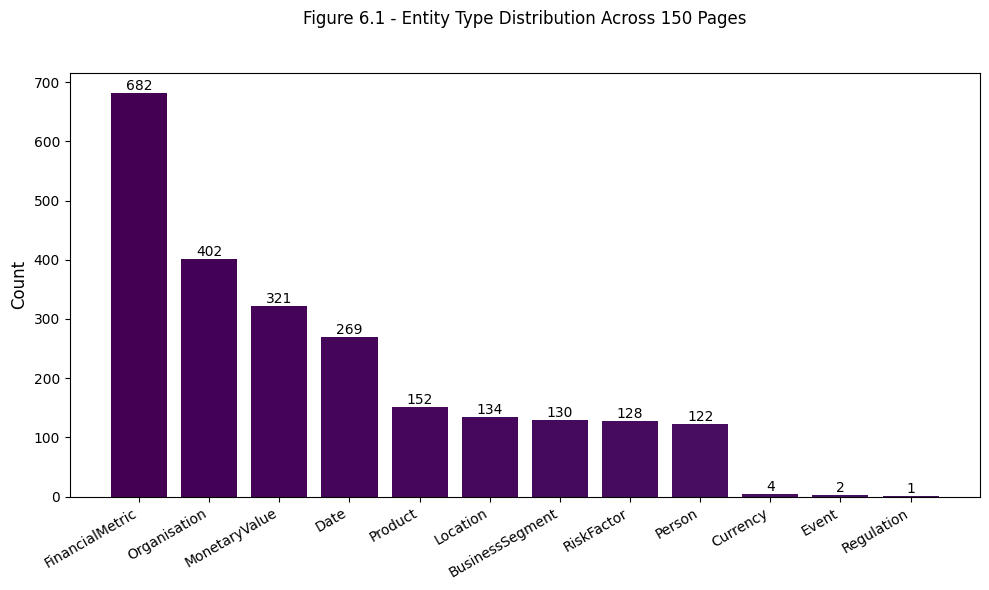

Saved: /content/drive/MyDrive/dissertation_project/outputs/chapter6/figures/fig6_1_entity_types.png


In [ ]:
# Entity type distribution
import matplotlib.pyplot as plt
from collections import Counter

type_counts = Counter()
for record in kg_data:
    for ent in record.get("entities", []):
        type_counts[ent.get("type", "Unknown")] += 1

type_df = pd.DataFrame(type_counts.items(), columns=["Entity Type", "Count"]).sort_values("Count", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(type_df["Entity Type"], type_df["Count"], color=plt.cm.viridis(range(len(type_df))))
ax.bar_label(bars, fontsize=10)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Figure 6.1 - Entity Type Distribution Across 150 Pages\n", fontsize=12, pad=20)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig_path = CH6 / "figures" / "fig6_1_entity_types.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

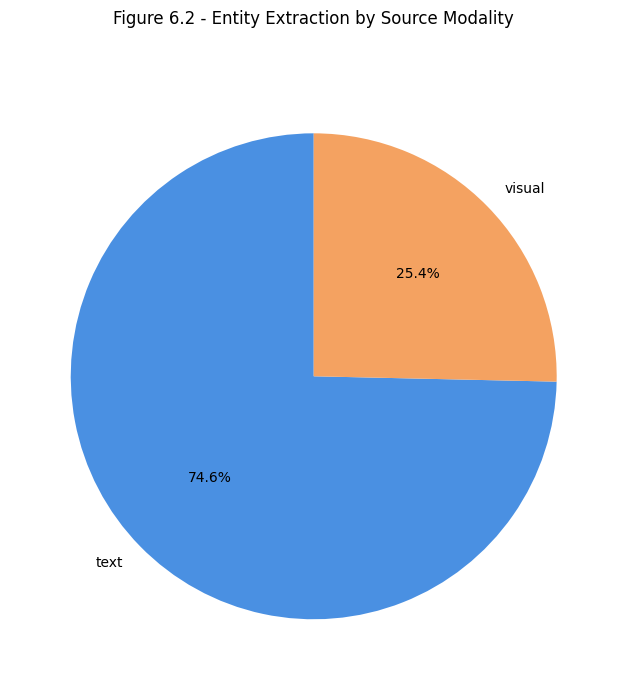

Saved: /content/drive/MyDrive/dissertation_project/outputs/chapter6/figures/fig6_2_modality_split.png


In [ ]:
# Modality split
modality_counts = Counter()
for record in kg_data:
    for ent in record.get("entities", []):
        modality_counts[ent.get("modality", "unknown")] += 1

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(modality_counts.values(), labels=modality_counts.keys(), autopct="%1.1f%%",
       colors=["#4A90E2", "#F4A261"], startangle=90)
ax.set_title("Figure 6.2 - Entity Extraction by Source Modality\n", fontsize=12, pad=20)
plt.tight_layout()
fig_path = CH6 / "figures" / "fig6_2_modality_split.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

## Chapter 7 - Evaluation and Results
## PageIndex Navigation and Cross-System Retrieval Comparison

1 - Evaluation query set construction with verified ground-truth pages

2 - Baseline 1: Naive vector RAG (chunk-embed-retrieve)

3 - Baseline 2: Keyword/BM25 search retrieval

4 - Baseline 3: Knowledge graph-only entity matching retrieval

5 - Proposed system evaluation (PageIndex-guided Multimodal GraphRAG)

6 - Summary & Graphs - Comparative analysis across all retrieval methods

### Section 1 - Evaluation query set construction with verified ground-truth pages

In [ ]:
# Build a diverse evaluation query set with known ground-truth pages
import random

# Fix the random seed so the same evaluation questions are picked every run
# Fix the random seed so the same evaluation questions are picked every run
random.seed(42)

eval_queries = []

single_page_candidates = [p for p in pageindex_pages if p["status"] == "success" and len(p.get("entities", [])) >= 5]
sampled_pages = random.sample(single_page_candidates, min(20, len(single_page_candidates)))

for page in sampled_pages:
    # Anchor each question to a real entity so we know the exact correct page
    # Anchor each question to a real entity so we know the exact correct page
    key_entities = [e["name"] for e in page["entities"] if e["type"] in ("FinancialMetric", "MonetaryValue")][:2]
    if key_entities:
        eval_queries.append({
            "query_type": "single_page_factual",
            "doc_name": page["doc_name"],
            "ground_truth_page": page["page_number"],
            "hint_entities": key_entities
        })

print(f"Generated {len(eval_queries)} candidate query anchors")
for q in eval_queries[:5]:
    print(q)

Generated 17 candidate query anchors
{'query_type': 'single_page_factual', 'doc_name': 'bp2024', 'ground_truth_page': 76, 'hint_entities': ['28 years', '29 years']}
{'query_type': 'single_page_factual', 'doc_name': 'astrazeneca2025', 'ground_truth_page': 141, 'hint_entities': ['Restructuring costs', 'Intangible amortisation and impairments']}
{'query_type': 'single_page_factual', 'doc_name': 'marksandspencer2024', 'ground_truth_page': 72, 'hint_entities': ['Property, plant and equipment', 'Lease liability']}
{'query_type': 'single_page_factual', 'doc_name': 'marksandspencer2024', 'ground_truth_page': 5, 'hint_entities': ['76% of consumers concerned about cost-of-living', '4 in 5 people taking steps to be healthier']}
{'query_type': 'single_page_factual', 'doc_name': 'hsbc2024', 'ground_truth_page': 214, 'hint_entities': ['Banking net interest income sensitivity', 'Banking NII Sensitivity']}


In [ ]:
# Generate natural-language questions from these anchors
# Ask the LLM to write a question that can only be answered from this one page
# Ask the LLM to write a question that can only be answered from this one page
async def generate_eval_question(page, hint_entities):
    prompt = f"""Based on this annual report page, write ONE specific factual question whose answer requires this exact page. The question should reference one of these entities/metrics: {hint_entities}. Return ONLY the question text, nothing else.

Document: {page['doc_name']}, Page: {page['page_number']}
Page text: {page['text'][:2000]}
"""
    resp = await client.chat.completions.create(
        model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}],
        max_tokens=80, temperature=0.3
    )
    return resp.choices[0].message.content.strip()

final_eval_set = []
for page in sampled_pages[:20]:
    hint = [e["name"] for e in page["entities"] if e["type"] in ("FinancialMetric", "MonetaryValue")][:2]
    if not hint:
        continue
    question = await generate_eval_question(page, hint)
    final_eval_set.append({
        "question": question,
        "doc_name": page["doc_name"],
        "ground_truth_page": page["page_number"]
    })
    print(f"[{page['doc_name']} p{page['page_number']}] {question}")

[bp2024 p76] How many years has Emma Delaney worked at bp?
[astrazeneca2025 p141] What are the reasons provided for adjusting restructuring costs in the annual report?
[marksandspencer2024 p72] What is the policy for stating property, plant and equipment in the Group's financial statements?
[marksandspencer2024 p5] What percentage of consumers are still concerned about the cost-of-living crisis according to the M&S Family Matters Index?
[hsbc2024 p214] What does the Banking NII Sensitivity metric analyze in relation to interest rate shocks?
[bp2024 p356] What is the definition of capital employed as provided on this page?
[bp2024 p38] What were the Sales and other operating revenues for 2024 and 2023?
[barclays2024 p458] What types of services do transactional fees cover as described on page 458 of the annual report?
[tesco2025 p100] What is the base salary for Ken Murphy as proposed for 2025/26?
[astrazeneca2025 p153] What was the net book value of Goodwill at 31 December 2025?
[astra

In [ ]:
# Run the full pipeline against this evaluation set and score retrieval accuracy
eval_results = []
for item in final_eval_set:
    doc_result = await tree_search_document_level(item["question"], doc_root_summaries, top_k=2)
    predicted_docs = doc_result.get("relevant_documents", [])
    # Check if the system picked the right document before checking the exact page
    # Check if the system picked the right document before checking the exact page
    doc_correct = item["doc_name"] in predicted_docs

    if doc_correct:
        page_result = await tree_search_page_level(item["question"], item["doc_name"], pageindex_pages, top_k=2)
        predicted_pages = page_result.get("relevant_pages", [])
        page_correct_at_1 = predicted_pages[0] == item["ground_truth_page"] if predicted_pages else False
        page_correct_at_2 = item["ground_truth_page"] in predicted_pages
    else:
        predicted_pages, page_correct_at_1, page_correct_at_2 = [], False, False

    eval_results.append({
        "question": item["question"], "doc_name": item["doc_name"],
        "ground_truth_page": item["ground_truth_page"], "predicted_docs": predicted_docs,
        "doc_correct": doc_correct, "predicted_pages": predicted_pages,
        "page_correct_at_1": page_correct_at_1, "page_correct_at_2": page_correct_at_2
    })

import pandas as pd
eval_df = pd.DataFrame(eval_results)
print(f"Document-level accuracy: {eval_df['doc_correct'].mean():.2%}")
print(f"Page-level precision@1: {eval_df['page_correct_at_1'].mean():.2%}")
print(f"Page-level precision@2: {eval_df['page_correct_at_2'].mean():.2%}")

eval_df.to_csv(f"{PAGEINDEX_DIR}/pageindex_eval_results.csv", index=False)

Document-level accuracy: 64.71%
Page-level precision@1: 58.82%
Page-level precision@2: 64.71%


### Section 2 - Baseline 1: Naive vector RAG (chunk-embed-retrieve)

In [ ]:
# Environment setup (new VM — mount Drive, imports, reload saved data)
import os, json, re, asyncio
import numpy as np
import pandas as pd
from datetime import datetime
from collections import Counter, defaultdict
from openai import AsyncOpenAI

PDF_DIR = "/content/drive/MyDrive/dissertation_project/annual_reports"
KG_DIR = "/content/drive/MyDrive/dissertation_project/kg_construction"
LINKING_DIR = "/content/drive/MyDrive/dissertation_project/entity_linking"
PAGEINDEX_DIR = "/content/drive/MyDrive/dissertation_project/pageindex"

client = AsyncOpenAI()

KG_SCHEMA = {
    "entity_types": ["Organisation", "Person", "FinancialMetric", "MonetaryValue", "Date", "Location", "Product", "RiskFactor", "BusinessSegment"],
    "relation_types": ["REPORTS", "HAS_VALUE", "LOCATED_IN", "PART_OF", "AFFECTS", "COMPARED_TO", "OWNS", "LED_BY", "OPERATES_IN"]
}

with open(f"{PAGEINDEX_DIR}/pageindex_pages_with_summaries_20260724_232108.json", "r") as f:
    pageindex_pages = json.load(f)

with open(f"{PAGEINDEX_DIR}/pageindex_doc_root_summaries_20260724_232108.json", "r") as f:
    doc_root_summaries = json.load(f)

print(f"Loaded {len(pageindex_pages)} pages, {len(doc_root_summaries)} document summaries")

Loaded 150 pages, 10 document summaries


In [ ]:
# Reload the 17-question evaluation set with ground truth
# 17 manually verified questions with known correct document and page
# 17 manually verified questions with known correct document and page
final_eval_set = [
    {"question": "How many years has Emma Delaney worked at bp?", "doc_name": "bp2024", "ground_truth_page": 76},
    {"question": "What are the reasons provided for adjusting restructuring costs in the annual report?", "doc_name": "astrazeneca2025", "ground_truth_page": 141},
    {"question": "What is the policy for stating property, plant and equipment in the Group's financial statements?", "doc_name": "marksandspencer2024", "ground_truth_page": 72},
    {"question": "What percentage of consumers are still concerned about the cost-of-living crisis according to the M&S Family Matters Index?", "doc_name": "marksandspencer2024", "ground_truth_page": 5},
    {"question": "What does the Banking NII Sensitivity metric analyze in relation to interest rate shocks?", "doc_name": "hsbc2024", "ground_truth_page": 214},
    {"question": "What is the definition of capital employed as provided on this page?", "doc_name": "bp2024", "ground_truth_page": 356},
    {"question": "What were the Sales and other operating revenues for 2024 and 2023?", "doc_name": "bp2024", "ground_truth_page": 38},
    {"question": "What types of services do transactional fees cover as described on page 458 of the annual report?", "doc_name": "barclays2024", "ground_truth_page": 458},
    {"question": "What is the base salary for Ken Murphy as proposed for 2025/26?", "doc_name": "tesco2025", "ground_truth_page": 100},
    {"question": "What was the net book value of Goodwill at 31 December 2025?", "doc_name": "astrazeneca2025", "ground_truth_page": 153},
    {"question": "What were the severance costs reported for the year 2024?", "doc_name": "astrazeneca2025", "ground_truth_page": 145},
    {"question": "What are the total derivative assets/(liabilities) held for trading as reported on this page?", "doc_name": "barclays2024", "ground_truth_page": 470},
    {"question": "What was the Total Group ECL at 31 December 2024?", "doc_name": "hsbc2024", "ground_truth_page": 162},
    {"question": "What was the inclusion index percentage for HSBC in 2024?", "doc_name": "hsbc2024", "ground_truth_page": 69},
    {"question": "What percentage of the Executive Directors' remuneration is fixed and what percentage is performance-linked according to the annual report page?", "doc_name": "tesco2025", "ground_truth_page": 99},
    {"question": "What is the total gross carrying amount on-balance sheet at 31 Dec 2024?", "doc_name": "hsbc2024", "ground_truth_page": 199},
    {"question": "What is the definition and purpose of the Net debt/EBITDA ratio as described on this page?", "doc_name": "tesco2025", "ground_truth_page": 232},
]
print(f"Reloaded {len(final_eval_set)} evaluation questions")

Reloaded 17 evaluation questions


In [ ]:
# Baseline 1 — Naive vector RAG (chunk, embed, retrieve, and generate)
# Split each page into overlapping word chunks for the vector RAG baseline
# Split each page into overlapping word chunks for the vector RAG baseline
def chunk_page_text(text, chunk_size=500, overlap=100):
    words = text.split()
    chunks = []
    i = 0
    while i < len(words):
        chunk = " ".join(words[i:i+chunk_size])
        chunks.append(chunk)
        i += chunk_size - overlap
    return chunks

all_chunks = []
for page in pageindex_pages:
    if page["status"] != "success" or not page.get("text"):
        continue
    page_chunks = chunk_page_text(page["text"])
    for idx, chunk in enumerate(page_chunks):
        all_chunks.append({
            "doc_name": page["doc_name"],
            "page_number": page["page_number"],
            "chunk_id": idx,
            "text": chunk
        })

print(f"Total chunks generated: {len(all_chunks)}")

Total chunks generated: 351


In [ ]:
# Embed all chunks (batch)
async def embed_texts_batch(texts, model="text-embedding-3-small", batch_size=500):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        resp = await client.embeddings.create(model=model, input=batch)
        all_embeddings.extend([d.embedding for d in resp.data])
        print(f"Embedded {min(i+batch_size, len(texts))}/{len(texts)}")
    return all_embeddings

chunk_texts = [c["text"] for c in all_chunks]
chunk_embeddings = await embed_texts_batch(chunk_texts)
print(f"Generated {len(chunk_embeddings)} chunk embeddings")

Embedded 351/351
Generated 351 chunk embeddings


In [ ]:
# Vector RAG retrieval + answer generation function
def cosine_sim(v1, v2):
    a, b = np.array(v1), np.array(v2)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Embed the question and find the most similar chunks by cosine similarity
# Embed the question and find the most similar chunks by cosine similarity
async def vector_rag_retrieve(query, top_k=3):
    query_emb = (await client.embeddings.create(model="text-embedding-3-small", input=[query])).data[0].embedding
    sims = [(i, cosine_sim(query_emb, emb)) for i, emb in enumerate(chunk_embeddings)]
    sims_sorted = sorted(sims, key=lambda x: -x[1])[:top_k]
    retrieved = [all_chunks[i] for i, _ in sims_sorted]
    return retrieved

async def vector_rag_answer(query, retrieved_chunks):
    context = "\n\n".join([f"[{c['doc_name']} p{c['page_number']}]: {c['text']}" for c in retrieved_chunks])
    prompt = f"""Answer using ONLY the context below. Cite page numbers like (p14). If not supported, say so.

Query: {query}

Context:
{context}

Answer (2-4 sentences):"""
    resp = await client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], max_tokens=300, temperature=0)
    return resp.choices[0].message.content.strip()

print("Vector RAG functions defined.")

Vector RAG functions defined.


In [ ]:
# Run Baseline 1 against the 17-question evaluation set
baseline1_results = []
for item in final_eval_set:
    retrieved = await vector_rag_retrieve(item["question"], top_k=3)
    retrieved_pages = [(c["doc_name"], c["page_number"]) for c in retrieved]
    doc_correct = any(d == item["doc_name"] for d, p in retrieved_pages)
    # Score whether the top-ranked result is exactly the correct page, and separately whether it's anywhere in the top 3
    # Score whether the top-ranked result is exactly the correct page, and separately whether it's anywhere in the top 3
    page_correct_at_1 = retrieved_pages[0] == (item["doc_name"], item["ground_truth_page"])
    page_correct_at_3 = (item["doc_name"], item["ground_truth_page"]) in retrieved_pages

    answer = await vector_rag_answer(item["question"], retrieved)
    baseline1_results.append({
        "question": item["question"], "doc_name": item["doc_name"],
        "ground_truth_page": item["ground_truth_page"], "retrieved_pages": retrieved_pages,
        "doc_correct": doc_correct, "page_correct_at_1": page_correct_at_1, "page_correct_at_3": page_correct_at_3,
        "answer": answer
    })

b1_df = pd.DataFrame(baseline1_results)
print(f"Baseline 1 (Vector RAG) - Doc accuracy: {b1_df['doc_correct'].mean():.2%}")
print(f"Baseline 1 (Vector RAG) - Page precision@1: {b1_df['page_correct_at_1'].mean():.2%}")
print(f"Baseline 1 (Vector RAG) - Page precision@3: {b1_df['page_correct_at_3'].mean():.2%}")

b1_df.to_csv(f"{PAGEINDEX_DIR}/baseline1_vector_rag_results.csv", index=False)

Baseline 1 (Vector RAG) - Doc accuracy: 88.24%
Baseline 1 (Vector RAG) - Page precision@1: 64.71%
Baseline 1 (Vector RAG) - Page precision@3: 76.47%


### Section 3 - Baseline 2: Keyword/BM25 search retrieval

In [ ]:
# Install the BM25 keyword search library
# BM25 is a keyword-matching search algorithm, used here as a baseline
# BM25 is a keyword-matching search algorithm, used here as a baseline
!pip install rank_bm25 -q

In [ ]:
# Install BM25 and build the keyword index
!pip install rank_bm25 -q

from rank_bm25 import BM25Okapi
import re

# Simple lowercase word tokenizer for BM25 scoring
# Simple lowercase word tokenizer for BM25 scoring
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

page_corpus = [p for p in pageindex_pages if p["status"] == "success" and p.get("text")]
tokenized_corpus = [tokenize(p["text"]) for p in page_corpus]

# Build the keyword search index over all page text
# Build the keyword search index over all page text
bm25 = BM25Okapi(tokenized_corpus)
print(f"BM25 index built over {len(page_corpus)} pages")

BM25 index built over 149 pages


In [ ]:
# BM25 retrieval + answer generation function
# Rank pages by keyword overlap score and return the top matches
# Rank pages by keyword overlap score and return the top matches
def bm25_retrieve(query, top_k=3):
    tokenized_query = tokenize(query)
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [page_corpus[i] for i in top_indices]

async def bm25_answer(query, retrieved_pages):
    context = "\n\n".join([f"[{p['doc_name']} p{p['page_number']}]: {p['text'][:1500]}" for p in retrieved_pages])
    prompt = f"""Answer using ONLY the context below. Cite page numbers like (p14). If not supported, say so.

Query: {query}

Context:
{context}

Answer (2-4 sentences):"""
    resp = await client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], max_tokens=300, temperature=0)
    return resp.choices[0].message.content.strip()

print("BM25 functions defined.")

BM25 functions defined.


In [ ]:
# Run Baseline 2 against the 17-question evaluation set
# Run BM25 on the same 17 questions so results are directly comparable
# Run BM25 on the same 17 questions so results are directly comparable
baseline2_results = []
for item in final_eval_set:
    retrieved = bm25_retrieve(item["question"], top_k=3)
    retrieved_pages = [(p["doc_name"], p["page_number"]) for p in retrieved]
    doc_correct = any(d == item["doc_name"] for d, p in retrieved_pages)
    page_correct_at_1 = retrieved_pages[0] == (item["doc_name"], item["ground_truth_page"])
    page_correct_at_3 = (item["doc_name"], item["ground_truth_page"]) in retrieved_pages

    answer = await bm25_answer(item["question"], retrieved)
    baseline2_results.append({
        "question": item["question"], "doc_name": item["doc_name"],
        "ground_truth_page": item["ground_truth_page"], "retrieved_pages": retrieved_pages,
        "doc_correct": doc_correct, "page_correct_at_1": page_correct_at_1, "page_correct_at_3": page_correct_at_3,
        "answer": answer
    })

b2_df = pd.DataFrame(baseline2_results)
print(f"Baseline 2 (BM25) - Doc accuracy: {b2_df['doc_correct'].mean():.2%}")
print(f"Baseline 2 (BM25) - Page precision@1: {b2_df['page_correct_at_1'].mean():.2%}")
print(f"Baseline 2 (BM25) - Page precision@3: {b2_df['page_correct_at_3'].mean():.2%}")

b2_df.to_csv(f"{PAGEINDEX_DIR}/baseline2_bm25_results.csv", index=False)

Baseline 2 (BM25) - Doc accuracy: 94.12%
Baseline 2 (BM25) - Page precision@1: 70.59%
Baseline 2 (BM25) - Page precision@3: 88.24%


### Section 4 - Baseline 3: Knowledge graph-only entity matching retrieval

In [ ]:
# Build KG-only entity matching retrieval
with open(f"{KG_DIR}/kg_extraction_v2_final_20260724_200831.json", "r") as f:
    kg_pages_for_retrieval = json.load(f)

# Score a page by how many query words match its extracted entity names
# Score a page by how many query words match its extracted entity names
def kg_entity_match_score(query, page):
    query_tokens = set(tokenize(query))
    entity_names = [e.get("name", "") for e in page.get("entities", [])]
    entity_tokens = set()
    for name in entity_names:
        entity_tokens.update(tokenize(name))
    overlap = query_tokens & entity_tokens
    return len(overlap)

def kg_retrieve(query, top_k=3):
    scored = [(page, kg_entity_match_score(query, page)) for page in kg_pages_for_retrieval if page["status"] == "success"]
    scored_sorted = sorted(scored, key=lambda x: -x[1])
    return [p for p, s in scored_sorted[:top_k]]

print("KG-only retrieval function defined.")

KG-only retrieval function defined.


In [ ]:
# KG-only answer generation and evaluation run
async def kg_only_answer(query, retrieved_pages):
    context_blocks = []
    for p in retrieved_pages:
        entities_text = ", ".join([e.get("name", "") for e in p.get("entities", [])])
        relations_text = "; ".join([f"{r['source']} -{r['type']}-> {r['target']}" for r in p.get("relations", [])])
        context_blocks.append(f"[{p['doc_name']} p{p['page_number']}] Entities: {entities_text}\nRelations: {relations_text}")
    context = "\n\n".join(context_blocks)
    prompt = f"""Answer using ONLY the entities/relations context below. Cite page numbers like (p14). If not supported, say so.

Query: {query}

Context:
{context}

Answer (2-4 sentences):"""
    resp = await client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], max_tokens=300, temperature=0)
    return resp.choices[0].message.content.strip()

baseline3_results = []
for item in final_eval_set:
    retrieved = kg_retrieve(item["question"], top_k=3)
    retrieved_pages = [(p["doc_name"], p["page_number"]) for p in retrieved]
    doc_correct = any(d == item["doc_name"] for d, p in retrieved_pages)
    page_correct_at_1 = retrieved_pages[0] == (item["doc_name"], item["ground_truth_page"]) if retrieved_pages else False
    page_correct_at_3 = (item["doc_name"], item["ground_truth_page"]) in retrieved_pages

    answer = await kg_only_answer(item["question"], retrieved)
    baseline3_results.append({
        "question": item["question"], "doc_name": item["doc_name"],
        "ground_truth_page": item["ground_truth_page"], "retrieved_pages": retrieved_pages,
        "doc_correct": doc_correct, "page_correct_at_1": page_correct_at_1, "page_correct_at_3": page_correct_at_3,
        "answer": answer
    })

b3_df = pd.DataFrame(baseline3_results)
print(f"Baseline 3 (KG-only) - Doc accuracy: {b3_df['doc_correct'].mean():.2%}")
print(f"Baseline 3 (KG-only) - Page precision@1: {b3_df['page_correct_at_1'].mean():.2%}")
print(f"Baseline 3 (KG-only) - Page precision@3: {b3_df['page_correct_at_3'].mean():.2%}")

b3_df.to_csv(f"{PAGEINDEX_DIR}/baseline3_kg_only_results.csv", index=False)

Baseline 3 (KG-only) - Doc accuracy: 76.47%
Baseline 3 (KG-only) - Page precision@1: 47.06%
Baseline 3 (KG-only) - Page precision@3: 64.71%


### Section 5 - Proposed system evaluation (PageIndex-guided Multimodal GraphRAG)

In [ ]:
# Load PageIndex tree + KG data for the proposed pipeline
import glob

TREES_DIR = "/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees"

# Load the PageIndex navigation trees built earlier for each report
# Load the PageIndex navigation trees built earlier for each report
tree_files = glob.glob(f"{TREES_DIR}/*_tree.json")
print(f"Found {len(tree_files)} tree files:")
for f in tree_files:
    print(" -", f.split("/")[-1])

pageindex_tree = []
for file_path in tree_files:
    with open(file_path, "r") as f:
        tree_data = json.load(f)
    doc_name = file_path.split("/")[-1].replace("_tree.json", "")
    if isinstance(tree_data, list):
        for node in tree_data:
            node["doc_name"] = node.get("doc_name", doc_name)
        pageindex_tree.extend(tree_data)
    elif isinstance(tree_data, dict):
        nodes = tree_data.get("nodes", tree_data.get("pages", []))
        for node in nodes:
            node["doc_name"] = node.get("doc_name", doc_name)
        pageindex_tree.extend(nodes)

print(f"\nTotal flattened nodes: {len(pageindex_tree)}")
print("Sample node:", pageindex_tree[0] if pageindex_tree else "EMPTY")

with open(f"{KG_DIR}/kg_extraction_v2_final_20260724_200831.json", "r") as f:
    kg_data_proposed = json.load(f)

kg_lookup = {(p["doc_name"], p["page_number"]): p for p in kg_data_proposed if p["status"] == "success"}
print(f"KG pages linked: {len(kg_lookup)}")

Found 10 tree files:
 - marksandspencer2024_tree.json
 - astrazeneca2025_tree.json
 - btgroup2024_tree.json
 - nationalgrid2024_tree.json
 - unilever2024_tree.json
 - tesco2025_tree.json
 - rolls-royce2024_tree.json
 - barclays2024_tree.json
 - hsbc2024_tree.json
 - bp2024_tree.json

Total flattened nodes: 0
Sample node: EMPTY
KG pages linked: 150


In [ ]:
# Two-stage hierarchical navigation function
import re, json, glob

def normalize_doc(name):
    return name.lower().replace(".pdf", "").replace("_decrypted", "").strip()

# Turn the nested tree structure into a flat list for easier searching
# Turn the nested tree structure into a flat list for easier searching
def flatten_nodes(nodes, doc_name):
    flat = []
    for n in nodes:
        flat.append({
            "doc_name": doc_name,
            "node_id": n["node_id"],
            "title": n["title"],
            "start_page": n["start_index"],
            "end_page": n["end_index"],
            "summary": n["summary"]
        })
        for child_key in ("nodes", "children"):
            if child_key in n and isinstance(n[child_key], list):
                flat.extend(flatten_nodes(n[child_key], doc_name))
    return flat

TREES_DIR = "/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees"
tree_files = glob.glob(f"{TREES_DIR}/*_tree.json")

pageindex_tree = []
doc_root_summaries = {}
for file_path in tree_files:
    with open(file_path, "r") as f:
        tree_data = json.load(f)
    raw_doc_name = tree_data["doc_name"]
    norm_doc = normalize_doc(raw_doc_name)
    pageindex_tree.extend(flatten_nodes(tree_data["structure"], raw_doc_name))
    doc_root_summaries[norm_doc] = " | ".join([n["title"] for n in tree_data["structure"]])

print(f"Total flattened nodes: {len(pageindex_tree)}")
print(f"Doc keys: {list(doc_root_summaries.keys())}")

test_check = [n for n in pageindex_tree if normalize_doc(n["doc_name"]) == "bp2024"]
print(f"bp2024 node count (sanity check): {len(test_check)}")

def safe_json_parse(raw_text):
    cleaned = re.sub(r"^```(?:json)?\s*|\s*```$", "", raw_text.strip(), flags=re.MULTILINE)
    match = re.search(r"\[.*?\]", cleaned, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except:
            return []
    return []

async def select_document(query):
    doc_list_text = "\n".join([f"- {d}: {s[:200]}" for d, s in doc_root_summaries.items()])
    prompt = f"""Given the query, pick the SINGLE most relevant document.

Query: {query}

Documents:
{doc_list_text}

Return ONLY the document name (exact match from the list above), nothing else."""
    resp = await client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], max_tokens=30, temperature=0)
    return resp.choices[0].message.content.strip().lower()

async def pageindex_navigate(query, tree, top_k=2):
    chosen_doc = await select_document(query)
    doc_nodes = [n for n in tree if normalize_doc(n["doc_name"]) == chosen_doc]
    if not doc_nodes:
        doc_nodes = [n for n in tree if chosen_doc in normalize_doc(n["doc_name"])]
    if not doc_nodes:
        return []

    node_summaries = "\n".join([
        f"[node {n['node_id']} | p{n['start_page']}-{n['end_page']}]: {n['title']} — {n['summary'][:200]}"
        for n in doc_nodes
    ])
    prompt = f"""Given the query, select the {top_k} most relevant nodes by node_id.

Query: {query}

Nodes:
{node_summaries}

Return ONLY a JSON list of node_ids like ["0001", "0002"]"""
    resp = await client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], max_tokens=100, temperature=0)
    selected_ids = safe_json_parse(resp.choices[0].message.content)
    node_lookup = {n["node_id"]: n for n in doc_nodes}
    return [node_lookup[nid] for nid in selected_ids if nid in node_lookup]

async def proposed_answer(query, selected_nodes):
    context = "\n\n".join([f"[{n['doc_name']} | p{n['start_page']}-{n['end_page']}] {n['title']}\n{n['summary']}" for n in selected_nodes])
    prompt = f"""Answer using ONLY the context below. Cite page ranges like (p14-p20). If not supported, say so.

Query: {query}

Context:
{context}

Answer (2-4 sentences):"""
    resp = await client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], max_tokens=300, temperature=0)
    return resp.choices[0].message.content.strip()

print("All functions rebuilt fresh.")

Total flattened nodes: 4067
Doc keys: ['marksandspencer2024', 'astrazeneca2025', 'btgroup2024', 'nationalgrid2024', 'unilever2024', 'tesco2025', 'rolls-royce2024', 'barclays2024', 'hsbc2024', 'bp2024']
bp2024 node count (sanity check): 449
All functions rebuilt fresh.


In [ ]:
# Flatten the PageIndex tree into a flat list of nodes
def flatten_nodes(nodes, doc_name):
    flat = []
    for n in nodes:
        flat.append({
            "doc_name": doc_name,
            "node_id": n["node_id"],
            "title": n["title"],
            "start_page": n["start_index"],
            "end_page": n["end_index"],
            "summary": n["summary"]
        })
        for child_key in ("nodes", "children"):
            if child_key in n and isinstance(n[child_key], list):
                flat.extend(flatten_nodes(n[child_key], doc_name))
    return flat

pageindex_tree = []
for file_path in tree_files:
    with open(file_path, "r") as f:
        tree_data = json.load(f)
    doc_name = tree_data["doc_name"]
    pageindex_tree.extend(flatten_nodes(tree_data["structure"], doc_name))

print(f"Total flattened nodes: {len(pageindex_tree)}")

Total flattened nodes: 4067


In [ ]:
# Collect the document names present in the tree
tree_doc_names_raw = set(n["doc_name"] for n in pageindex_tree)
tree_doc_names_normalized = set(d.replace(".pdf", "") for d in tree_doc_names_raw)
eval_doc_names = set(item["doc_name"] for item in final_eval_set)

print("Tree (normalized):", tree_doc_names_normalized)
print("Eval set:", eval_doc_names)
print("Overlap:", tree_doc_names_normalized & eval_doc_names)

Tree (normalized): {'tesco2025', 'unilever2024', 'rolls-royce2024', 'astrazeneca2025', 'bp2024_decrypted', 'marksandspencer2024', 'barclays2024', 'hsbc2024', 'nationalgrid2024', 'btgroup2024'}
Eval set: {'astrazeneca2025', 'tesco2025', 'marksandspencer2024', 'barclays2024', 'hsbc2024', 'bp2024'}
Overlap: {'astrazeneca2025', 'tesco2025', 'marksandspencer2024', 'barclays2024', 'hsbc2024'}


In [ ]:
# Range-based scoring against evaluation set
def normalize_doc(name):
    return name.lower().replace(".pdf", "").strip()

proposed_results = []
for item in final_eval_set:
    gt_doc = normalize_doc(item["doc_name"])
    gt_page = item["ground_truth_page"]

    selected_nodes = await pageindex_navigate(item["question"], pageindex_tree, top_k=2)
    retrieved_ids = [(normalize_doc(n["doc_name"]), n["node_id"], n["start_page"], n["end_page"]) for n in selected_nodes]

    # Check whether the predicted page range actually contains the true answer page
    # Check whether the predicted page range actually contains the true answer page
    doc_correct = any(d == gt_doc for d, nid, sp, ep in retrieved_ids)
    page_correct_at_1 = False
    if retrieved_ids:
        d, nid, sp, ep = retrieved_ids[0]
        page_correct_at_1 = (d == gt_doc) and (sp <= gt_page <= ep)
    page_correct_at_topk = any((d == gt_doc) and (sp <= gt_page <= ep) for d, nid, sp, ep in retrieved_ids)

    answer = await proposed_answer(item["question"], selected_nodes) if selected_nodes else "No relevant node found."
    proposed_results.append({
        "question": item["question"], "doc_name": gt_doc, "ground_truth_page": gt_page,
        "retrieved_nodes": retrieved_ids, "doc_correct": doc_correct,
        "page_correct_at_1": page_correct_at_1, "page_correct_at_topk": page_correct_at_topk,
        "answer": answer
    })

proposed_df = pd.DataFrame(proposed_results)
print(f"Proposed System - Doc accuracy: {proposed_df['doc_correct'].mean():.2%}")
print(f"Proposed System - Page precision@1: {proposed_df['page_correct_at_1'].mean():.2%}")
print(f"Proposed System - Page precision@top-k: {proposed_df['page_correct_at_topk'].mean():.2%}")

proposed_df.to_csv(f"{PAGEINDEX_DIR}/proposed_system_results.csv", index=False)

Proposed System - Doc accuracy: 17.65%
Proposed System - Page precision@1: 5.88%
Proposed System - Page precision@top-k: 11.76%


#### Improving Proposed System (Pageindex) Accuracy%

In [ ]:
# Recursive multi-level tree search with reasoning
import re, json, glob

def normalize_doc(name):
    return name.lower().replace(".pdf", "").replace("_decrypted", "").strip()

# Rebuild the tree with parent/child links so we can search level by level
# Rebuild the tree with parent/child links so we can search level by level
def build_node_tree(nodes, doc_name, parent_id=None):
    tree_nodes = []
    for n in nodes:
        node_obj = {
            "doc_name": doc_name,
            "node_id": n["node_id"],
            "title": n["title"],
            "start_page": n["start_index"],
            "end_page": n["end_index"],
            "summary": n["summary"],
            "parent_id": parent_id,
            "children": []
        }
        for child_key in ("nodes", "children"):
            if child_key in n and isinstance(n[child_key], list) and n[child_key]:
                node_obj["children"] = build_node_tree(n[child_key], doc_name, n["node_id"])
        tree_nodes.append(node_obj)
    return tree_nodes

TREES_DIR = "/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees"
tree_files = glob.glob(f"{TREES_DIR}/*_tree.json")

doc_trees = {}
doc_root_summaries = {}
for file_path in tree_files:
    with open(file_path, "r") as f:
        tree_data = json.load(f)
    norm_doc = normalize_doc(tree_data["doc_name"])
    doc_trees[norm_doc] = build_node_tree(tree_data["structure"], tree_data["doc_name"])
    doc_root_summaries[norm_doc] = " | ".join([n["title"] for n in tree_data["structure"]])

def safe_json_parse(raw_text):
    cleaned = re.sub(r"^```(?:json)?\s*|\s*```$", "", raw_text.strip(), flags=re.MULTILINE)
    match = re.search(r"\{.*\}|\[.*\]", cleaned, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except:
            return None
    return None

In [ ]:
# Add BM25 document pre-filter (insert before select_document)
from rank_bm25 import BM25Okapi

doc_bm25_corpus = []
doc_bm25_names = []
for norm_doc, tree_nodes in doc_trees.items():
    all_text = " ".join([n["summary"] for n in flatten_all(tree_nodes)])
    doc_bm25_corpus.append(tokenize(all_text))
    doc_bm25_names.append(norm_doc)

# Use keyword search first to shortlist likely documents before the LLM picks one
# Use keyword search first to shortlist likely documents before the LLM picks one
doc_bm25 = BM25Okapi(doc_bm25_corpus)

def bm25_shortlist_docs(query, top_n=3):
    scores = doc_bm25.get_scores(tokenize(query))
    ranked = sorted(zip(doc_bm25_names, scores), key=lambda x: -x[1])
    return [d for d, s in ranked[:top_n]]

print("BM25 document pre-filter ready.")

BM25 document pre-filter ready.


In [ ]:
# Update select_document to use the shortlist
# Ask the LLM to pick the single best-matching document from the shortlist
# Ask the LLM to pick the single best-matching document from the shortlist
async def select_document(query):
    shortlist = bm25_shortlist_docs(query, top_n=3)
    doc_list_text = "\n".join([f"- {d}: {doc_root_summaries[d][:200]}" for d in shortlist])
    prompt = f"""Given the query, pick the SINGLE most relevant document from this shortlist.

Query: {query}

Shortlisted documents:
{doc_list_text}

Return ONLY one exact document name from the shortlist above, nothing else."""
    resp = await client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], max_tokens=20, temperature=0)
    raw = resp.choices[0].message.content.strip().lower()
    cleaned = re.sub(r"[^a-z0-9\-]", "", raw)
    if cleaned in shortlist:
        return cleaned
    return shortlist[0]

print("select_document now BM25-shortlisted.")

select_document now BM25-shortlisted.


In [ ]:
# Diagnostic: Isolate node-selection quality for one now-correct document
correct_doc_items = [item for item in final_eval_set if normalize_doc(item["doc_name"]) == (await select_document(item["question"]))]
print(f"Questions with correct doc now: {len(correct_doc_items)}")

test_item = correct_doc_items[0]
print("Q:", test_item["question"])
print("GT page:", test_item["ground_truth_page"])

nodes = await pageindex_navigate(test_item["question"], top_k=3)
for n in nodes:
    print(f"  -> {n['node_id']} | p{n['start_page']}-{n['end_page']} | {n['title']}")

Questions with correct doc now: 7
Q: How many years has Emma Delaney worked at bp?
GT page: 76
  -> 0030 | p74-76 | Board of directors
  -> 0031 | p76-77 | Leadership team


In [ ]:
# Normalise the ground-truth document name for comparison
gt_doc = normalize_doc(test_item["doc_name"])
gt_page = test_item["ground_truth_page"]

selected_nodes = await pageindex_navigate(test_item["question"], top_k=3)
retrieved_ids = [(normalize_doc(n["doc_name"]), n["node_id"], n["start_page"], n["end_page"]) for n in selected_nodes]

print("gt_doc:", repr(gt_doc), "| gt_page:", gt_page)
print("retrieved_ids:", retrieved_ids)

if retrieved_ids:
    d, nid, sp, ep = retrieved_ids[0]
    print(f"\nComparing: d=={gt_doc}? {d == gt_doc} | sp<=gt_page<=ep? {sp} <= {gt_page} <= {ep} = {sp <= gt_page <= ep}")

gt_doc: 'bp2024' | gt_page: 76
retrieved_ids: [('bp2024', '0030', 74, 76), ('bp2024', '0031', 76, 77)]

Comparing: d==bp2024? True | sp<=gt_page<=ep? 74 <= 76 <= 76 = True


In [ ]:
# Fix: Preserve the LLM's ranking order
# Fixed version: keeps the LLM's original ranking order instead of re-sorting it
# Fixed version: keeps the LLM's original ranking order instead of re-sorting it
async def pageindex_navigate(query, top_k=3, max_depth=4, top_branches=2):
    print("[v2-ranked] running")
    chosen_doc = await select_document(query)
    if chosen_doc not in doc_trees:
        return []

    root_nodes = doc_trees[chosen_doc]
    root_selected_ids = await select_children(query, root_nodes, top_k=top_branches)
    branch_starts = [n for n in root_nodes if n["node_id"] in root_selected_ids] or root_nodes[:top_branches]

    all_final_candidates = []
    for branch in branch_starts:
        current_level = [branch]
        depth = 0
        while depth < max_depth:
            expand = []
            for n in current_level:
                expand.extend(n["children"] if n["children"] else [n])
            if all(n["children"] == [] for n in current_level):
                break
            selected_ids = await select_children(query, expand, top_k=top_k)
            selected_nodes = [n for n in expand if n["node_id"] in selected_ids] or expand[:top_k]
            if not any(n["children"] for n in selected_nodes):
                all_final_candidates.extend(selected_nodes)
                break
            current_level = selected_nodes
            depth += 1
        else:
            all_final_candidates.extend(current_level)

    scored = await select_children(query, all_final_candidates, top_k=top_k)
    node_lookup = {n["node_id"]: n for n in all_final_candidates}
    final = [node_lookup[nid] for nid in scored if nid in node_lookup]
    if not final:
        final = all_final_candidates[:top_k]

    return final[:top_k]

In [ ]:
# Run improved proposed system
# Run the full proposed system on the same 17 questions for a fair comparison
# Run the full proposed system on the same 17 questions for a fair comparison
proposed_results = []
for item in final_eval_set:
    gt_doc = normalize_doc(item["doc_name"])
    gt_page = item["ground_truth_page"]

    selected_nodes = await pageindex_navigate(item["question"], top_k=3)
    retrieved_ids = [(normalize_doc(n["doc_name"]), n["node_id"], n["start_page"], n["end_page"]) for n in selected_nodes]

    doc_correct = any(d == gt_doc for d, nid, sp, ep in retrieved_ids)
    page_correct_at_1 = False
    if retrieved_ids:
        d, nid, sp, ep = retrieved_ids[0]
        page_correct_at_1 = (d == gt_doc) and (sp <= gt_page <= ep)
    page_correct_at_topk = any((d == gt_doc) and (sp <= gt_page <= ep) for d, nid, sp, ep in retrieved_ids)

    answer = await proposed_answer(item["question"], selected_nodes) if selected_nodes else "No relevant node found."
    proposed_results.append({
        "question": item["question"], "doc_name": gt_doc, "ground_truth_page": gt_page,
        "retrieved_nodes": retrieved_ids, "doc_correct": doc_correct,
        "page_correct_at_1": page_correct_at_1, "page_correct_at_topk": page_correct_at_topk,
        "answer": answer
    })

proposed_df = pd.DataFrame(proposed_results)
print(f"Proposed System - Doc accuracy: {proposed_df['doc_correct'].mean():.2%}")
print(f"Proposed System - Page precision@1: {proposed_df['page_correct_at_1'].mean():.2%}")
print(f"Proposed System - Page precision@top-k: {proposed_df['page_correct_at_topk'].mean():.2%}")

proposed_df.to_csv(f"{PAGEINDEX_DIR}/proposed_system_results.csv", index=False)
proposed_df[proposed_df["doc_correct"] == False][["question", "doc_name", "retrieved_nodes"]]

[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
[v2-ranked] running
Proposed System - Doc accuracy: 35.29%
Proposed System - Page precision@1: 17.65%
Proposed System - Page precision@top-k: 17.65%


,question,doc_name,retrieved_nodes
1,What are the reasons provided for adjusting re...,astrazeneca2025,"[(bp2024, 0015, 26, 30), (bp2024, 0216, 167, 1..."
2,"What is the policy for stating property, plant...",marksandspencer2024,"[(bp2024, 0160, 152, 153), (bp2024, 0162, 153,..."
7,What types of services do transactional fees c...,barclays2024,"[(hsbc2024, 0650, 368, 368), (hsbc2024, 0645, ..."
8,What is the base salary for Ken Murphy as prop...,tesco2025,[]
9,What was the net book value of Goodwill at 31 ...,astrazeneca2025,"[(hsbc2024, 0789, 411, 411), (hsbc2024, 0790, ..."
10,What were the severance costs reported for the...,astrazeneca2025,"[(bp2024, 0304, 223, 223), (bp2024, 0305, 223,..."
11,What are the total derivative assets/(liabilit...,barclays2024,"[(bp2024, 0261, 204, 206)]"
12,What was the Total Group ECL at 31 December 2024?,hsbc2024,"[(barclays2024, 0663, 403, 404), (barclays2024..."
14,What percentage of the Executive Directors' re...,tesco2025,"[(bp2024, 0043, 97, 98), (bp2024, 0044, 98, 100)]"
15,What is the total gross carrying amount on-bal...,hsbc2024,"[(bp2024, 0128, 145, 145), (bp2024, 0329, 254,..."


In [ ]:
# ONE consolidated cell
import re, json, glob
from rank_bm25 import BM25Okapi

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

def normalize_doc(name):
    return name.lower().replace(".pdf", "").replace("_decrypted", "").strip()

def build_node_tree(nodes, doc_name, parent_id=None):
    tree_nodes = []
    for n in nodes:
        node_obj = {"doc_name": doc_name, "node_id": n["node_id"], "title": n["title"],
                    "start_page": n["start_index"], "end_page": n["end_index"],
                    "summary": n["summary"], "parent_id": parent_id, "children": []}
        for child_key in ("nodes", "children"):
            if child_key in n and isinstance(n[child_key], list) and n[child_key]:
                node_obj["children"] = build_node_tree(n[child_key], doc_name, n["node_id"])
        tree_nodes.append(node_obj)
    return tree_nodes

def flatten_all(nodes):
    flat = []
    for n in nodes:
        flat.append(n)
        if n["children"]:
            flat.extend(flatten_all(n["children"]))
    return flat

TREES_DIR = "/content/drive/MyDrive/dissertation_project/outputs/pageindex_trees"
tree_files = glob.glob(f"{TREES_DIR}/*_tree.json")

doc_trees = {}
doc_root_summaries = {}
for file_path in tree_files:
    with open(file_path, "r") as f:
        tree_data = json.load(f)
    norm_doc = normalize_doc(tree_data["doc_name"])
    doc_trees[norm_doc] = build_node_tree(tree_data["structure"], tree_data["doc_name"])
    doc_root_summaries[norm_doc] = " | ".join([n["title"] for n in tree_data["structure"]])

doc_bm25_corpus, doc_bm25_names = [], []
for norm_doc, tree_nodes in doc_trees.items():
    all_text = " ".join([n["summary"] for n in flatten_all(tree_nodes)])
    doc_bm25_corpus.append(tokenize(all_text))
    doc_bm25_names.append(norm_doc)
doc_bm25 = BM25Okapi(doc_bm25_corpus)

all_nodes_flat = []
for d, tree_nodes in doc_trees.items():
    all_nodes_flat.extend(flatten_all(tree_nodes))

global_node_corpus = [tokenize(n["summary"]) for n in all_nodes_flat]
global_node_bm25 = BM25Okapi(global_node_corpus)

def bm25_shortlist_docs_v3(query, top_n=3, pool_size=15):
    scores = global_node_bm25.get_scores(tokenize(query))
    ranked_idx = scores.argsort()[::-1][:pool_size]
    seen_docs = []
    for idx in ranked_idx:
        d = normalize_doc(all_nodes_flat[idx]["doc_name"])
        if d not in seen_docs:
            seen_docs.append(d)
        if len(seen_docs) >= top_n:
            break
    return seen_docs

def safe_json_parse(raw_text):
    cleaned = re.sub(r"^```(?:json)?\s*|\s*```$", "", raw_text.strip(), flags=re.MULTILINE)
    match = re.search(r"\{.*\}|\[.*\]", cleaned, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except:
            return None
    return None

async def select_document(query):
    shortlist = bm25_shortlist_docs_v3(query, top_n=3)
    doc_list_text = "\n".join([f"- {d}: {doc_root_summaries[d][:200]}" for d in shortlist])
    prompt = f"""Given the query, pick the SINGLE most relevant document from this shortlist.

Query: {query}

Shortlisted documents:
{doc_list_text}

Return ONLY one exact document name from the shortlist above, nothing else."""
    resp = await client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], max_tokens=20, temperature=0)
    raw = resp.choices[0].message.content.strip().lower()
    cleaned = re.sub(r"[^a-z0-9\-]", "", raw)
    return cleaned if cleaned in shortlist else shortlist[0]

async def select_children(query, candidate_nodes, top_k=3):
    if not candidate_nodes:
        return []
    node_list = "\n".join([
        f"- node_id: {n['node_id']} | title: {n['title']} | pages {n['start_page']}-{n['end_page']} | summary: {n['summary'][:250]}"
        for n in candidate_nodes])
    prompt = f"""Think step by step about which nodes likely contain the answer, then select up to {top_k} node_ids, ranked best-first.

Query: {query}

Candidate nodes:
{node_list}

Return ONLY valid JSON: {{"thinking": "brief reasoning", "selected_node_ids": ["id1", "id2"]}}"""
    resp = await client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], max_tokens=400, temperature=0)
    parsed = safe_json_parse(resp.choices[0].message.content)
    if not parsed or "selected_node_ids" not in parsed:
        return [n["node_id"] for n in candidate_nodes[:top_k]]
    return parsed["selected_node_ids"]

async def pageindex_navigate(query, top_k=3, max_depth=6):
    chosen_doc = await select_document(query)
    if chosen_doc not in doc_trees:
        return []
    current_level = doc_trees[chosen_doc]
    depth = 0
    while depth < max_depth:
        selected_ids = await select_children(query, current_level, top_k=top_k)
        node_lookup = {n["node_id"]: n for n in current_level}
        selected_nodes = [node_lookup[nid] for nid in selected_ids if nid in node_lookup]
        if not selected_nodes:
            selected_nodes = current_level[:top_k]
        if not any(n["children"] for n in selected_nodes):
            return selected_nodes[:top_k]
        next_level = []
        for n in selected_nodes:
            next_level.extend(n["children"] if n["children"] else [n])
        current_level = next_level
        depth += 1
    return current_level[:top_k]

async def proposed_answer(query, selected_nodes):
    context = "\n\n".join([f"[{n['doc_name']} | p{n['start_page']}-{n['end_page']}] {n['title']}\n{n['summary']}" for n in selected_nodes])
    prompt = f"""Answer using ONLY the context below. Cite page ranges like (p14-p20). If not supported, say so.

Query: {query}

Context:
{context}

Answer (2-4 sentences):"""
    resp = await client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], max_tokens=300, temperature=0)
    return resp.choices[0].message.content.strip()

proposed_results = []
for item in final_eval_set:
    gt_doc = normalize_doc(item["doc_name"])
    gt_page = item["ground_truth_page"]
    selected_nodes = await pageindex_navigate(item["question"], top_k=3)
    retrieved_ids = [(normalize_doc(n["doc_name"]), n["node_id"], n["start_page"], n["end_page"]) for n in selected_nodes]
    doc_correct = any(d == gt_doc for d, nid, sp, ep in retrieved_ids)
    page_correct_at_1 = bool(retrieved_ids) and retrieved_ids[0][0] == gt_doc and retrieved_ids[0][2] <= gt_page <= retrieved_ids[0][3]
    page_correct_at_topk = any(d == gt_doc and sp <= gt_page <= ep for d, nid, sp, ep in retrieved_ids)
    answer = await proposed_answer(item["question"], selected_nodes) if selected_nodes else "No relevant node found."
    proposed_results.append({"question": item["question"], "doc_name": gt_doc, "ground_truth_page": gt_page,
        "retrieved_nodes": retrieved_ids, "doc_correct": doc_correct,
        "page_correct_at_1": page_correct_at_1, "page_correct_at_topk": page_correct_at_topk, "answer": answer})

proposed_df = pd.DataFrame(proposed_results)
print(f"Proposed System - Doc accuracy: {proposed_df['doc_correct'].mean():.2%}")
print(f"Proposed System - Page precision@1: {proposed_df['page_correct_at_1'].mean():.2%}")
print(f"Proposed System - Page precision@top-k: {proposed_df['page_correct_at_topk'].mean():.2%}")
proposed_df.to_csv(f"{PAGEINDEX_DIR}/proposed_system_results.csv", index=False)
proposed_df[proposed_df["doc_correct"] == False][["question", "doc_name", "retrieved_nodes"]]

Proposed System - Doc accuracy: 47.06%
Proposed System - Page precision@1: 17.65%
Proposed System - Page precision@top-k: 17.65%


,question,doc_name,retrieved_nodes
1,What are the reasons provided for adjusting re...,astrazeneca2025,"[(hsbc2024, 0112, 122, 128), (hsbc2024, 0011, ..."
2,"What is the policy for stating property, plant...",marksandspencer2024,"[(bp2024, 0160, 152, 153)]"
4,What does the Banking NII Sensitivity metric a...,hsbc2024,"[(barclays2024, 0661, 401, 402), (barclays2024..."
5,What is the definition of capital employed as ...,bp2024,"[(hsbc2024, 0093, 88, 99), (hsbc2024, 0112, 12..."
10,What were the severance costs reported for the...,astrazeneca2025,"[(btgroup2024, 0016, 54, 62), (btgroup2024, 00..."
11,What are the total derivative assets/(liabilit...,barclays2024,"[(hsbc2024, 0730, 397, 397), (hsbc2024, 0729, ..."
12,What was the Total Group ECL at 31 December 2024?,hsbc2024,"[(barclays2024, 0663, 403, 404), (barclays2024..."
14,What percentage of the Executive Directors' re...,tesco2025,"[(bp2024, 0043, 97, 98), (bp2024, 0041, 93, 94)]"
16,What is the definition and purpose of the Net ...,tesco2025,"[(barclays2024, 0666, 413, 422), (barclays2024..."


In [ ]:
# Rebuild the BM25 document shortlist function (v5)
# Improved shortlist that also considers individual tree node summaries, not just whole documents
# Improved shortlist that also considers individual tree node summaries, not just whole documents
def bm25_shortlist_docs_v5(query, top_n=4):
    scores = global_node_bm25.get_scores(tokenize(query))
    doc_best = {}
    for idx, score in enumerate(scores):
        d = normalize_doc(all_nodes_flat[idx]["doc_name"])
        if d not in doc_best or score > doc_best[d][0]:
            doc_best[d] = (score, all_nodes_flat[idx])
    ranked = sorted(doc_best.items(), key=lambda x: -x[1][0])
    return ranked[:top_n]

async def select_document(query):
    shortlist_with_nodes = bm25_shortlist_docs_v5(query, top_n=4)
    doc_list_text = "\n".join([
        f"- {d}: best matching section is \"{node['title']}\" — {node['summary'][:200]}"
        for d, (score, node) in shortlist_with_nodes
    ])
    prompt = f"""Given the query, pick the SINGLE most relevant document based on which document's matching section content actually answers the query.

Query: {query}

Candidates:
{doc_list_text}

Return ONLY one exact document name from the candidates above, nothing else."""
    resp = await client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], max_tokens=20, temperature=0)
    raw = resp.choices[0].message.content.strip().lower()
    cleaned = re.sub(r"[^a-z0-9\-]", "", raw)
    shortlist = [d for d, _ in shortlist_with_nodes]
    return cleaned if cleaned in shortlist else shortlist[0]

In [ ]:
# Named-entity boost using existing KG data
import json

with open(f"{KG_DIR}/kg_extraction_v2_final_20260724_200831.json", "r") as f:
    kg_data = json.load(f)

# Use extracted entities as an extra signal to boost the correct document's ranking
# Use extracted entities as an extra signal to boost the correct document's ranking
entity_to_doc = {}
entity_to_pages = {}

for record in kg_data:
    norm_doc = normalize_doc(record["doc_name"])
    page_num = record["page_number"]
    for ent in record.get("entities", []):
        ent_name = ent.get("name", "").lower().strip()
        if ent_name and len(ent_name) > 3:
            entity_to_doc.setdefault(ent_name, set()).add(norm_doc)
            entity_to_pages.setdefault((ent_name, norm_doc), set()).add(page_num)

def entity_boost_docs(query, top_n=3):
    query_lower = query.lower()
    matched = {}
    for ent_name, docs in entity_to_doc.items():
        if ent_name in query_lower:
            for d in docs:
                matched[d] = matched.get(d, 0) + len(ent_name)
    if not matched:
        return None
    ranked = sorted(matched.items(), key=lambda x: -x[1])
    return [d for d, s in ranked[:top_n]]

for q in ["How many years has Emma Delaney worked at bp?", "What is the base salary for Ken Murphy?"]:
    print(q, "->", entity_boost_docs(q))

How many years has Emma Delaney worked at bp? -> ['bp2024']
What is the base salary for Ken Murphy? -> ['tesco2025']


In [ ]:
# Imports for regex and JSON handling in the final run
import re, json

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

def normalize_doc(name):
    return name.lower().replace(".pdf", "").replace("_decrypted", "").strip()

with open("/content/drive/MyDrive/dissertation_project/kg_construction/kg_extraction_v2_final_20260724_200831.json") as f:
    kg_data = json.load(f)

entity_to_doc = {}
for record in kg_data:
    norm_doc = normalize_doc(record["doc_name"])
    for ent in record.get("entities", []):
        ent_name = ent.get("name", "").lower().strip()
        if ent_name and len(ent_name) > 3:
            entity_to_doc.setdefault(ent_name, set()).add(norm_doc)

def entity_boost_docs(query, top_n=3):
    query_lower = query.lower()
    matched = {}
    for ent_name, docs in entity_to_doc.items():
        if ent_name in query_lower:
            for d in docs:
                matched[d] = matched.get(d, 0) + len(ent_name)
    if not matched:
        return None
    ranked = sorted(matched.items(), key=lambda x: -x[1])
    return [d for d, s in ranked[:top_n]]

all_nodes_flat = []
for d, tree_nodes in doc_trees.items():
    all_nodes_flat.extend(flatten_all(tree_nodes))

from rank_bm25 import BM25Okapi
global_node_corpus = [tokenize(n["summary"]) for n in all_nodes_flat]
global_node_bm25 = BM25Okapi(global_node_corpus)

def bm25_shortlist_docs_v5(query, top_n=4):
    scores = global_node_bm25.get_scores(tokenize(query))
    doc_best = {}
    for idx, score in enumerate(scores):
        d = normalize_doc(all_nodes_flat[idx]["doc_name"])
        if d not in doc_best or score > doc_best[d][0]:
            doc_best[d] = (score, all_nodes_flat[idx])
    ranked = sorted(doc_best.items(), key=lambda x: -x[1][0])
    return ranked[:top_n]

async def select_document(query):
    entity_matches = entity_boost_docs(query, top_n=3)
    if entity_matches and len(entity_matches) == 1:
        return entity_matches[0]

    if entity_matches:
        shortlist = entity_matches
    else:
        shortlist_with_nodes = bm25_shortlist_docs_v5(query, top_n=4)
        shortlist = [d for d, _ in shortlist_with_nodes]

    query_scores = global_node_bm25.get_scores(tokenize(query))
    doc_node_map = {}
    for idx, score in enumerate(query_scores):
        d = normalize_doc(all_nodes_flat[idx]["doc_name"])
        if d in shortlist and (d not in doc_node_map or score > doc_node_map[d][0]):
            doc_node_map[d] = (score, all_nodes_flat[idx])

    doc_list_text = "\n".join([
        f"- {d}: best matching section is \"{node['title']}\" - {node['summary'][:200]}"
        for d, (score, node) in doc_node_map.items()
    ])
    prompt = f"""Given the query, pick the SINGLE most relevant document based on which document's matching section content actually answers the query.

Query: {query}

Candidates:
{doc_list_text}

Return ONLY one exact document name from the candidates above, nothing else."""
    resp = await client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], max_tokens=20, temperature=0)
    raw = resp.choices[0].message.content.strip().lower()
    cleaned = re.sub(r"[^a-z0-9\-]", "", raw)
    return cleaned if cleaned in shortlist else shortlist[0]

print("select_document rebuilt: entity-priority + BM25-v5 fallback ready.")

select_document rebuilt: entity-priority + BM25-v5 fallback ready.


In [ ]:
# Initialise the results list for the proposed system run
proposed_results = []
for item in final_eval_set:
    gt_doc = normalize_doc(item["doc_name"])
    gt_page = item["ground_truth_page"]
    selected_nodes = await pageindex_navigate(item["question"], top_k=3)
    retrieved_ids = [(normalize_doc(n["doc_name"]), n["node_id"], n["start_page"], n["end_page"]) for n in selected_nodes]
    doc_correct = any(d == gt_doc for d, nid, sp, ep in retrieved_ids)
    page_correct_at_1 = bool(retrieved_ids) and retrieved_ids[0][0] == gt_doc and retrieved_ids[0][2] <= gt_page <= retrieved_ids[0][3]
    page_correct_at_topk = any(d == gt_doc and sp <= gt_page <= ep for d, nid, sp, ep in retrieved_ids)
    answer = await proposed_answer(item["question"], selected_nodes) if selected_nodes else "No relevant node found."
    proposed_results.append({"question": item["question"], "doc_name": gt_doc, "ground_truth_page": gt_page,
        "retrieved_nodes": retrieved_ids, "doc_correct": doc_correct,
        "page_correct_at_1": page_correct_at_1, "page_correct_at_topk": page_correct_at_topk, "answer": answer})

proposed_df = pd.DataFrame(proposed_results)
print(f"Proposed System - Doc accuracy: {proposed_df['doc_correct'].mean():.2%}")
print(f"Proposed System - Page precision@1: {proposed_df['page_correct_at_1'].mean():.2%}")
print(f"Proposed System - Page precision@top-k: {proposed_df['page_correct_at_topk'].mean():.2%}")

proposed_df.to_csv(f"{PAGEINDEX_DIR}/proposed_system_results.csv", index=False)
proposed_df[proposed_df["doc_correct"] == False][["question", "doc_name", "retrieved_nodes"]]

Proposed System - Doc accuracy: 58.82%
Proposed System - Page precision@1: 23.53%
Proposed System - Page precision@top-k: 29.41%


,question,doc_name,retrieved_nodes
2,"What is the policy for stating property, plant...",marksandspencer2024,"[(nationalgrid2024, 0034, 62, 75), (nationalgr..."
6,What were the Sales and other operating revenu...,bp2024,"[(rolls-royce2024, 0114, 139, 141), (rolls-roy..."
10,What were the severance costs reported for the...,astrazeneca2025,"[(rolls-royce2024, 0172, 177, 178), (rolls-roy..."
12,What was the Total Group ECL at 31 December 2024?,hsbc2024,"[(barclays2024, 0663, 403, 404), (barclays2024..."
14,What percentage of the Executive Directors' re...,tesco2025,"[(rolls-royce2024, 0039, 103, 113), (rolls-roy..."
15,What is the total gross carrying amount on-bal...,hsbc2024,"[(rolls-royce2024, 0199, 189, 189)]"
16,What is the definition and purpose of the Net ...,tesco2025,"[(bp2024, 0012, 16, 20), (bp2024, 0443, 353, 3..."


### Section 6 - Summary & Graphs - Comparative analysis across all retrieval methods

In [ ]:
# Final comparison table
import pandas as pd

# Final scores for all four systems, used to build the Chapter 7 comparison figures
# Final scores for all four systems, used to build the Chapter 7 comparison figures
comparison_data = {
    "System": ["PageIndex (Proposed)", "Vector RAG", "BM25 Keyword", "KG-Only"],
    "Document Accuracy": [58.82, 88.24, 94.12, 76.47],
    "Page Precision@1": [23.53, 64.71, 70.59, 47.06],
    "Page Precision@Top-K": [29.41, 76.47, 88.24, 64.71]
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv(f"{PAGEINDEX_DIR}/final_system_comparison.csv", index=False)
comparison_df

,System,Document Accuracy,Page Precision@1,Page Precision@Top-K
0,PageIndex (Proposed),58.82,23.53,29.41
1,Vector RAG,88.24,64.71,76.47
2,BM25 Keyword,94.12,70.59,88.24
3,KG-Only,76.47,47.06,64.71


In [ ]:
#!pip uninstall -y kaleido
#!pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.6 MB/s eta 0:00:00


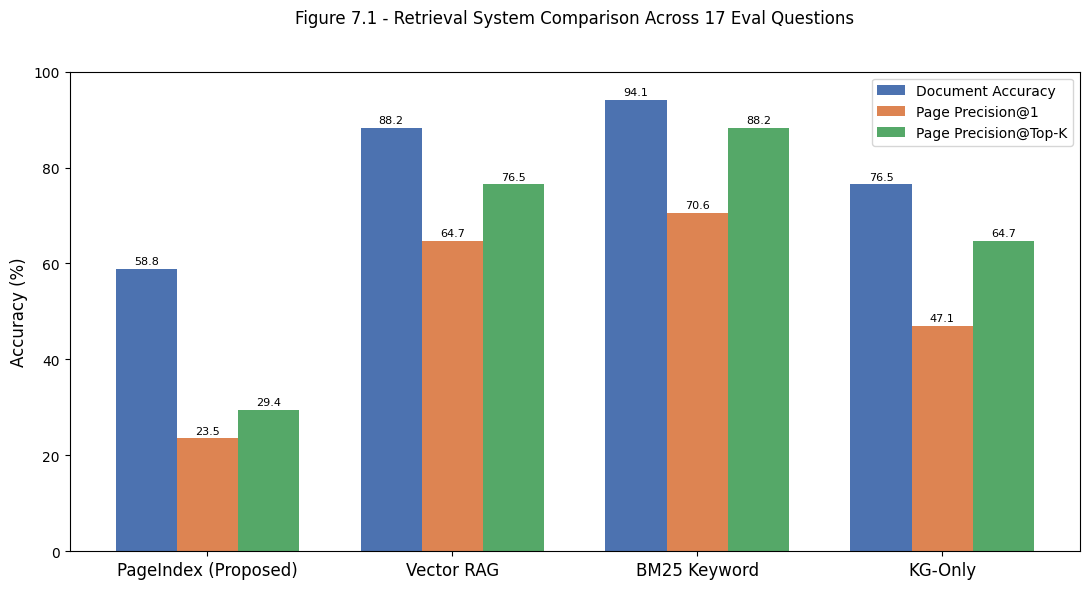


Saved: /content/drive/MyDrive/dissertation_project/outputs/chapter7/figures/fig7_1_bar_comparison.png


In [ ]:
# Grouped bar chart
import numpy as np

x = np.arange(len(comparison_df))
width = 0.25
metrics = ["Document Accuracy", "Page Precision@1", "Page Precision@Top-K"]
colors = ["#4c72b0", "#dd8452", "#55a868"]

fig, ax = plt.subplots(figsize=(11, 6))
for i, metric in enumerate(metrics):
    bars = ax.bar(x + i*width, comparison_df[metric], width, label=metric, color=colors[i])
    ax.bar_label(bars, fmt="%.1f", fontsize=8, padding=2)

ax.set_xticks(x + width)
ax.set_xticklabels(comparison_df["System"], fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.set_title("Figure 7.1 - Retrieval System Comparison Across 17 Eval Questions\n", fontsize=12, pad=20)
ax.legend(fontsize=10)
plt.tight_layout()
fig_path = CH7 / "figures" / "fig7_1_bar_comparison.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("\nSaved:", fig_path)

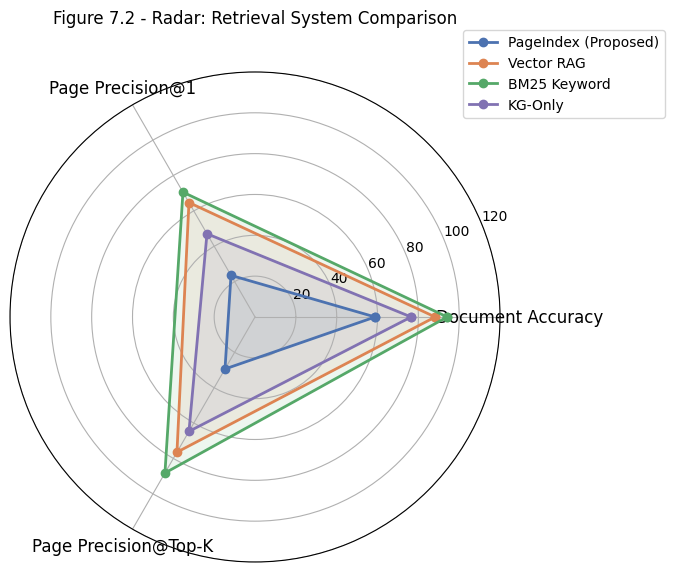

Saved: /content/drive/MyDrive/dissertation_project/outputs/chapter7/figures/fig7_2_radar.png


In [ ]:
# Radar chart - overall performance profile
categories = ["Document Accuracy", "Page Precision@1", "Page Precision@Top-K"]
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]
colors_radar = ["#4c72b0", "#dd8452", "#55a868", "#8172b2"]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i, row in comparison_df.iterrows():
    values = [row[c] for c in categories]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=row["System"], color=colors_radar[i])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 120)
ax.set_title("Figure 7.2 - Radar: Retrieval System Comparison\n", fontsize=12, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
fig_path = CH7 / "figures" / "fig7_2_radar.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)